# SSDC 2026 — Exploratory Data Analysis (EDA): Student Placement System Dataset by kata edward

## Bagian 0 — Setup & Sanity Check

In [356]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 0.1 — Konfirmasi Shape

In [357]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = "../data/clean/"

company = pd.read_csv(
    DATA_DIR + "company_clean.csv",
    dtype={"id_company": str, "pic_phone": str},
    parse_dates=["created_at"],
)

status_student = pd.read_csv(
    DATA_DIR + "status_student_clean.csv",
    dtype={"id_status": str, "NIM": str, "no_whatsapp": str},
    parse_dates=["sync_date"],
)

student_all = pd.read_csv(
    DATA_DIR + "student_all_clean.csv", dtype={"NIM": str, "hp": str}
)

talent_request = pd.read_csv(
    DATA_DIR + "talent_request_clean.csv",
    dtype={"id_talent_req": str, "id_company": str, "no_whatsapp": str},
    parse_dates=["request_date"],
)

tracking_company = pd.read_csv(
    DATA_DIR + "tracking_company_clean.csv",
    dtype={
        "id_tracking_company": str,
        "id_talent_req": str,
        "id_company": str,
        "list_nim": str,
    },
    parse_dates=["request_date", "send_date"],
)

tracking_student = pd.read_csv(
    DATA_DIR + "tracking_student_clean.csv",
    dtype={"id_tracking_student": str, "NIM": str, "id_tracking_company": str},
    parse_dates=["last_update"],
)

tables = {
    "company": company,
    "talent_request": talent_request,
    "student_all": student_all,
    "status_student": status_student,
    "tracking_company": tracking_company,
    "tracking_student": tracking_student,
}

expected_shapes = {
    "company": 1500,
    "status_student": 25000,
    "student_all": 25000,
    "talent_request": 12000,
    "tracking_company": 12000,
    "tracking_student": 41600,
}

for name in tables:
    n = tables[name].shape[0]
    status = "MISMATCH"
    if n == expected_shapes[name]:
        status = "OK"
    print(
        f"{name:18s} shape={n}  expected_rows={expected_shapes.get(name):<6} [{status}]"
    )

company            shape=1500  expected_rows=1500   [OK]
talent_request     shape=12000  expected_rows=12000  [OK]
student_all        shape=25000  expected_rows=25000  [OK]
status_student     shape=25000  expected_rows=25000  [OK]
tracking_company   shape=12000  expected_rows=12000  [OK]
tracking_student   shape=41600  expected_rows=41600  [OK]


### 0.2 — Sanity Check Ringkas (PK, FK, tanggal)

In [358]:
pk_checks = {
    "company": "id_company",
    "status_student": "id_status",
    "student_all": "NIM",
    "talent_request": "id_talent_req",
    "tracking_company": "id_tracking_company",
    "tracking_student": "id_tracking_student",
}

print("-- Primary key unik -- ")
for name, pk in pk_checks.items():
    df = tables[name]
    dup = df[pk].duplicated().sum()
    print(f"{name:18s} PK={pk:20s} duplikat={dup} [{'OK' if dup==0 else 'ANOMALI'}]")


print("\n-- Foreign key yatim (orphan) --")

# fmt: off
orphan_ss_nim = ~status_student["NIM"].isin(student_all["NIM"])
orphan_tr_company = ~talent_request["id_company"].isin(company["id_company"])
orphan_tc_talent = ~tracking_company["id_talent_req"].isin(talent_request["id_talent_req"])
orphan_tc_company = ~tracking_company["id_company"].isin(company["id_company"])
orphan_ts_tc = ~tracking_student["id_tracking_company"].isin(tracking_company["id_tracking_company"])
orphan_ts_nim = ~tracking_student["NIM"].isin(student_all["NIM"])

print(f"status_student.NIM -> student_all.NIM : {orphan_ss_nim.sum()} yatim")
print(f"talent_request.id_company -> company.id_company : {orphan_tr_company.sum()} yatim")
print(f"tracking_company.id_talent_req -> talent_request.id_talent_req : {orphan_tc_talent.sum()} yatim")
print(f"tracking_company.id_company -> company.id_company : {orphan_tc_company.sum()} yatim")
print(f"tracking_student.id_tracking_company -> tracking_company.id_tracking_company : {orphan_ts_tc.sum()} yatim")
print(f"tracking_student.NIM -> student_all.NIM : {orphan_ts_nim.sum()} yatim")
# fmt: on


print("\n-- Draft tracking_company (expected 598) --")
draft_mask = tracking_company["send_date"].isna() & tracking_company["list_nim"].isna()
print(f"Baris tanpa send_date & list_nim: {draft_mask.sum()}")
print(tracking_company.loc[draft_mask, "progress"].value_counts())


print("\n-- Rentang tanggal --")
date_cols = {
    "company.created_at": company["created_at"],
    "talent_request.request_date": talent_request["request_date"],
    "status_student.sync_date": status_student["sync_date"],
    "tracking_company.request_date": tracking_company["request_date"],
    "tracking_company.send_date": tracking_company["send_date"],
    "tracking_student.last_update": tracking_student["last_update"],
}

for label, col in date_cols.items():
    print(f"{label:30s} min={col.min().date()}  max={col.max().date()}")

sent = tracking_company.dropna(subset=["send_date"])
invalid_order = (sent["send_date"] < sent["request_date"]).sum()
print(f"\ntracking_company.send_date < tracking_company.request_date (harus 0): {invalid_order}")  # fmt: skip

-- Primary key unik -- 
company            PK=id_company           duplikat=0 [OK]
status_student     PK=id_status            duplikat=0 [OK]
student_all        PK=NIM                  duplikat=0 [OK]
talent_request     PK=id_talent_req        duplikat=0 [OK]
tracking_company   PK=id_tracking_company  duplikat=0 [OK]
tracking_student   PK=id_tracking_student  duplikat=0 [OK]

-- Foreign key yatim (orphan) --
status_student.NIM -> student_all.NIM : 0 yatim
talent_request.id_company -> company.id_company : 0 yatim
tracking_company.id_talent_req -> talent_request.id_talent_req : 0 yatim
tracking_company.id_company -> company.id_company : 0 yatim
tracking_student.id_tracking_company -> tracking_company.id_tracking_company : 0 yatim
tracking_student.NIM -> student_all.NIM : 0 yatim

-- Draft tracking_company (expected 598) --
Baris tanpa send_date & list_nim: 598
progress
Draft    598
Name: count, dtype: int64

-- Rentang tanggal --
company.created_at             min=2022-01-02  max=2024-12

### 0.2b — Cross-check STUDENT ALL ↔ STATUS STUDENT (BT-08)

In [359]:
merged = student_all.merge(
    status_student[["NIM", "nama", "program_studi", "semester"]],
    on="NIM",
    how="outer",
    suffixes=("_studentall", "_status"),
    indicator=True,
)

# fmt: off
orphan_left = (merged['_merge'] == 'left_only').sum()   # ada di student_all, tidak di status_student
orphan_right = (merged['_merge'] == 'right_only').sum() # ada di status_student, tidak di student_all
print(f"NIM hanya di student_all (orphan)   : {orphan_left}")
print(f"NIM hanya di status_student (orphan): {orphan_right}")

both = merged[merged['_merge'] == 'both'].copy()
mismatch_nama = (both['nama_studentall'] != both['nama_status']).sum()
mismatch_prodi = (both['program_studi_studentall'] != both['program_studi_status']).sum()
mismatch_semester = (both['semester_studentall'] != both['semester_status']).sum()

print(f"\nDari {len(both)} NIM yang match di kedua tabel:")
print(f"  mismatch nama         : {mismatch_nama}")
print(f"  mismatch program_studi: {mismatch_prodi}")
print(f"  mismatch semester     : {mismatch_semester}")

kesimpulan = "SINKRON 100%" if (orphan_left + orphan_right + mismatch_nama + mismatch_prodi + mismatch_semester) == 0 else "ADA ANOMALI"
print(f"\n>>> Kesimpulan 0.2b: {kesimpulan}")
# fmt: on

NIM hanya di student_all (orphan)   : 0
NIM hanya di status_student (orphan): 0

Dari 25000 NIM yang match di kedua tabel:
  mismatch nama         : 0
  mismatch program_studi: 0
  mismatch semester     : 0

>>> Kesimpulan 0.2b: SINKRON 100%


## Bagian 1 — Profil Dasar Tiap Tabel → H1

In [360]:
def bar_with_labels(ax, series, title, rotation=0, palette="Set1"):
    sns.barplot(
        x=series.index.astype(str),
        y=series.values,
        hue=series.index.astype(str),
        palette=palette,
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=rotation)
    ax.set_ylim(0, series.max() * 1.15)
    ax.margins(x=0.05)
    for container in ax.containers:
        ax.bar_label(container, padding=3)


def hist_with_labels(ax, data, title, bins=20, color=None):
    sns.histplot(data, bins=bins, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel("")

    max_bin_height = max(v for container in ax.containers for v in container.datavalues)
    ax.set_ylim(0, max_bin_height * 1.15)

    for container in ax.containers:
        labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)


def print_summary(label, counts, unit="perusahaan"):
    print(f"{label}:")
    print(f"   dominan : {counts.idxmax()} ({counts.max()} {unit})")
    print(f"   sedikit : {counts.idxmin()} ({counts.min()} {unit})")
    print()

### 1.1 — Profil company

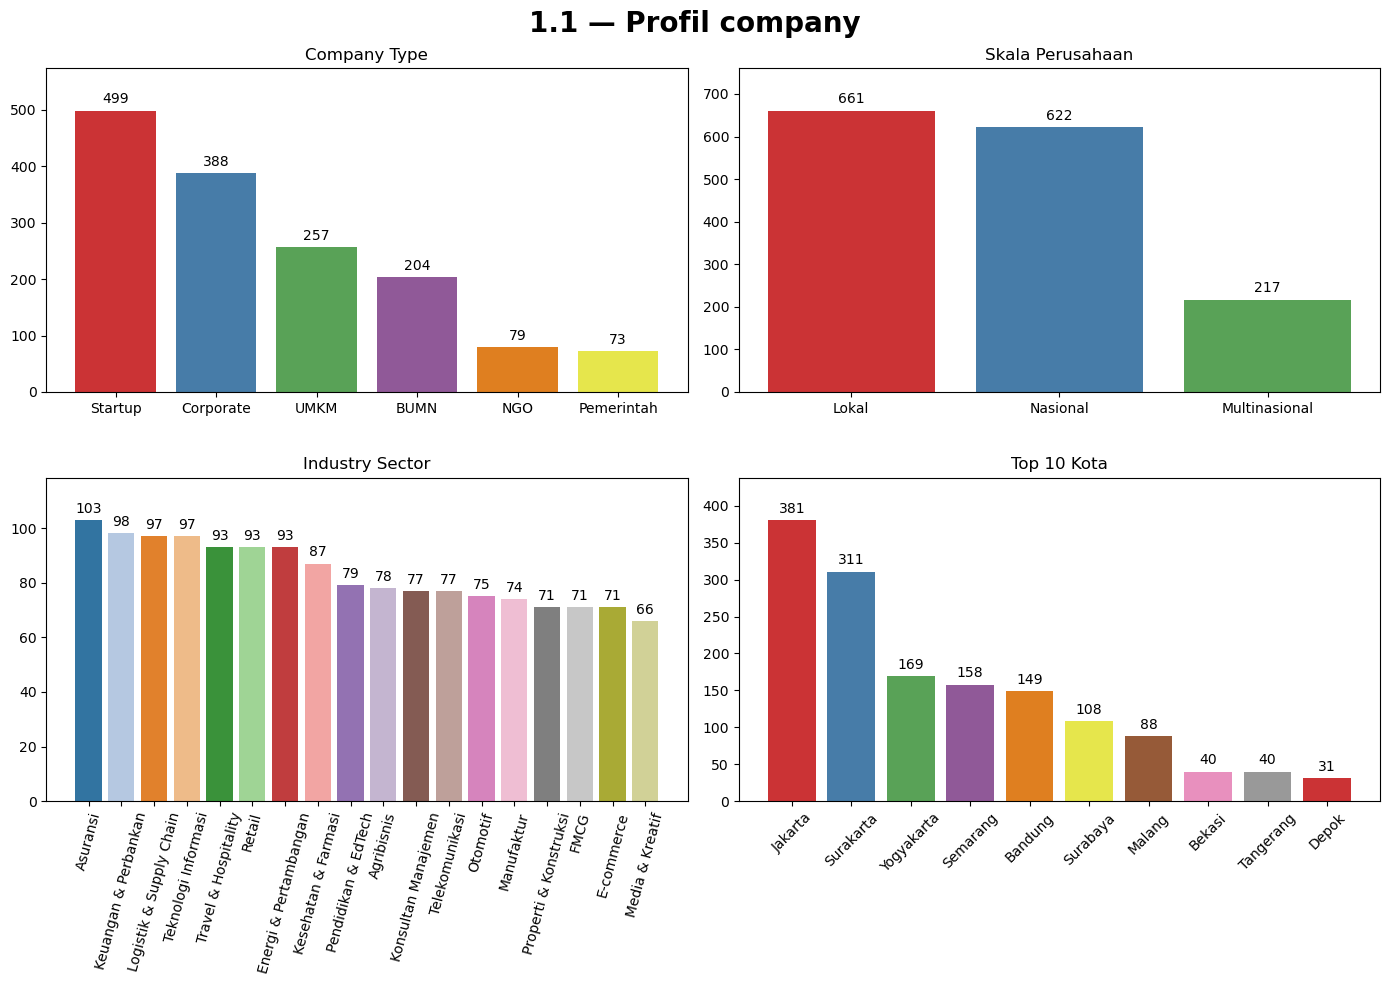

company_type:
   dominan : Startup (499 perusahaan)
   sedikit : Pemerintah (73 perusahaan)

skala_perusahaan:
   dominan : Lokal (661 perusahaan)
   sedikit : Multinasional (217 perusahaan)

industry_sector:
   dominan : Asuransi (103 perusahaan)
   sedikit : Media & Kreatif (66 perusahaan)

kota:
   dominan : Jakarta (381 perusahaan)
   sedikit : Bogor (25 perusahaan)

jumlah kota unik: 11
daftar lengkap per kota:
   Jakarta        : 381 perusahaan
   Surakarta      : 311 perusahaan
   Yogyakarta     : 169 perusahaan
   Semarang       : 158 perusahaan
   Bandung        : 149 perusahaan
   Surabaya       : 108 perusahaan
   Malang         : 88 perusahaan
   Bekasi         : 40 perusahaan
   Tangerang      : 40 perusahaan
   Depok          : 31 perusahaan
   Bogor          : 25 perusahaan


In [361]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.1 — Profil company", fontsize=20, fontweight="bold")


# fmt: off
bar_with_labels(axes[0, 0], company["company_type"].value_counts(), "Company Type")
bar_with_labels(axes[0, 1], company["skala_perusahaan"].value_counts(), "Skala Perusahaan")
bar_with_labels(axes[1, 0], company["industry_sector"].value_counts(), "Industry Sector", rotation=75, palette="tab20")
bar_with_labels(axes[1, 1], company["kota"].value_counts().head(10), "Top 10 Kota", rotation=45)
# fmt: on

plt.tight_layout(h_pad=3)
plt.show()


company_type_counts = company["company_type"].value_counts()
skala_counts = company["skala_perusahaan"].value_counts()
sector_counts = company["industry_sector"].value_counts()
kota_counts = company["kota"].value_counts()

print_summary("company_type", company_type_counts)
print_summary("skala_perusahaan", skala_counts)
print_summary("industry_sector", sector_counts)
print_summary("kota", kota_counts)

print(f"jumlah kota unik: {company['kota'].nunique()}")
print("daftar lengkap per kota:")
for kota, jumlah in kota_counts.items():
    print(f"   {kota:15s}: {jumlah} perusahaan")

### 1.2 — Profil talent_request

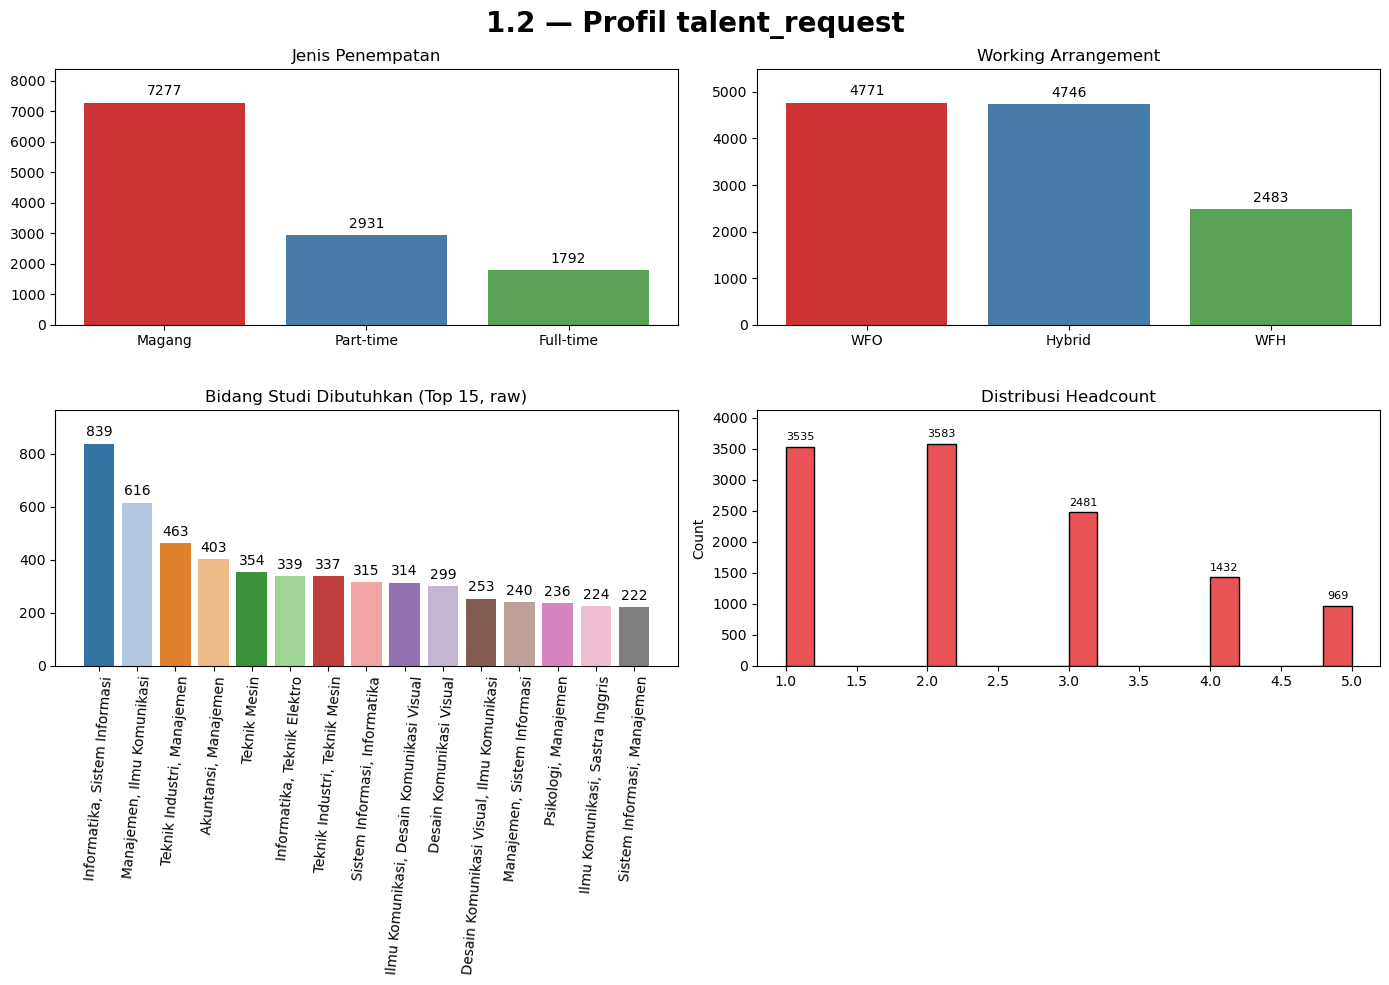

jenis_penempatan:
   dominan : Magang (7277 perusahaan)
   sedikit : Full-time (1792 perusahaan)

working_arrangement:
   dominan : WFO (4771 perusahaan)
   sedikit : WFH (2483 perusahaan)

bidang_studi_dibutuhkan: 113 kombinasi unik (raw, belum di-explode)
   dominan : Informatika, Sistem Informasi (839 request)
   catatan : analisis 'bidang paling jarang' lebih valid setelah explode (bagian supply-demand)

headcount describe():
count    12000.000000
mean         2.393083
std          1.245404
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: headcount, dtype: float64


In [362]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.2 — Profil talent_request", fontsize=20, fontweight="bold")

bidang_studi_counts_full = talent_request["bidang_studi_dibutuhkan"].value_counts()

# fmt: off
bar_with_labels(axes[0, 0], talent_request["jenis_penempatan"].value_counts(), "Jenis Penempatan")
bar_with_labels(axes[0, 1], talent_request["working_arrangement"].value_counts(), "Working Arrangement")
bar_with_labels(axes[1, 0], bidang_studi_counts_full.head(15), "Bidang Studi Dibutuhkan (Top 15, raw)", rotation=85, palette="tab20")
hist_with_labels(axes[1, 1], talent_request["headcount"], "Distribusi Headcount", bins=20, color=sns.color_palette("Set1")[0])

plt.tight_layout(h_pad=3)
plt.show()

print_summary("jenis_penempatan", talent_request["jenis_penempatan"].value_counts())
print_summary("working_arrangement", talent_request["working_arrangement"].value_counts())

print(f"bidang_studi_dibutuhkan: {len(bidang_studi_counts_full)} kombinasi unik (raw, belum di-explode)")
print(f"   dominan : {bidang_studi_counts_full.idxmax()} ({bidang_studi_counts_full.max()} request)")
print(f"   catatan : analisis 'bidang paling jarang' lebih valid setelah explode (bagian supply-demand)")
print()
# fmt: on

print("headcount describe():")
print(talent_request["headcount"].describe())

### 1.3 — Profil student_all

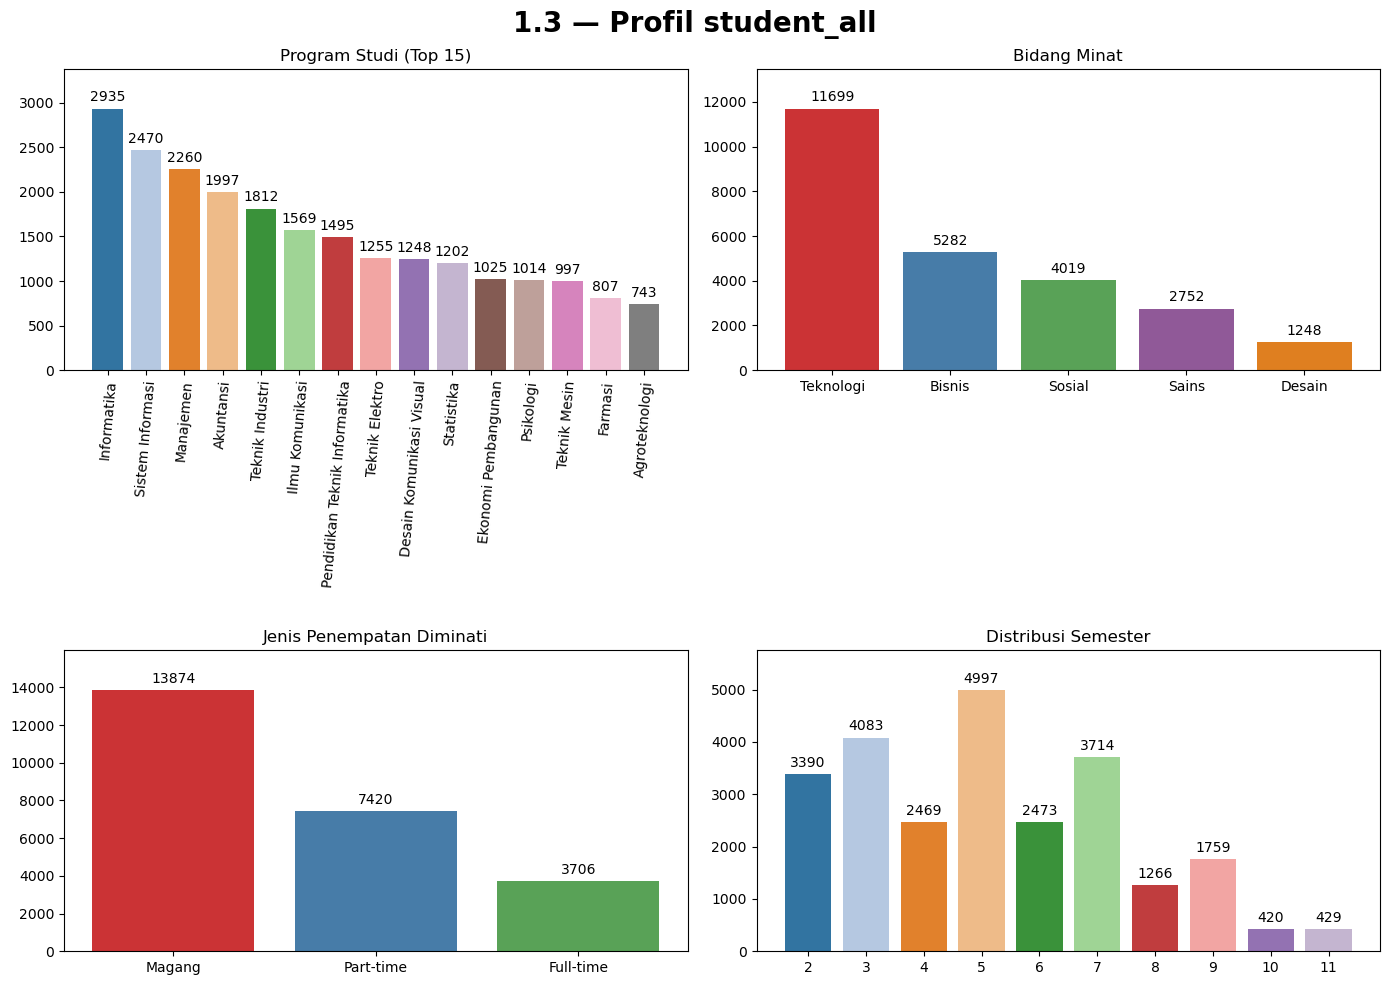

program_studi: 18 prodi unik
   terbesar : Informatika (2935 mahasiswa)
   terkecil : Ilmu Hukum (700 mahasiswa)

bidang_minat:
   dominan : Teknologi (11699 mahasiswa)
   sedikit : Desain (1248 mahasiswa)

jenis_penempatan_diminati:
   dominan : Magang (13874 mahasiswa)
   sedikit : Full-time (3706 mahasiswa)

Distribusi semester (urut semester, bukan frekuensi):
   semester  2: 3390 mahasiswa
   semester  3: 4083 mahasiswa
   semester  4: 2469 mahasiswa
   semester  5: 4997 mahasiswa
   semester  6: 2473 mahasiswa
   semester  7: 3714 mahasiswa
   semester  8: 1266 mahasiswa
   semester  9: 1759 mahasiswa
   semester 10: 420 mahasiswa
   semester 11: 429 mahasiswa


In [363]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.3 — Profil student_all", fontsize=20, fontweight="bold")

program_studi_counts_full = student_all["program_studi"].value_counts()
semester_counts = student_all["semester"].value_counts().sort_index()

# fmt:off
bar_with_labels(axes[0, 0], program_studi_counts_full.head(15), "Program Studi (Top 15)", rotation=85, palette="tab20")
bar_with_labels(axes[0, 1], student_all["bidang_minat"].value_counts(), "Bidang Minat")
bar_with_labels(axes[1, 0], student_all["jenis_penempatan_diminati"].value_counts(), "Jenis Penempatan Diminati")
bar_with_labels(axes[1, 1], semester_counts, "Distribusi Semester", palette="tab20")

plt.tight_layout(h_pad=3)
plt.show()

print(f"program_studi: {len(program_studi_counts_full)} prodi unik")
print(f"   terbesar : {program_studi_counts_full.idxmax()} ({program_studi_counts_full.max()} mahasiswa)")
print(f"   terkecil : {program_studi_counts_full.idxmin()} ({program_studi_counts_full.min()} mahasiswa)")
print()

print_summary("bidang_minat", student_all["bidang_minat"].value_counts(), unit="mahasiswa")
print_summary("jenis_penempatan_diminati", student_all["jenis_penempatan_diminati"].value_counts(), unit="mahasiswa")
# fmt:on

print("Distribusi semester (urut semester, bukan frekuensi):")
for sem, jumlah in semester_counts.items():
    print(f"   semester {sem:2d}: {jumlah} mahasiswa")

### 1.4 — Profil status_student

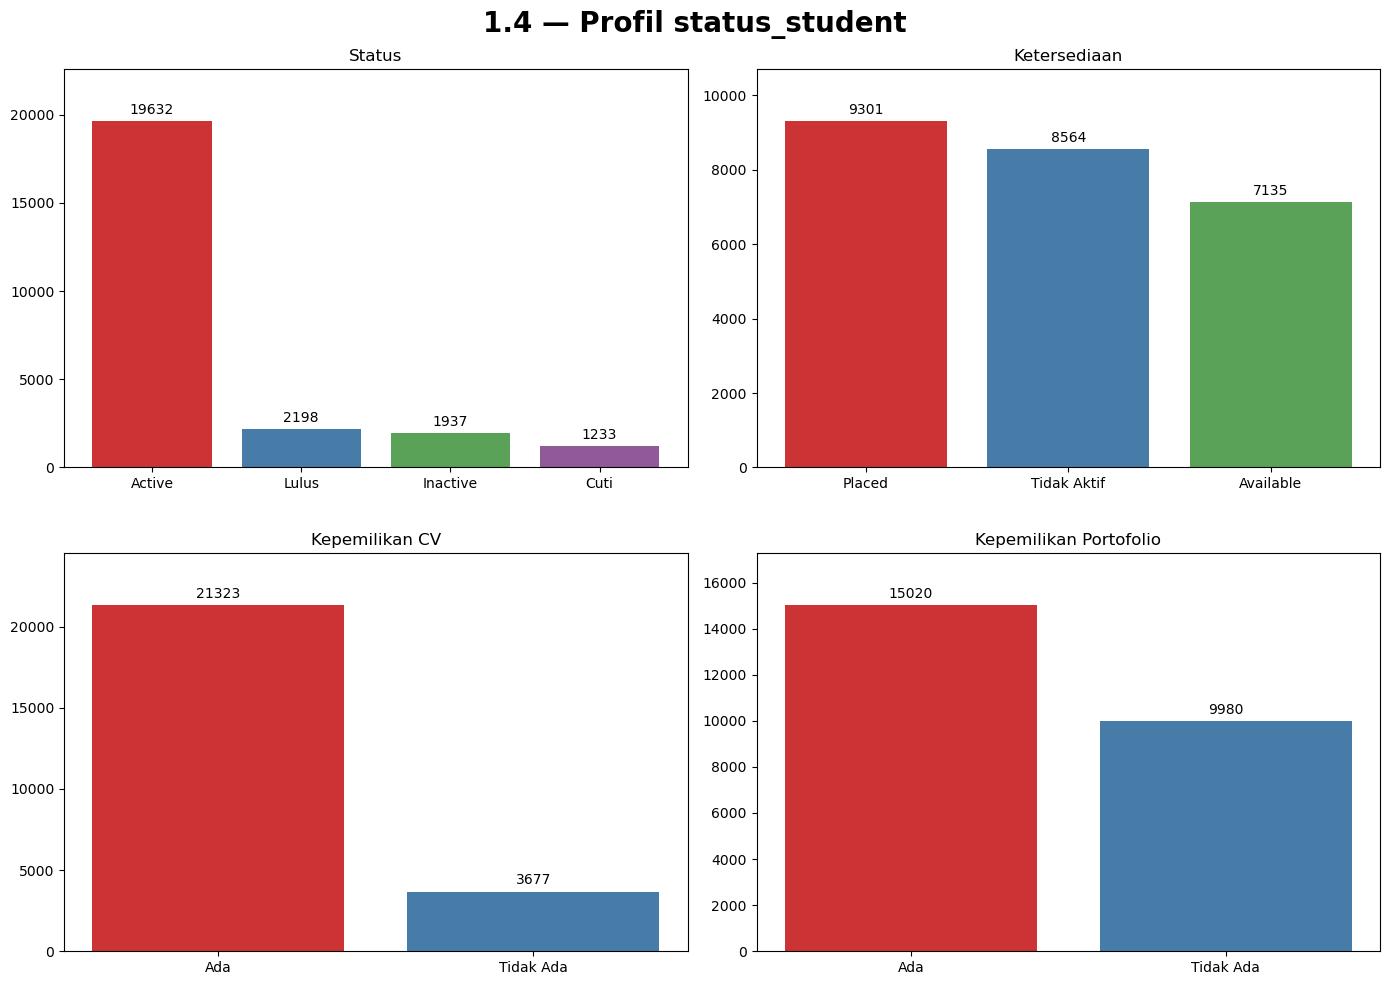

status:
   dominan : Active (19632 mahasiswa)
   sedikit : Cuti (1233 mahasiswa)

ketersediaan:
   dominan : Placed (9301 mahasiswa)
   sedikit : Available (7135 mahasiswa)

CV:
   dominan : Ada (21323 mahasiswa)
   sedikit : Tidak Ada (3677 mahasiswa)

portofolio:
   dominan : Ada (15020 mahasiswa)
   sedikit : Tidak Ada (9980 mahasiswa)



In [364]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("1.4 — Profil status_student", fontsize=20, fontweight="bold")

# fmt:off
bar_with_labels(axes[0, 0], status_student["status"].value_counts(), "Status")
bar_with_labels(axes[0, 1], status_student["ketersediaan"].value_counts(), "Ketersediaan")
bar_with_labels(axes[1, 0], status_student["CV"].value_counts(), "Kepemilikan CV")
bar_with_labels(axes[1, 1], status_student["portofolio"].value_counts(), "Kepemilikan Portofolio")

plt.tight_layout(h_pad=3)
plt.show()

print_summary("status", status_student["status"].value_counts(), unit="mahasiswa")
print_summary("ketersediaan", status_student["ketersediaan"].value_counts(), unit="mahasiswa")
print_summary("CV", status_student["CV"].value_counts(), unit="mahasiswa")
print_summary("portofolio", status_student["portofolio"].value_counts(), unit="mahasiswa")
# fmt:on

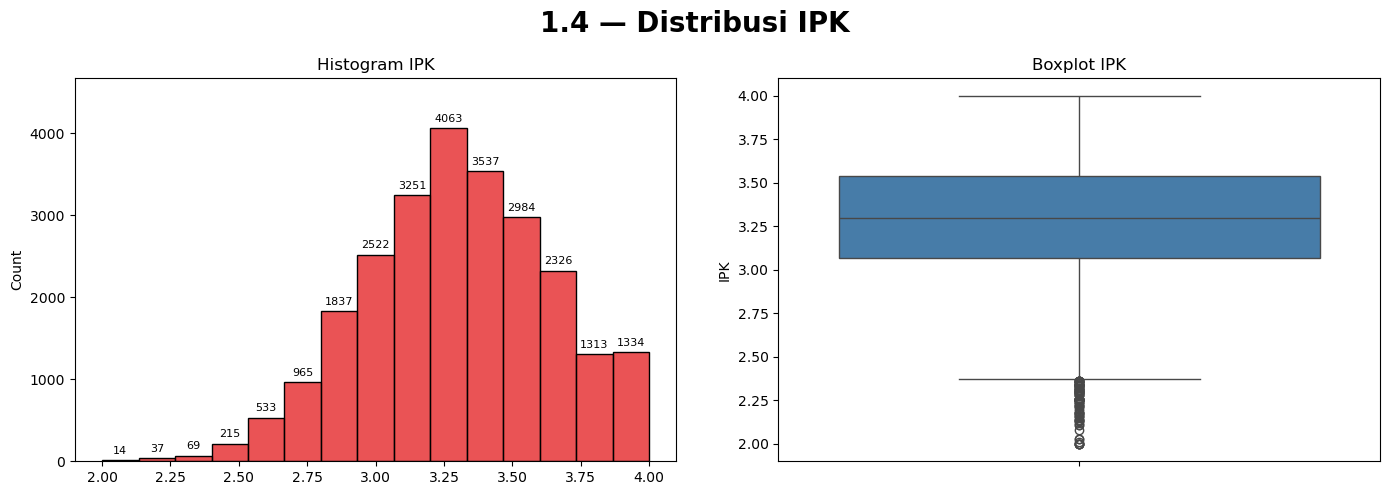

IPK describe():
count    25000.000000
mean         3.298299
std          0.341807
min          2.000000
25%          3.070000
50%          3.300000
75%          3.540000
max          4.000000
Name: IPK, dtype: float64

Breakdown per rentang IPK (bin 0.2):
   (1.999, 2.2] : 28 mahasiswa
   (2.2, 2.4] : 97 mahasiswa
   (2.4, 2.6] : 442 mahasiswa
   (2.6, 2.8] : 1370 mahasiswa
   (2.8, 3.0] : 2959 mahasiswa
   (3.0, 3.2] : 4840 mahasiswa
   (3.2, 3.4] : 5752 mahasiswa
   (3.4, 3.6] : 4708 mahasiswa
   (3.6, 3.8] : 2965 mahasiswa
   (3.8, 4.0] : 1839 mahasiswa


In [365]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1.4 — Distribusi IPK", fontsize=20, fontweight="bold")

hist_with_labels(
    axes[0],
    status_student["IPK"],
    "Histogram IPK",
    bins=15,
    color=sns.color_palette("Set1")[0],
)

sns.boxplot(y=status_student["IPK"], ax=axes[1], color=sns.color_palette("Set1")[1])
axes[1].set_title("Boxplot IPK")

plt.tight_layout(w_pad=3)
plt.show()

print("IPK describe():")
print(status_student["IPK"].describe())

print("\nBreakdown per rentang IPK (bin 0.2):")
bin_edges = np.arange(2.0, 4.01, 0.2)
ipk_binned = pd.cut(status_student["IPK"], bins=bin_edges, include_lowest=True)
for interval, jumlah in ipk_binned.value_counts().sort_index().items():
    print(f"   {interval} : {jumlah} mahasiswa")

### 1.5 — Rentang tanggal semua tabel

In [366]:
date_summary = pd.DataFrame(
    {
        "tabel.kolom": [
            "company.created_at",
            "talent_request.request_date",
            "status_student.sync_date",
            "tracking_company.request_date",
            "tracking_company.send_date",
            "tracking_student.last_update",
        ],
        "min": [
            company["created_at"].min(),
            talent_request["request_date"].min(),
            status_student["sync_date"].min(),
            tracking_company["request_date"].min(),
            tracking_company["send_date"].min(),
            tracking_student["last_update"].min(),
        ],
        "max": [
            company["created_at"].max(),
            talent_request["request_date"].max(),
            status_student["sync_date"].max(),
            tracking_company["request_date"].max(),
            tracking_company["send_date"].max(),
            tracking_student["last_update"].max(),
        ],
    }
)

date_summary["rentang_hari"] = (date_summary["max"] - date_summary["min"]).dt.days

date_summary

,tabel.kolom,min,max,rentang_hari
0,company.created_at,2022-01-02,2024-12-31,1094
1,talent_request.request_date,2023-02-01,2025-01-31,730
2,status_student.sync_date,2023-02-01,2025-01-31,730
3,tracking_company.request_date,2023-02-01,2025-01-31,730
4,tracking_company.send_date,2023-02-04,2025-02-21,748
5,tracking_student.last_update,2023-02-08,2025-05-17,829


## Bagian 2 — Kelayakan Mahasiswa & Audit Kepatuhan (BT-06) → H1

### 2.1 — Funnel kelayakan bertingkat

Total Terdaftar             : 25,000  (100.0% dari total)
status = Active             : 19,632  ( 78.5% dari total)   retensi 78.5%   drop -5,368 (-21.5%)
+ CV = Ada                  : 16,732  ( 66.9% dari total)   retensi 85.2%   drop -2,900 (-14.8%)
+ ketersediaan = Available  :  5,687  ( 22.7% dari total)   retensi 34.0%   drop -11,045 (-66.0%)

>>> Penyusutan terbesar: '+ ketersediaan = Available' (-11,045, -66.0%)


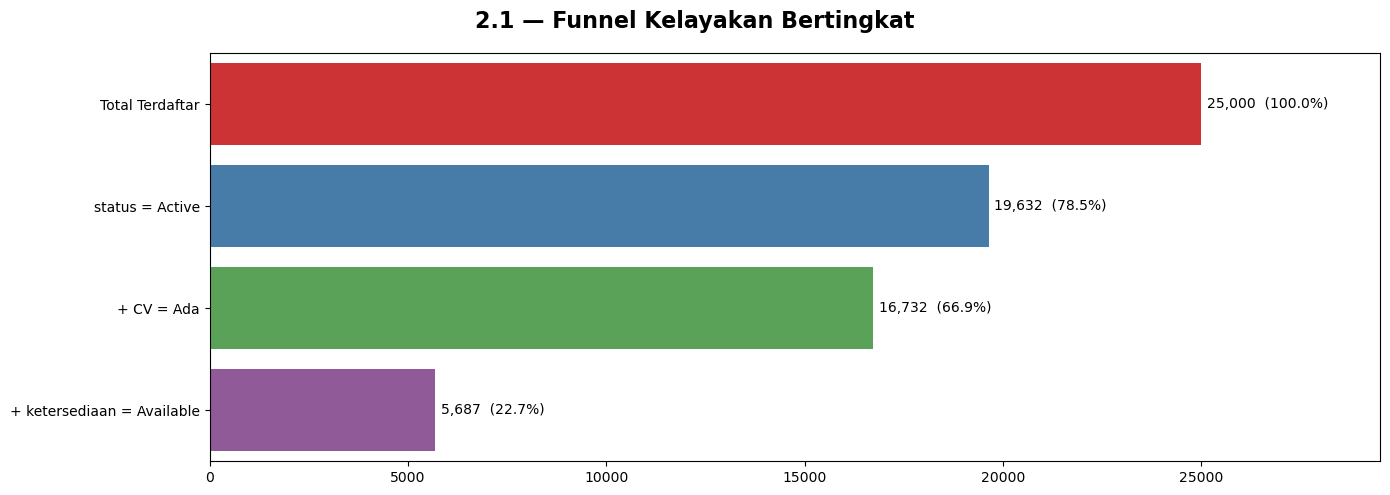

In [367]:
stage1_mask = pd.Series(True, index=status_student.index)
stage2_mask = stage1_mask & (status_student["status"] == "Active")
stage3_mask = stage2_mask & (status_student["CV"] == "Ada")
stage4_mask = stage3_mask & (status_student["ketersediaan"] == "Available")

funnel_stages = [
    ("Total Terdaftar", stage1_mask.sum()),
    ("status = Active", stage2_mask.sum()),
    ("+ CV = Ada", stage3_mask.sum()),
    ("+ ketersediaan = Available", stage4_mask.sum()),
]

total = funnel_stages[0][1]
funnel_df = pd.DataFrame(funnel_stages, columns=["tahap", "jumlah"])

# -- Ringkasan --
prev = None
drops = []
for label, count in funnel_stages:
    pct = count / total * 100
    if prev is None:
        print(f"{label:28s}: {count:6,d}  ({pct:5.1f}% dari total)")
    else:
        drop = prev - count
        pct_drop = drop / prev * 100
        pct_retain = count / prev * 100
        drops.append((label, drop, pct_drop))
        print(
            f"{label:28s}: {count:6,d}  ({pct:5.1f}% dari total)   retensi {pct_retain:.1f}%   drop -{drop:,} (-{pct_drop:.1f}%)"
        )
    prev = count

terbesar = max(drops, key=lambda x: x[1])
print(
    f"\n>>> Penyusutan terbesar: '{terbesar[0]}' (-{terbesar[1]:,}, -{terbesar[2]:.1f}%)"
)

# -- Chart --
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("2.1 — Funnel Kelayakan Bertingkat", fontsize=16, fontweight="bold")

sns.barplot(
    data=funnel_df,
    x="jumlah",
    y="tahap",
    hue="tahap",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, total * 1.18)

for container in ax.containers:
    labels_txt = [f"{v:,.0f}  ({v/total*100:.1f}%)" for v in container.datavalues]
    ax.bar_label(container, labels=labels_txt, padding=4, fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 — Asumsi IPK threshold (dokumentasikan eksplisit)

In [368]:
eligible_mask = status_student["eligible"] = (
    (status_student["status"] == "Active")
    & (status_student["CV"] == "Ada")
    & (status_student["ketersediaan"] == "Available")
)
eligible_base = eligible_mask.sum()
total = len(status_student)

thresholds = [None, 2.5, 2.75, 3.0]
threshold_labels = ["Tanpa filter (>=2.0, default)", ">=2.5", ">=2.75", ">=3.0"]

print(
    f"Basis: populasi eligible dari funnel 2.1 (Active+CV+Available) = {eligible_base:,} mahasiswa\n"
)

results = []
for label, thresh in zip(threshold_labels, thresholds):
    mask = (
        eligible_mask
        if thresh is None
        else eligible_mask & (status_student["IPK"] >= thresh)
    )
    count = mask.sum()
    pct_of_eligible = count / eligible_base * 100
    pct_of_total = count / total * 100
    results.append((label, count, pct_of_eligible, pct_of_total))
    print(
        f"{label:32s}: {count:6,d}  ({pct_of_eligible:5.1f}% dari eligible, {pct_of_total:5.1f}% dari total 25.000)"
    )

sensitivity_df = pd.DataFrame(
    results,
    columns=["threshold_ipk", "jumlah_eligible", "%_dari_eligible", "%_dari_total"],
)
sensitivity_df

Basis: populasi eligible dari funnel 2.1 (Active+CV+Available) = 5,687 mahasiswa

Tanpa filter (>=2.0, default)   :  5,687  (100.0% dari eligible,  22.7% dari total 25.000)
>=2.5                           :  5,622  ( 98.9% dari eligible,  22.5% dari total 25.000)
>=2.75                          :  5,359  ( 94.2% dari eligible,  21.4% dari total 25.000)
>=3.0                           :  4,616  ( 81.2% dari eligible,  18.5% dari total 25.000)


,threshold_ipk,jumlah_eligible,%_dari_eligible,%_dari_total
0,"Tanpa filter (>=2.0, default)",5687,100.000000,22.748
1,>=2.5,5622,98.857042,22.488
2,>=2.75,5359,94.232460,21.436
3,>=3.0,4616,81.167575,18.464


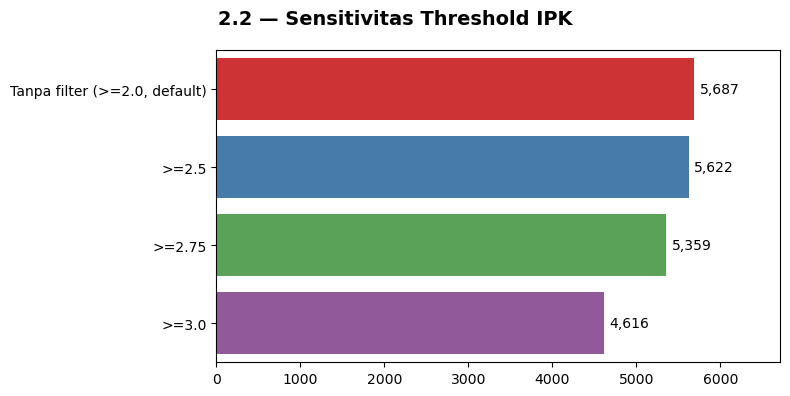


CATATAN KEPUTUSAN — Threshold IPK:

Funnel kelayakan utama (2.1) TIDAK menerapkan filter IPK — semua mahasiswa
dengan IPK >= 2.0 (skala minimum) dianggap valid secara default. Dokumentasi
dataset tidak memberi angka IPK minimum resmi ("Beberapa perusahaan memiliki
syarat IPK minimum" -- kondisional per perusahaan, bukan syarat universal,
sama seperti kasus portofolio).

Tabel di atas murni analisis SENSITIVITAS -- menunjukkan berapa banyak
mahasiswa yang akan "gugur" jika threshold IPK tertentu diterapkan,
BUKAN rekomendasi threshold yang harus dipakai.



In [369]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("2.2 — Sensitivitas Threshold IPK", fontsize=14, fontweight="bold")

sns.barplot(
    data=sensitivity_df,
    x="jumlah_eligible",
    y="threshold_ipk",
    hue="threshold_ipk",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, eligible_base * 1.18)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:,.0f}" for v in container.datavalues],
        padding=4,
        fontsize=10,
    )

plt.tight_layout()
plt.show()

print(
    """
CATATAN KEPUTUSAN — Threshold IPK:

Funnel kelayakan utama (2.1) TIDAK menerapkan filter IPK — semua mahasiswa
dengan IPK >= 2.0 (skala minimum) dianggap valid secara default. Dokumentasi
dataset tidak memberi angka IPK minimum resmi ("Beberapa perusahaan memiliki
syarat IPK minimum" -- kondisional per perusahaan, bukan syarat universal,
sama seperti kasus portofolio).

Tabel di atas murni analisis SENSITIVITAS -- menunjukkan berapa banyak
mahasiswa yang akan "gugur" jika threshold IPK tertentu diterapkan,
BUKAN rekomendasi threshold yang harus dipakai.
"""
)

### 2.3 — AUDIT BT-06: apakah yang DIKIRIM memang eligible? [✓data]

In [370]:
sent_nim = tracking_student["NIM"].unique()
n_sent = len(sent_nim)

sent_status = status_student[status_student["NIM"].isin(sent_nim)].copy()

print(f"Jumlah mahasiswa unik yang pernah dikirim (dari tracking_student): {n_sent:,}")
print(f"Jumlah yang berhasil di-match ke status_student: {len(sent_status):,}\n")

non_active = (sent_status["status"] != "Active").sum()
no_cv = (sent_status["CV"] != "Ada").sum()
not_available = (sent_status["ketersediaan"] != "Available").sum()

audit_df = pd.DataFrame(
    {
        "syarat": ["status = Active", "CV = Ada", "ketersediaan = Available"],
        "jumlah_pelanggaran": [non_active, no_cv, not_available],
        "%_dari_terkirim": [
            non_active / n_sent * 100,
            no_cv / n_sent * 100,
            not_available / n_sent * 100,
        ],
    }
)
print(audit_df.to_string(index=False))

print(
    f"\n>>> Kepatuhan status+CV: {'100% PATUH' if non_active == 0 and no_cv == 0 else 'ADA PELANGGARAN'}"
)

Jumlah mahasiswa unik yang pernah dikirim (dari tracking_student): 10,174
Jumlah yang berhasil di-match ke status_student: 10,174

                  syarat  jumlah_pelanggaran  %_dari_terkirim
         status = Active                   0         0.000000
                CV = Ada                   0         0.000000
ketersediaan = Available                5138        50.501278

>>> Kepatuhan status+CV: 100% PATUH


In [371]:
not_available_mask = sent_status["ketersediaan"] != "Available"
ketersediaan_breakdown = sent_status.loc[
    not_available_mask, "ketersediaan"
].value_counts()

print(
    f"Breakdown ketersediaan untuk {not_available_mask.sum():,} mahasiswa terkirim yang statusnya BUKAN Available:\n"
)
print(ketersediaan_breakdown)

pct_placed = (ketersediaan_breakdown.get("Placed", 0) / not_available_mask.sum()) * 100
print(f"\n>>> {pct_placed:.1f}% dari mereka berstatus 'Placed' saat ini")

if pct_placed == 100:
    print(">>> Kesimpulan: SEMUA non-Available itu justru karena SUDAH placement,")
    print("    bukan pelanggaran matching. Snapshot ketersediaan berubah SETELAH")
    print("    penempatan, bukan bukti CDC mengirim kandidat yang belum siap.")

Breakdown ketersediaan untuk 5,138 mahasiswa terkirim yang statusnya BUKAN Available:

ketersediaan
Placed    5138
Name: count, dtype: int64

>>> 100.0% dari mereka berstatus 'Placed' saat ini
>>> Kesimpulan: SEMUA non-Available itu justru karena SUDAH placement,
    bukan pelanggaran matching. Snapshot ketersediaan berubah SETELAH
    penempatan, bukan bukti CDC mengirim kandidat yang belum siap.


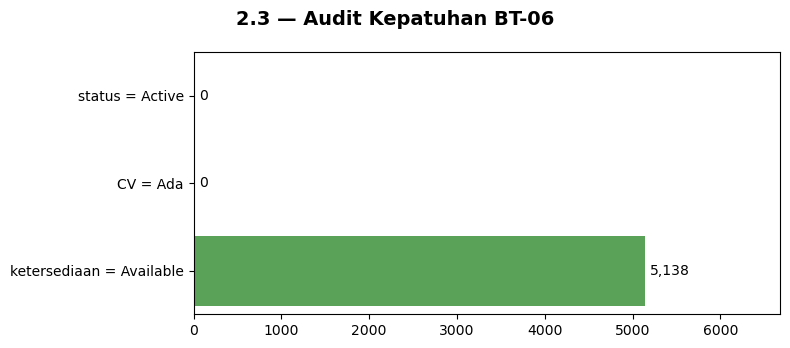

In [372]:
fig, ax = plt.subplots(figsize=(8, 3.5))
fig.suptitle("2.3 — Audit Kepatuhan BT-06", fontsize=14, fontweight="bold")

sns.barplot(
    data=audit_df,
    x="jumlah_pelanggaran",
    y="syarat",
    hue="syarat",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, max(audit_df["jumlah_pelanggaran"].max() * 1.3, 100))

for container in ax.containers:
    labels_txt = [f"{v:,.0f}" for v in container.datavalues]
    ax.bar_label(container, labels=labels_txt, padding=4, fontsize=10)

plt.tight_layout()
plt.show()

### 2.4 — Breakdown funnel per program_studi

In [373]:
status_student["eligible"] = (
    (status_student["status"] == "Active")
    & (status_student["CV"] == "Ada")
    & (status_student["ketersediaan"] == "Available")
)

prodi_summary = (
    status_student.groupby("program_studi")
    .agg(total_mahasiswa=("eligible", "size"), jumlah_eligible=("eligible", "sum"))
    .reset_index()
)
prodi_summary["pct_eligible"] = (
    prodi_summary["jumlah_eligible"] / prodi_summary["total_mahasiswa"] * 100
)
prodi_summary = prodi_summary.sort_values("pct_eligible", ascending=False)

# fmt: off
print(f"Rata-rata % eligible seluruh prodi: {status_student['eligible'].mean()*100:.1f}%\n")

print("Top 5 prodi (% eligible tertinggi -- 'paling siap kirim'):")
print(prodi_summary.head(5).to_string(index=False))

print("\nBottom 5 prodi (% eligible terendah -- 'paling tidak siap'):")
print(prodi_summary.tail(5).to_string(index=False))

print("\nProdi dengan mahasiswa TERBANYAK (belum tentu paling siap):")
print(prodi_summary.sort_values("total_mahasiswa", ascending=False).head(5).to_string(index=False))
# fmt: on

Rata-rata % eligible seluruh prodi: 22.7%

Top 5 prodi (% eligible tertinggi -- 'paling siap kirim'):
                program_studi  total_mahasiswa  jumlah_eligible  pct_eligible
                   Ilmu Hukum              700              280     40.000000
               Sastra Inggris              736              256     34.782609
          Ekonomi Pembangunan             1025              320     31.219512
Pendidikan Teknik Informatika             1495              434     29.030100
                    Psikologi             1014              287     28.303748

Bottom 5 prodi (% eligible terendah -- 'paling tidak siap'):
           program_studi  total_mahasiswa  jumlah_eligible  pct_eligible
             Informatika             2935              568     19.352641
Desain Komunikasi Visual             1248              240     19.230769
         Ilmu Komunikasi             1569              280     17.845762
        Sistem Informasi             2470              440     17.813765
   

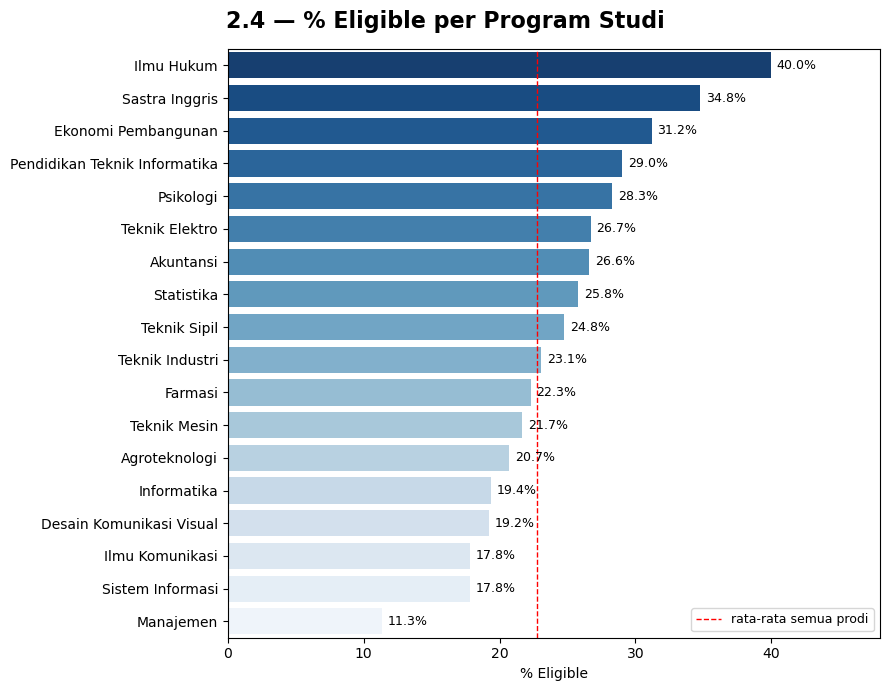

In [374]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("2.4 — % Eligible per Program Studi", fontsize=16, fontweight="bold")

sns.barplot(
    data=prodi_summary,
    x="pct_eligible",
    y="program_studi",
    hue="program_studi",
    palette="Blues_r",
    legend=False,
    ax=ax,
)

ax.axvline(
    status_student["eligible"].mean() * 100,
    color="red",
    linestyle="--",
    linewidth=1,
    label="rata-rata semua prodi",
)
ax.legend(loc="lower right", fontsize=9)

ax.set_xlabel("% Eligible")
ax.set_ylabel("")
ax.set_xlim(0, prodi_summary["pct_eligible"].max() * 1.2)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels_txt = [f"{v:.1f}%" for v in container.datavalues]
        ax.bar_label(container, labels=labels_txt, padding=4, fontsize=9)

plt.tight_layout()
plt.show()

### 2.5 — Cross-tab CV × portofolio

In [375]:
crosstab_counts = pd.crosstab(status_student["CV"], status_student["portofolio"])
crosstab_pct = (
    pd.crosstab(status_student["CV"], status_student["portofolio"], normalize="all")
    * 100
)

print("Jumlah (n):")
print(crosstab_counts)
print("\nPersentase dari total 25.000:")
print(crosstab_pct.round(1))

n_cv_no_portfolio = crosstab_counts.loc["Ada", "Tidak Ada"]
pct_cv_no_portfolio = crosstab_pct.loc["Ada", "Tidak Ada"]

print(
    f"\n>>> Sorotan: CV Ada tapi portofolio Tidak Ada = {n_cv_no_portfolio:,} mahasiswa ({pct_cv_no_portfolio:.1f}% dari total)"
)
print("    -> populasi ini SUDAH siap dikirim (CV lengkap), tapi berisiko")
print("       tertahan kalau ada request yang mensyaratkan portofolio.")

print(
    """
CATATAN PENTING:
talent_request TIDAK punya kolom atau sinyal teks (deskripsi_requirement)
yang menyebutkan syarat portofolio secara eksplisit per-request. Jadi
crosstab ini TIDAK BISA dipakai untuk klaim "sekian % pengiriman melanggar
syarat portofolio" -- itu tidak bisa diverifikasi dari data yang tersedia.

Angka di atas murni gambaran KESIAPAN POPULASI (readiness signal), bukan
audit kepatuhan terhadap permintaan spesifik. Relevan sebagai early-warning
untuk CDC: kelompok "CV Ada, portofolio Tidak Ada" perlu didorong melengkapi
portofolio, untuk berjaga-jaga jika ada request yang mensyaratkannya.
"""
)

Jumlah (n):
portofolio    Ada  Tidak Ada
CV                          
Ada         12810       8513
Tidak Ada    2210       1467

Persentase dari total 25.000:
portofolio   Ada  Tidak Ada
CV                         
Ada         51.2       34.1
Tidak Ada    8.8        5.9

>>> Sorotan: CV Ada tapi portofolio Tidak Ada = 8,513 mahasiswa (34.1% dari total)
    -> populasi ini SUDAH siap dikirim (CV lengkap), tapi berisiko
       tertahan kalau ada request yang mensyaratkan portofolio.

CATATAN PENTING:
talent_request TIDAK punya kolom atau sinyal teks (deskripsi_requirement)
yang menyebutkan syarat portofolio secara eksplisit per-request. Jadi
crosstab ini TIDAK BISA dipakai untuk klaim "sekian % pengiriman melanggar
syarat portofolio" -- itu tidak bisa diverifikasi dari data yang tersedia.

Angka di atas murni gambaran KESIAPAN POPULASI (readiness signal), bukan
audit kepatuhan terhadap permintaan spesifik. Relevan sebagai early-warning
untuk CDC: kelompok "CV Ada, portofolio Tidak Ada" p

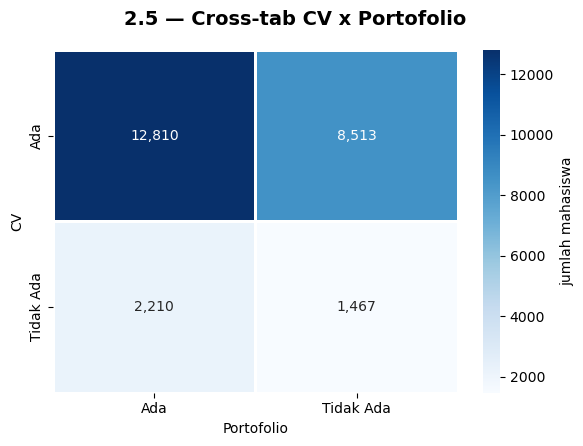

In [376]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.suptitle("2.5 — Cross-tab CV x Portofolio", fontsize=14, fontweight="bold")

sns.heatmap(
    crosstab_counts,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar_kws={"label": "jumlah mahasiswa"},
    ax=ax,
    linewidths=1,
    linecolor="white",
)

ax.set_xlabel("Portofolio")
ax.set_ylabel("CV")

plt.tight_layout()
plt.show()

### 2.6 — IPK: Available vs Tidak Aktif

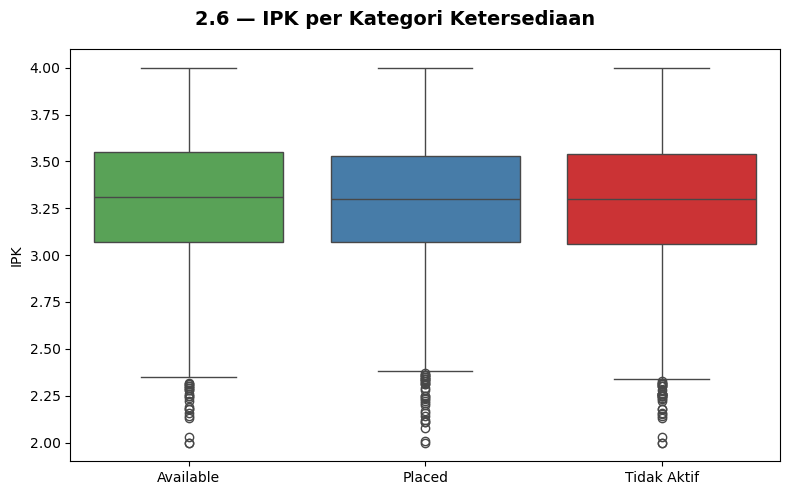

In [377]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("2.6 — IPK per Kategori Ketersediaan", fontsize=14, fontweight="bold")

order = (
    status_student.groupby("ketersediaan")["IPK"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=status_student,
    x="ketersediaan",
    y="IPK",
    hue="ketersediaan",
    palette="Set1",
    legend=False,
    order=order,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("IPK")

plt.tight_layout()
plt.show()

In [378]:
median_ipk = (
    status_student.groupby("ketersediaan")["IPK"].median().sort_values(ascending=False)
)
mean_ipk = (
    status_student.groupby("ketersediaan")["IPK"].mean().sort_values(ascending=False)
)
count_ipk = status_student.groupby("ketersediaan")["IPK"].size()

summary = pd.DataFrame(
    {
        "n": count_ipk,
        "median_IPK": median_ipk,
        "mean_IPK": mean_ipk.round(2),
    }
).sort_values("median_IPK", ascending=False)
print(summary)

tertinggi = median_ipk.idxmax()
terendah = median_ipk.idxmin()
selisih = median_ipk.max() - median_ipk.min()

print(f"\n>>> Median IPK tertinggi: '{tertinggi}' ({median_ipk.max():.2f})")
print(f">>> Median IPK terendah : '{terendah}' ({median_ipk.min():.2f})")
print(f">>> Selisih median      : {selisih:.2f}")

if "Tidak Aktif" in median_ipk.index:
    if terendah == "Tidak Aktif":
        print("\n>>> Kesimpulan: 'Tidak Aktif' memang punya median IPK PALING RENDAH")
        print("    -> ada indikasi korelasi (meski tidak berarti sebab-akibat).")
    else:
        print("\n>>> Kesimpulan: 'Tidak Aktif' BUKAN yang median IPK-nya paling rendah")
        print("    -> tidak ada indikasi korelasi kuat antara ketersediaan dan IPK.")

                 n  median_IPK  mean_IPK
ketersediaan                            
Available     7135        3.31       3.3
Placed        9301        3.30       3.3
Tidak Aktif   8564        3.30       3.3

>>> Median IPK tertinggi: 'Available' (3.31)
>>> Median IPK terendah : 'Placed' (3.30)
>>> Selisih median      : 0.01

>>> Kesimpulan: 'Tidak Aktif' BUKAN yang median IPK-nya paling rendah
    -> tidak ada indikasi korelasi kuat antara ketersediaan dan IPK.


### 2.7 — Top tools/skill kelompok eligible

In [379]:
status_student["eligible"] = (
    (status_student["status"] == "Active")
    & (status_student["CV"] == "Ada")
    & (status_student["ketersediaan"] == "Available")
)

eligible_df = status_student[status_student["eligible"]].copy()

eligible_df["tools_list"] = eligible_df["tools"].str.split(",")
tools_exploded = eligible_df.explode("tools_list")
tools_exploded["tools_list"] = tools_exploded["tools_list"].str.strip()

tools_counts = tools_exploded["tools_list"].value_counts()

print(f"Basis: {len(eligible_df):,} mahasiswa eligible (Active+CV+Available)")
print(f"Jumlah tools unik yang disebut: {len(tools_counts)}")
print(f"Total mention tools (setelah explode): {len(tools_exploded):,}\n")

top_n = 20
print(f"Top {top_n} tools/skill:")
print(tools_counts.head(top_n))

Basis: 5,687 mahasiswa eligible (Active+CV+Available)
Jumlah tools unik yang disebut: 80
Total mention tools (setelah explode): 19,931

Top 20 tools/skill:
tools_list
Python              1214
Excel               1200
SQL                  989
SPSS                 761
SAP                  682
Power BI             631
MATLAB               597
AutoCAD              524
Microsoft Office     500
Tableau              439
R                    437
Figma                427
JavaScript           369
Canva                360
Git                  329
WordPress            327
Java                 320
SolidWorks           318
Mendeley             275
Google Analytics     272
Name: count, dtype: int64


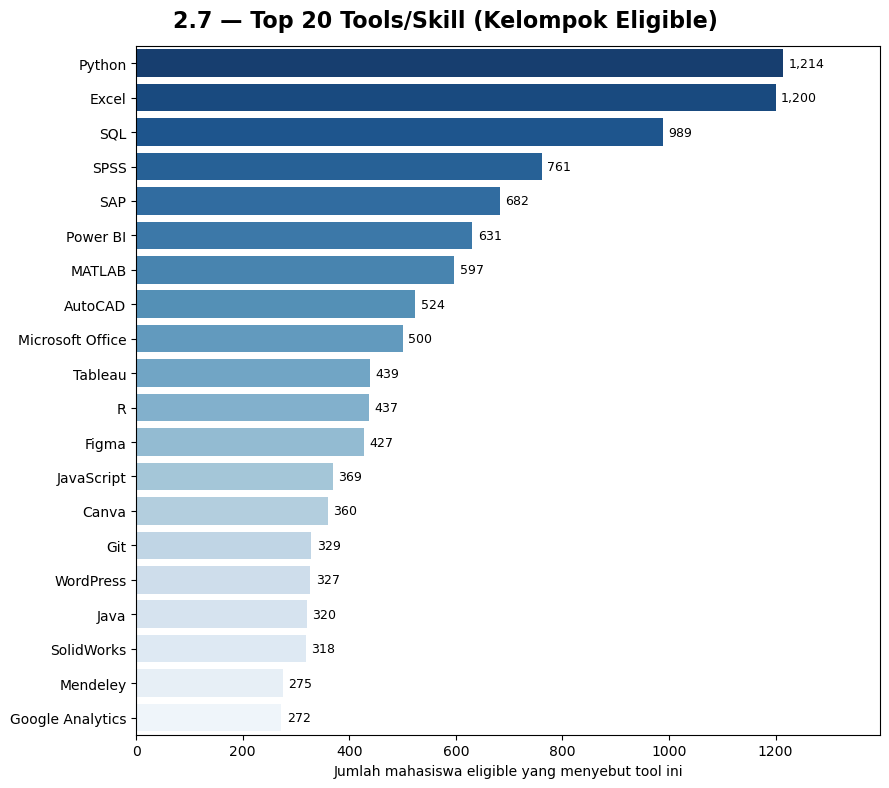

In [380]:
top_tools = tools_counts.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle(
    "2.7 — Top 20 Tools/Skill (Kelompok Eligible)", fontsize=16, fontweight="bold"
)

sns.barplot(
    x=top_tools.values,
    y=top_tools.index,
    hue=top_tools.index,
    palette="Blues_r",
    legend=False,
    ax=ax,
)

ax.set_xlabel("Jumlah mahasiswa eligible yang menyebut tool ini")
ax.set_ylabel("")
ax.set_xlim(0, top_tools.max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:,.0f}" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## Bagian 3 — Beban Proses, Ghosting & Proses Mati (BT-02, BT-05) → H4

### 3.1 — Concurrent process load per NIM

In [381]:
process_load = tracking_student.groupby("NIM").size()

n_basis = len(process_load)
median_load = process_load.median()
pct_ge2 = (process_load >= 2).mean() * 100
pct_ge3 = (process_load >= 3).mean() * 100

print(
    f"Basis: {n_basis:,} mahasiswa yang PERNAH masuk proses (BUKAN dari total 25.000)\n"
)
print(f"Median jumlah proses per mahasiswa : {median_load:.0f}")
print(f"Mean                               : {process_load.mean():.2f}")
print(
    f"Min - Max                          : {process_load.min()} - {process_load.max()}"
)
print(f"% mahasiswa dengan >=2 proses       : {pct_ge2:.1f}%")
print(f"% mahasiswa dengan >=3 proses       : {pct_ge3:.1f}%")

print("\nDescribe lengkap:")
print(process_load.describe())

Basis: 10,174 mahasiswa yang PERNAH masuk proses (BUKAN dari total 25.000)

Median jumlah proses per mahasiswa : 4
Mean                               : 4.09
Min - Max                          : 1 - 19
% mahasiswa dengan >=2 proses       : 86.9%
% mahasiswa dengan >=3 proses       : 69.5%

Describe lengkap:
count    10174.000000
mean         4.088854
std          2.506449
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max         19.000000
dtype: float64


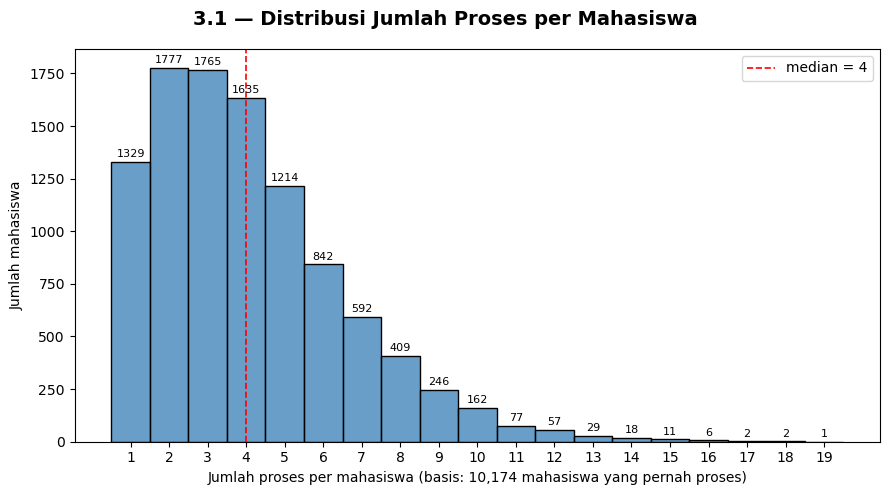

In [382]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    "3.1 — Distribusi Jumlah Proses per Mahasiswa", fontsize=14, fontweight="bold"
)

max_load = process_load.max()
bins = range(1, max_load + 2)

sns.histplot(
    process_load, bins=bins, ax=ax, color=sns.color_palette("Set1")[1], discrete=True
)

ax.axvline(
    median_load,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"median = {median_load:.0f}",
)
ax.legend()

ax.set_xlabel(
    f"Jumlah proses per mahasiswa (basis: {n_basis:,} mahasiswa yang pernah proses)"
)
ax.set_ylabel("Jumlah mahasiswa")
ax.set_xticks(range(1, max_load + 1))

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

### 3.2 — Distribusi tracking_student per id_tracking_company

In [383]:
candidates_per_request = tracking_student.groupby("id_tracking_company").size()

print(
    f"Basis: {len(candidates_per_request):,} request yang benar-benar terkirim (non-Draft)\n"
)
print(candidates_per_request.describe())

print(f"\nMean  : {candidates_per_request.mean():.2f}")
print(f"Median: {candidates_per_request.median():.0f}")
print(f"Max   : {candidates_per_request.max()}")

outlier_threshold = candidates_per_request.quantile(0.99)
print(f"\nP99 (top 1%): {outlier_threshold:.1f}")
print(
    f"Jumlah request dengan kandidat >= P99: {(candidates_per_request >= outlier_threshold).sum()}"
)

Basis: 11,402 request yang benar-benar terkirim (non-Draft)

count    11402.000000
mean         3.648483
std          1.582210
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          8.000000
dtype: float64

Mean  : 3.65
Median: 4
Max   : 8

P99 (top 1%): 7.0
Jumlah request dengan kandidat >= P99: 519


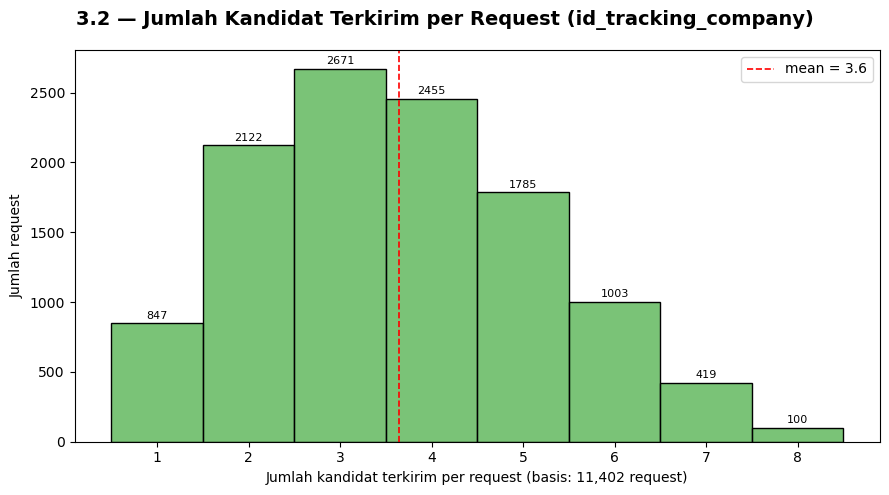

In [384]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    "3.2 — Jumlah Kandidat Terkirim per Request (id_tracking_company)",
    fontsize=14,
    fontweight="bold",
)

max_cand = candidates_per_request.max()
bins = range(1, max_cand + 2)

sns.histplot(
    candidates_per_request,
    bins=bins,
    ax=ax,
    color=sns.color_palette("Set1")[2],
    discrete=True,
)

ax.axvline(
    candidates_per_request.mean(),
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"mean = {candidates_per_request.mean():.1f}",
)
ax.legend()

ax.set_xlabel(
    f"Jumlah kandidat terkirim per request (basis: {len(candidates_per_request):,} request)"
)
ax.set_ylabel("Jumlah request")
ax.set_xticks(range(1, max_cand + 1))

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [385]:
top_requests = candidates_per_request.sort_values(ascending=False).head(10)
top_requests_detail = (
    tracking_company[tracking_company["id_tracking_company"].isin(top_requests.index)][
        [
            "id_tracking_company",
            "nama_perusahaan",
            "posisi",
            "jumlah_permintaan",
            "jumlah_dikirimkan",
        ]
    ]
    .set_index("id_tracking_company")
    .loc[top_requests.index]
)

print("10 request dengan kandidat terkirim terbanyak:")
print(top_requests_detail)

10 request dengan kandidat terkirim terbanyak:
                        nama_perusahaan                    posisi  jumlah_permintaan  jumlah_dikirimkan
id_tracking_company                                                                                    
TC1901                CV Karya Gemilang      Supply Chain Analyst                  5                  8
TC10244                  PT Daya Cerdas     Quality Control Staff                  5                  8
TC9473               PT Prima Teknologi  Digital Marketing Intern                  5                  8
TC379                   CV Media Global        Research Assistant                  5                  8
TC9451                 PT Sukses Bangsa                  IT Staff                  5                  8
TC4357                 PT Prima Terapan      Curriculum Developer                  5                  8
TC7646               PT Media Sejahtera              Data Analyst                  5                  8
TC9356           

### 3.2b — CDC selalu kirim ≥ permintaan (strategi buffer) `[+]`

In [386]:
non_draft = tracking_company[tracking_company["progress"] != "Draft"].copy()
non_draft["selisih"] = non_draft["jumlah_dikirimkan"] - non_draft["jumlah_permintaan"]
non_draft["rasio"] = non_draft["jumlah_dikirimkan"] / non_draft["jumlah_permintaan"]

n_total = len(non_draft)
n_over = (non_draft["selisih"] > 0).sum()
n_under = (non_draft["selisih"] < 0).sum()
n_exact = (non_draft["selisih"] == 0).sum()

print(f"Basis: {n_total:,} request non-Draft\n")
print(f"dikirim > diminta (overshoot) : {n_over:6,d}  ({n_over/n_total*100:5.1f}%)")
print(f"dikirim < diminta (undershoot): {n_under:6,d}  ({n_under/n_total*100:5.1f}%)")
print(f"dikirim == diminta (exact)    : {n_exact:6,d}  ({n_exact/n_total*100:5.1f}%)")

print(
    f"\n>>> CDC TIDAK PERNAH mengirim kurang dari permintaan (0 undershoot)"
    if n_under == 0
    else f">>> Ada {n_under} kasus undershoot"
)

overshoot_df = non_draft[non_draft["selisih"] > 0]
print(f"\nUntuk {n_over:,} request yang overshoot:")
print(f"   rata-rata selisih : {overshoot_df['selisih'].mean():.2f} kandidat ekstra")
print(f"   rata-rata rasio   : {overshoot_df['rasio'].mean():.2f}x dari yang diminta")
print(f"   selisih terbesar  : {overshoot_df['selisih'].max():.0f} kandidat ekstra")

Basis: 11,402 request non-Draft

dikirim > diminta (overshoot) :  8,579  ( 75.2%)
dikirim < diminta (undershoot):      0  (  0.0%)
dikirim == diminta (exact)    :  2,823  ( 24.8%)

>>> CDC TIDAK PERNAH mengirim kurang dari permintaan (0 undershoot)

Untuk 8,579 request yang overshoot:
   rata-rata selisih : 1.67 kandidat ekstra
   rata-rata rasio   : 1.92x dari yang diminta
   selisih terbesar  : 3 kandidat ekstra


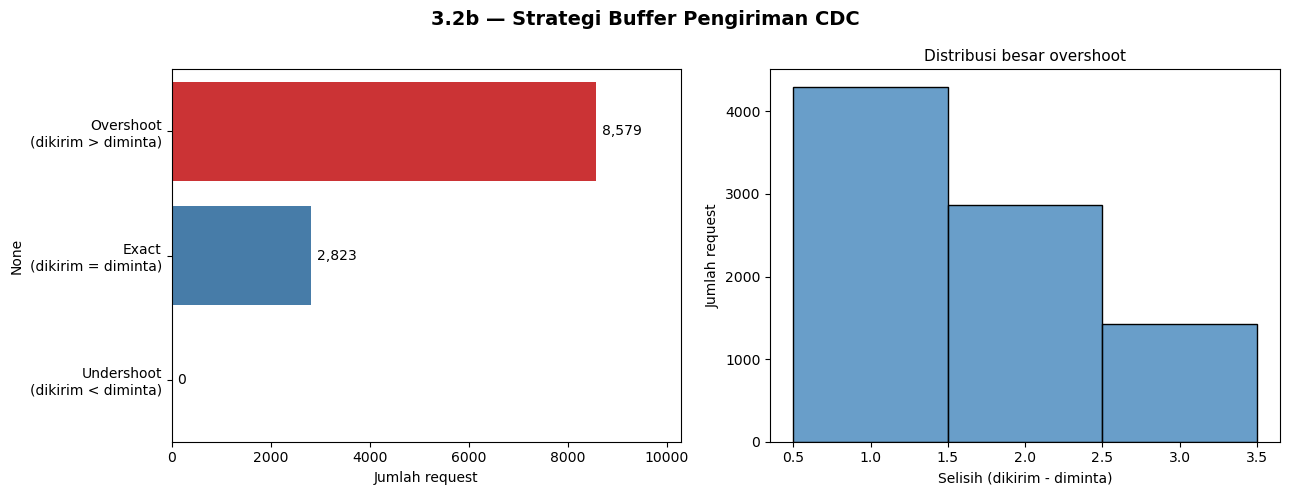


CATATAN: 75,2% dari seluruh request non-Draft dikirim MELEBIHI headcount
yang diminta perusahaan, dan CDC TIDAK PERNAH mengirim kurang dari yang
diminta (0% undershoot). Ini konsisten dengan strategi buffer yang wajar
dalam rekrutmen -- mengantisipasi tingkat ghosting/gugur yang tinggi dalam
proses seleksi (lihat Bagian 3.4 untuk detail ghosting).



In [387]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("3.2b — Strategi Buffer Pengiriman CDC", fontsize=14, fontweight="bold")

# Chart 1: kategori overshoot/exact/undershoot
kategori_counts = pd.Series(
    {
        "Overshoot\n(dikirim > diminta)": n_over,
        "Exact\n(dikirim = diminta)": n_exact,
        "Undershoot\n(dikirim < diminta)": n_under,
    }
)
sns.barplot(
    x=kategori_counts.values,
    y=kategori_counts.index,
    hue=kategori_counts.index,
    palette="Set1",
    legend=False,
    ax=axes[0],
)
axes[0].set_xlabel("Jumlah request")
axes[0].set_xlim(0, kategori_counts.max() * 1.2)
for container in axes[0].containers:
    if hasattr(container, "datavalues"):
        axes[0].bar_label(
            container,
            labels=[f"{v:,.0f}" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

# Chart 2: distribusi selisih (khusus overshoot)
sns.histplot(
    overshoot_df["selisih"],
    bins=range(1, int(overshoot_df["selisih"].max()) + 2),
    discrete=True,
    ax=axes[1],
    color=sns.color_palette("Set1")[1],
)
axes[1].set_xlabel("Selisih (dikirim - diminta)")
axes[1].set_ylabel("Jumlah request")
axes[1].set_title("Distribusi besar overshoot", fontsize=11)

plt.tight_layout()
plt.show()

print(
    """
CATATAN: 75,2% dari seluruh request non-Draft dikirim MELEBIHI headcount
yang diminta perusahaan, dan CDC TIDAK PERNAH mengirim kurang dari yang
diminta (0% undershoot). Ini konsisten dengan strategi buffer yang wajar
dalam rekrutmen -- mengantisipasi tingkat ghosting/gugur yang tinggi dalam
proses seleksi (lihat Bagian 3.4 untuk detail ghosting).
"""
)

### 3.3 — Waktu tinggal per tahap (anchor send_date, sesuai FAQ)

In [388]:
ts_with_send = tracking_student.merge(
    tracking_company[["id_tracking_company", "send_date"]],
    on="id_tracking_company",
    how="left",
)
ts_with_send["durasi_hari"] = (
    ts_with_send["last_update"] - ts_with_send["send_date"]
).dt.days
print(
    f"Baris tanpa send_date (tidak bisa dihitung durasi): {ts_with_send['send_date'].isna().sum()}"
)
print(
    f"Durasi negatif (last_update < send_date, harus 0): {(ts_with_send['durasi_hari'] < 0).sum()}\n"
)
jalur_substantif = [
    "Selecting Student by Company",
    "CDC Briefing Student",
    "Study Case",
    "Interview User",
    "Final Interview",
]
jalur_followup = ["FU 1", "FU 2", "FU 3", "Ghosting"]
median_per_tahap = ts_with_send.groupby("progress_student")["durasi_hari"].median()
print("Median durasi -- Jalur Substantif:")
for tahap in jalur_substantif:
    print(f"   {tahap:32s}: {median_per_tahap.get(tahap, float('nan')):.0f} hari")
print("\nMedian durasi -- Jalur Follow-up/Eskalasi:")
for tahap in jalur_followup:
    print(f"   {tahap:32s}: {median_per_tahap.get(tahap, float('nan')):.0f} hari")
print("\nCatatan: Rejected/Placement/Finish adalah OUTCOME akhir, bukan tahap")
print("mengendap -- tidak dimasukkan ke breakdown 'waktu tinggal per tahap' ini.")


# -- Analisis kenaikan (increment) antar tahap: bottleneck sebenarnya --
def print_increments(jalur, nama_jalur):
    print(f"\nKenaikan per tahap -- {nama_jalur}:")
    deltas = []
    for i in range(1, len(jalur)):
        prev_val = median_per_tahap.get(jalur[i - 1], float("nan"))
        curr_val = median_per_tahap.get(jalur[i], float("nan"))
        delta = curr_val - prev_val
        deltas.append((f"{jalur[i-1]} -> {jalur[i]}", delta))
        print(f"   {jalur[i-1]} -> {jalur[i]:32s}: +{delta:.0f} hari")
    bottleneck = max(deltas, key=lambda x: x[1])
    print(f"   >>> Bottleneck terbesar: {bottleneck[0]} (+{bottleneck[1]:.0f} hari)")
    return deltas


deltas_substantif = print_increments(jalur_substantif, "Jalur Substantif")
deltas_followup = print_increments(jalur_followup, "Jalur Follow-up/Eskalasi")

print("\nCatatan interpretasi: angka median mentah per tahap itu KUMULATIF")
print("(sejak send_date), jadi tahap dengan angka mentah terbesar (Ghosting)")
print("BUKAN otomatis 'paling mengendap' -- itu tautologi karena definisinya")
print("memang >28 hari. Bottleneck sebenarnya dilihat dari KEN AIKAN antar")
print("tahap di atas, bukan angka mentahnya.")

Baris tanpa send_date (tidak bisa dihitung durasi): 0
Durasi negatif (last_update < send_date, harus 0): 0

Median durasi -- Jalur Substantif:
   Selecting Student by Company    : 8 hari
   CDC Briefing Student            : 19 hari
   Study Case                      : 19 hari
   Interview User                  : 29 hari
   Final Interview                 : 41 hari

Median durasi -- Jalur Follow-up/Eskalasi:
   FU 1                            : 22 hari
   FU 2                            : 33 hari
   FU 3                            : 45 hari
   Ghosting                        : 61 hari

Catatan: Rejected/Placement/Finish adalah OUTCOME akhir, bukan tahap
mengendap -- tidak dimasukkan ke breakdown 'waktu tinggal per tahap' ini.

Kenaikan per tahap -- Jalur Substantif:
   Selecting Student by Company -> CDC Briefing Student            : +11 hari
   CDC Briefing Student -> Study Case                      : +0 hari
   Study Case -> Interview User                  : +10 hari
   Interview User

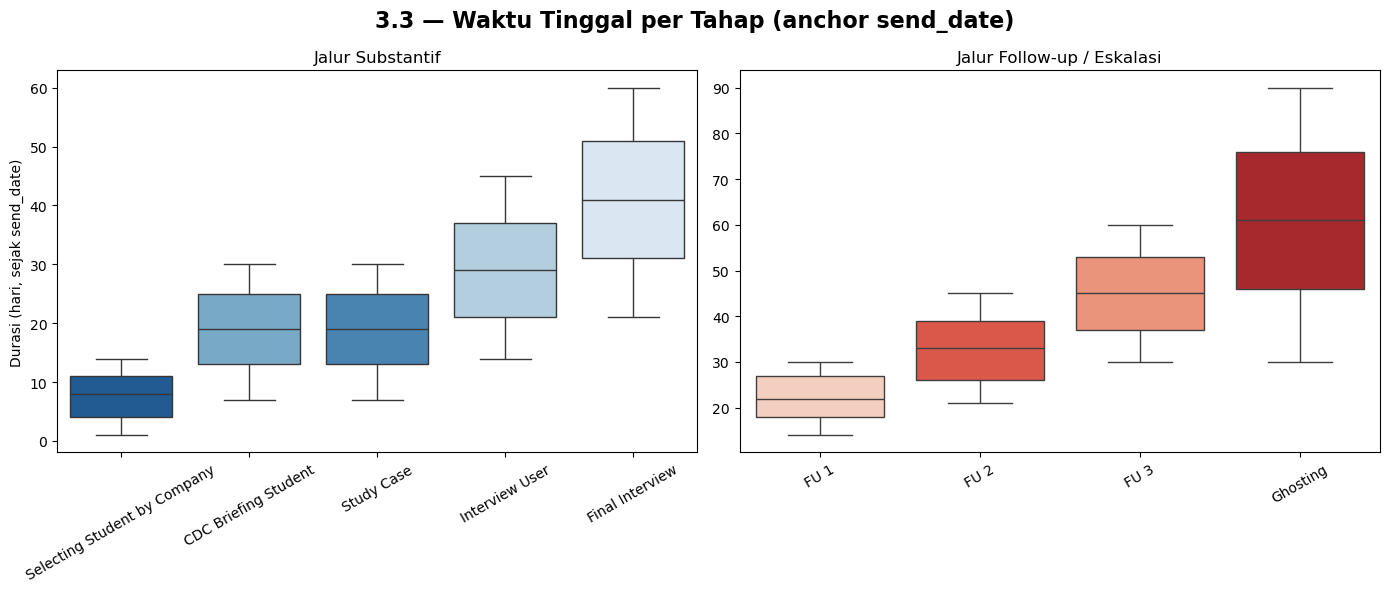

In [389]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "3.3 — Waktu Tinggal per Tahap (anchor send_date)", fontsize=16, fontweight="bold"
)

data_substantif = ts_with_send[ts_with_send["progress_student"].isin(jalur_substantif)]
sns.boxplot(
    data=data_substantif,
    x="progress_student",
    y="durasi_hari",
    order=jalur_substantif,
    hue="progress_student",
    palette="Blues",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Jalur Substantif")
axes[0].set_xlabel("")
axes[0].set_ylabel("Durasi (hari, sejak send_date)")
axes[0].tick_params(axis="x", rotation=30)

data_followup = ts_with_send[ts_with_send["progress_student"].isin(jalur_followup)]
sns.boxplot(
    data=data_followup,
    x="progress_student",
    y="durasi_hari",
    order=jalur_followup,
    hue="progress_student",
    palette="Reds",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Jalur Follow-up / Eskalasi")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 3.4a — Uji kepatuhan: apakah label bawaan cocok dengan ambang mingguan FAQ? [✓data]

In [390]:
ts_with_send = tracking_student.merge(
    tracking_company[["id_tracking_company", "send_date"]],
    on="id_tracking_company",
    how="left",
)
ts_with_send["hari_terlewat"] = (
    ts_with_send["last_update"] - ts_with_send["send_date"]
).dt.days

# Konvensi bracket EKSPLISIT: (batas_bawah, batas_atas] -- eksklusif bawah, inklusif atas
ambang = {
    "FU 1": (7, 14),
    "FU 2": (14, 21),
    "FU 3": (21, 28),
    "Ghosting": (28, None),  # > 28, tanpa batas atas
}

print("Konvensi: (batas_bawah, batas_atas] -- eksklusif bawah, inklusif atas\n")

hasil = []
for label, (lo, hi) in ambang.items():
    subset = ts_with_send[ts_with_send["progress_student"] == label]
    n = len(subset)

    if hi is None:
        patuh = (subset["hari_terlewat"] > lo).sum()
        window_str = f"> {lo}"
    else:
        patuh = ((subset["hari_terlewat"] > lo) & (subset["hari_terlewat"] <= hi)).sum()
        window_str = f"({lo}, {hi}]"

    pct_patuh = patuh / n * 100
    hasil.append(
        {
            "label": label,
            "jendela_faq": window_str,
            "n": n,
            "median_hari": subset["hari_terlewat"].median(),
            "min_hari": subset["hari_terlewat"].min(),
            "max_hari": subset["hari_terlewat"].max(),
            "%_patuh": pct_patuh,
        }
    )

kepatuhan_df = pd.DataFrame(hasil)
print(kepatuhan_df.to_string(index=False))

# Cek monotonisitas median
medians = kepatuhan_df["median_hari"].tolist()
is_monoton = all(medians[i] < medians[i + 1] for i in range(len(medians) - 1))
print(f"\n>>> Urutan median monoton naik? {is_monoton}")
print(f">>> Median berurutan: {' -> '.join(str(m) for m in medians)}")

print(
    """
KESIMPULAN: kepatuhan ketat terhadap ambang mingguan FAQ sangat rendah
(FU1/FU2/FU3), tapi urutan tetap monoton sempurna dan jarak antar tahap
konsisten. Ini menunjukkan data TIDAK dibangun dari penerapan harfiah
rumus FAQ ke last_update -- FAQ berfungsi sebagai panduan metodologi,
bukan cetak biru pembuatan data. Label bawaan bergeser sistematis ~1
minggu lebih lambat dari ambang resminya.
"""
)

Konvensi: (batas_bawah, batas_atas] -- eksklusif bawah, inklusif atas

   label jendela_faq    n  median_hari  min_hari  max_hari    %_patuh
    FU 1     (7, 14] 2062         22.0        14        30   5.916586
    FU 2    (14, 21] 1657         33.0        21        45   3.862402
    FU 3    (21, 28] 1236         45.0        30        60   0.000000
Ghosting        > 28 2905         61.0        30        90 100.000000

>>> Urutan median monoton naik? True
>>> Median berurutan: 22.0 -> 33.0 -> 45.0 -> 61.0

KESIMPULAN: kepatuhan ketat terhadap ambang mingguan FAQ sangat rendah
(FU1/FU2/FU3), tapi urutan tetap monoton sempurna dan jarak antar tahap
konsisten. Ini menunjukkan data TIDAK dibangun dari penerapan harfiah
rumus FAQ ke last_update -- FAQ berfungsi sebagai panduan metodologi,
bukan cetak biru pembuatan data. Label bawaan bergeser sistematis ~1
minggu lebih lambat dari ambang resminya.



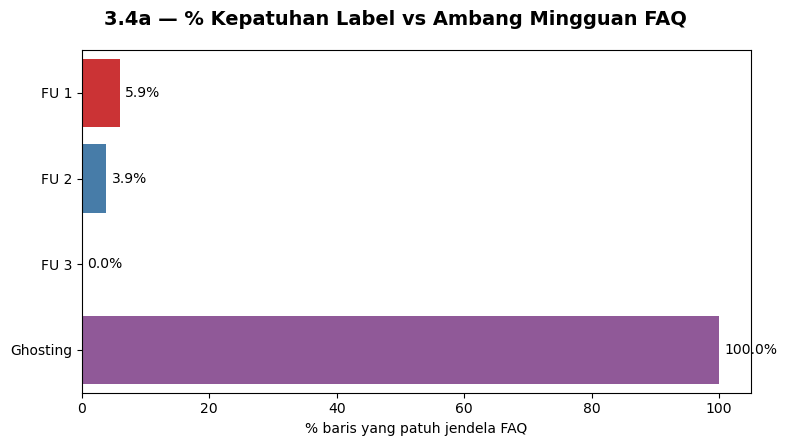

In [391]:
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.suptitle(
    "3.4a — % Kepatuhan Label vs Ambang Mingguan FAQ", fontsize=14, fontweight="bold"
)

sns.barplot(
    data=kepatuhan_df,
    x="%_patuh",
    y="label",
    hue="label",
    palette="Set1",
    legend=False,
    ax=ax,
)

ax.set_xlabel("% baris yang patuh jendela FAQ")
ax.set_ylabel("")
ax.set_xlim(0, 105)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

plt.tight_layout()
plt.show()

### 3.4b — Klasifikasi final_outcome konsisten: 2 bucket, 1 rumus [+][✓data] (metodologi utama BT-05 — insight terkuat)

In [392]:
ts_with_send = tracking_student.merge(
    tracking_company[["id_tracking_company", "send_date"]],
    on="id_tracking_company",
    how="left",
)
ts_with_send["hari_terlewat"] = (
    ts_with_send["last_update"] - ts_with_send["send_date"]
).dt.days

keputusan_nyata = [
    "Placement",
    "Rejection Screening CV",
    "Rejection Interview User",
    "Rejection Study Case",
    "Rejection Final Interview",
]
tanpa_keputusan = ["On Progress", "Ghosting"]


def klasifikasi_formula(hari):
    if hari > 28:
        return "Ghosting"
    elif hari > 21:
        return "FU3"
    elif hari > 14:
        return "FU2"
    elif hari > 7:
        return "FU1"
    else:
        return "<=1 minggu"


bucket1_mask = ts_with_send["rejection"].isin(keputusan_nyata)
bucket2_mask = ts_with_send["rejection"].isin(tanpa_keputusan)

print(
    f"Bucket 1 (ada keputusan nyata): {bucket1_mask.sum():,} baris -- dipakai apa adanya"
)
print(
    f"Bucket 2 (tidak ada keputusan) : {bucket2_mask.sum():,} baris -- rumus seragam diterapkan"
)
print(f"Total: {bucket1_mask.sum() + bucket2_mask.sum():,} (harus 41.600)\n")

ts_with_send["final_outcome"] = None
ts_with_send.loc[bucket1_mask, "final_outcome"] = ts_with_send.loc[
    bucket1_mask, "rejection"
]
ts_with_send.loc[bucket2_mask, "final_outcome"] = ts_with_send.loc[
    bucket2_mask, "hari_terlewat"
].apply(klasifikasi_formula)

print("Distribusi final_outcome (semua 41.600 baris):")
final_counts = ts_with_send["final_outcome"].value_counts()
final_pct = ts_with_send["final_outcome"].value_counts(normalize=True) * 100
outcome_summary = pd.DataFrame({"n": final_counts, "%": final_pct.round(1)})
print(outcome_summary)

Bucket 1 (ada keputusan nyata): 20,691 baris -- dipakai apa adanya
Bucket 2 (tidak ada keputusan) : 20,909 baris -- rumus seragam diterapkan
Total: 41,600 (harus 41.600)

Distribusi final_outcome (semua 41.600 baris):
                               n     %
final_outcome                         
Ghosting                   11094  26.7
Placement                   8955  21.5
Rejection Interview User    3805   9.1
FU3                         3546   8.5
Rejection Screening CV      3368   8.1
FU2                         2921   7.0
Rejection Study Case        2509   6.0
FU1                         2163   5.2
Rejection Final Interview   2054   4.9
<=1 minggu                  1185   2.8


In [393]:
n_ghosting_raw = (ts_with_send["rejection"] == "Ghosting").sum()
n_ghosting_formula = (ts_with_send["final_outcome"] == "Ghosting").sum()
n_total = len(ts_with_send)

print("-- Ghosting: DUA ANGKA (wajib disajikan berdampingan) --\n")
print(
    f"Label mentah (rejection=='Ghosting')     : {n_ghosting_raw:,} ({n_ghosting_raw/n_total*100:.1f}%)"
)
print(
    f"Rumus-FAQ konsisten (final_outcome)      : {n_ghosting_formula:,} ({n_ghosting_formula/n_total*100:.1f}%)"
)
print(
    f"Faktor lonjakan                          : {n_ghosting_formula/n_ghosting_raw:.1f}x"
)

print("\n-- Rekonsiliasi dalam bucket 'tidak ada keputusan' --")
bucket2 = ts_with_send[bucket2_mask]
ghosting_label_awal = bucket2[bucket2["rejection"] == "Ghosting"]
tetap_ghosting = (ghosting_label_awal["final_outcome"] == "Ghosting").sum()
turun_status = (ghosting_label_awal["final_outcome"] != "Ghosting").sum()

on_progress_awal = bucket2[bucket2["rejection"] == "On Progress"]
op_jadi_ghosting = (on_progress_awal["final_outcome"] == "Ghosting").sum()

print(f"Dari {len(ghosting_label_awal):,} baris berlabel Ghosting mentah:")
print(f"   tetap Ghosting setelah diuji ulang : {tetap_ghosting:,}")
print(f"   turun status (belum cukup lama)    : {turun_status:,}")
print(f"\nDari {len(on_progress_awal):,} baris On Progress:")
print(
    f"   direklasifikasi jadi Ghosting (>28 hari) : {op_jadi_ghosting:,} ({op_jadi_ghosting/len(on_progress_awal)*100:.1f}%)"
)
print(
    f"\n>>> Total Ghosting akhir = {tetap_ghosting:,} + {op_jadi_ghosting:,} = {tetap_ghosting + op_jadi_ghosting:,}"
)

print(
    """
HEADLINE (versi aman untuk dashboard):
"Berdasarkan aturan send_date panitia, Ghosting menjadi outcome paling
umum di seluruh sistem placement (26,7%) -- melampaui keberhasilan
penempatan (21,5%); jauh lebih besar dari yang tertangkap label mentah
(8,2%), karena banyak proses berhenti tanpa dicatat."
"""
)

print(
    """
KLARIFIKASI ATRIBUSI (FAQ panitia): status Ghosting dalam analisis ini
diasumsikan berasal dari PIHAK PERUSAHAAN (bukan mahasiswa) -- konsisten
dengan cara hitung hari_terlewat yang mengukur lama perusahaan tidak
memberi keputusan sejak kandidat dikirim (send_date), bukan perilaku
mahasiswa.
"""
)

-- Ghosting: DUA ANGKA (wajib disajikan berdampingan) --

Label mentah (rejection=='Ghosting')     : 3,421 (8.2%)
Rumus-FAQ konsisten (final_outcome)      : 11,094 (26.7%)
Faktor lonjakan                          : 3.2x

-- Rekonsiliasi dalam bucket 'tidak ada keputusan' --
Dari 3,421 baris berlabel Ghosting mentah:
   tetap Ghosting setelah diuji ulang : 3,251
   turun status (belum cukup lama)    : 170

Dari 17,488 baris On Progress:
   direklasifikasi jadi Ghosting (>28 hari) : 7,843 (44.8%)

>>> Total Ghosting akhir = 3,251 + 7,843 = 11,094

HEADLINE (versi aman untuk dashboard):
"Berdasarkan aturan send_date panitia, Ghosting menjadi outcome paling
umum di seluruh sistem placement (26,7%) -- melampaui keberhasilan
penempatan (21,5%); jauh lebih besar dari yang tertangkap label mentah
(8,2%), karena banyak proses berhenti tanpa dicatat."


KLARIFIKASI ATRIBUSI (FAQ panitia): status Ghosting dalam analisis ini
diasumsikan berasal dari PIHAK PERUSAHAAN (bukan mahasiswa) -- konsisten


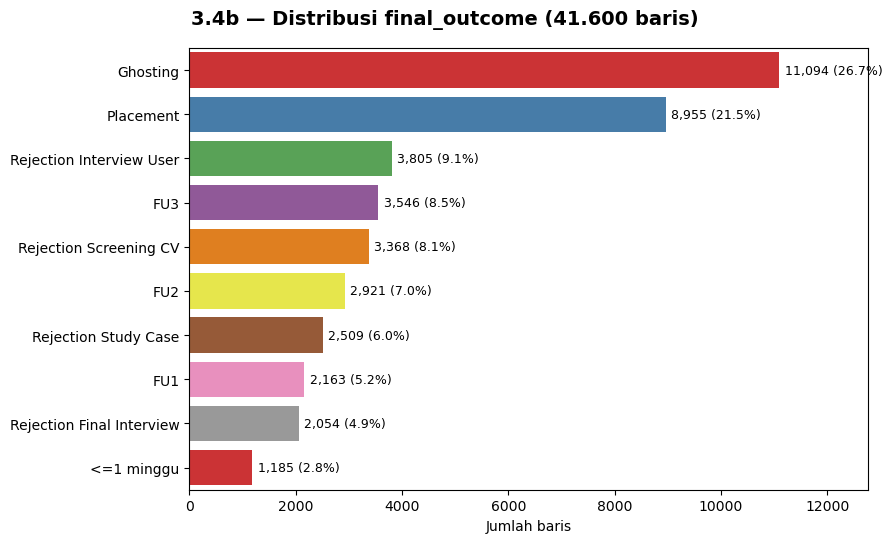

In [394]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.suptitle(
    "3.4b — Distribusi final_outcome (41.600 baris)", fontsize=14, fontweight="bold"
)

order = final_counts.sort_values(ascending=False)
sns.barplot(
    x=order.values,
    y=order.index,
    hue=order.index,
    palette="Set1",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Jumlah baris")
ax.set_ylabel("")
ax.set_xlim(0, order.max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels = [f"{v:,.0f} ({v/n_total*100:.1f}%)" for v in container.datavalues]
        ax.bar_label(container, labels=labels, padding=4, fontsize=9)

plt.tight_layout()
plt.show()

### 3.4c — Breakdown lokasi & waktu ghosting terbesar [✓data]

In [395]:
ghosting_df = ts_with_send[ts_with_send["final_outcome"] == "Ghosting"].copy()

print(f"Total baris Ghosting: {len(ghosting_df):,}\n")

# -- Top posisi: volume ghosting terbanyak --
top_posisi_volume = ghosting_df["position"].value_counts().head(15)
print("Top 15 posisi dengan VOLUME ghosting terbanyak:")
print(top_posisi_volume)

# -- Top posisi: rate ghosting tertinggi (min volume >= 20 baris total) --
posisi_total = ts_with_send.groupby("position").size()
posisi_ghosting = (
    ts_with_send[ts_with_send["final_outcome"] == "Ghosting"].groupby("position").size()
)

posisi_summary = pd.DataFrame(
    {
        "total_baris": posisi_total,
        "jumlah_ghosting": posisi_ghosting,
    }
).fillna(0)
posisi_summary["jumlah_ghosting"] = posisi_summary["jumlah_ghosting"].astype(int)
posisi_summary["rate_ghosting"] = (
    posisi_summary["jumlah_ghosting"] / posisi_summary["total_baris"] * 100
)

posisi_min20 = posisi_summary[posisi_summary["total_baris"] >= 20].sort_values(
    "rate_ghosting", ascending=False
)
print(f"\nTop 15 posisi dengan RATE ghosting tertinggi (min 20 baris total):")
print(posisi_min20.head(15))

# -- Top company: volume & rate --
company_total = ts_with_send.groupby("company").size()
company_ghosting = (
    ts_with_send[ts_with_send["final_outcome"] == "Ghosting"].groupby("company").size()
)

company_summary = pd.DataFrame(
    {
        "total_baris": company_total,
        "jumlah_ghosting": company_ghosting,
    }
).fillna(0)
company_summary["jumlah_ghosting"] = company_summary["jumlah_ghosting"].astype(int)
company_summary["rate_ghosting"] = (
    company_summary["jumlah_ghosting"] / company_summary["total_baris"] * 100
)

company_min20 = company_summary[company_summary["total_baris"] >= 20].sort_values(
    "rate_ghosting", ascending=False
)
print(f"\nTop 15 company dengan RATE ghosting tertinggi (min 20 baris total):")
print(company_min20.head(15))

Total baris Ghosting: 11,094

Top 15 posisi dengan VOLUME ghosting terbanyak:
position
Data Analyst                   1256
IT Support                      870
Quality Control Staff           379
Mechanical Engineer Intern      335
Digital Marketing Intern        331
Data Entry Operator             329
Business Analyst                309
IT Staff                        299
Business Development Intern     293
Customer Service Intern         241
Marketing Intern                207
UI/UX Designer                  193
Research Assistant              193
Accounting Staff                188
HSE Intern                      188
Name: count, dtype: int64

Top 15 posisi dengan RATE ghosting tertinggi (min 20 baris total):
                            total_baris  jumlah_ghosting  rate_ghosting
position                                                               
Operations Intern                   411              133      32.360097
Industrial Engineer Intern          284               91      3

count    11094.000000
mean        49.037408
std         16.914475
min         29.000000
25%         35.000000
50%         44.000000
75%         59.000000
max         90.000000
Name: hari_terlewat, dtype: float64

Median: 44 hari sebelum akhirnya dianggap Ghosting


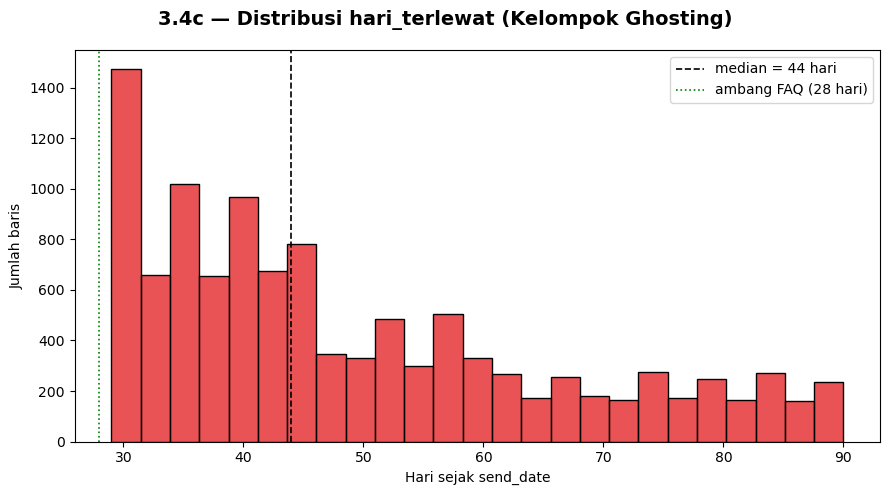

In [396]:
print(ghosting_df["hari_terlewat"].describe())
print(
    f"\nMedian: {ghosting_df['hari_terlewat'].median():.0f} hari sebelum akhirnya dianggap Ghosting"
)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    "3.4c — Distribusi hari_terlewat (Kelompok Ghosting)",
    fontsize=14,
    fontweight="bold",
)

sns.histplot(
    ghosting_df["hari_terlewat"], bins=25, ax=ax, color=sns.color_palette("Set1")[0]
)
ax.axvline(
    ghosting_df["hari_terlewat"].median(),
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"median = {ghosting_df['hari_terlewat'].median():.0f} hari",
)
ax.axvline(
    28, color="green", linestyle=":", linewidth=1.2, label="ambang FAQ (28 hari)"
)
ax.legend()
ax.set_xlabel("Hari sejak send_date")
ax.set_ylabel("Jumlah baris")

plt.tight_layout()
plt.show()

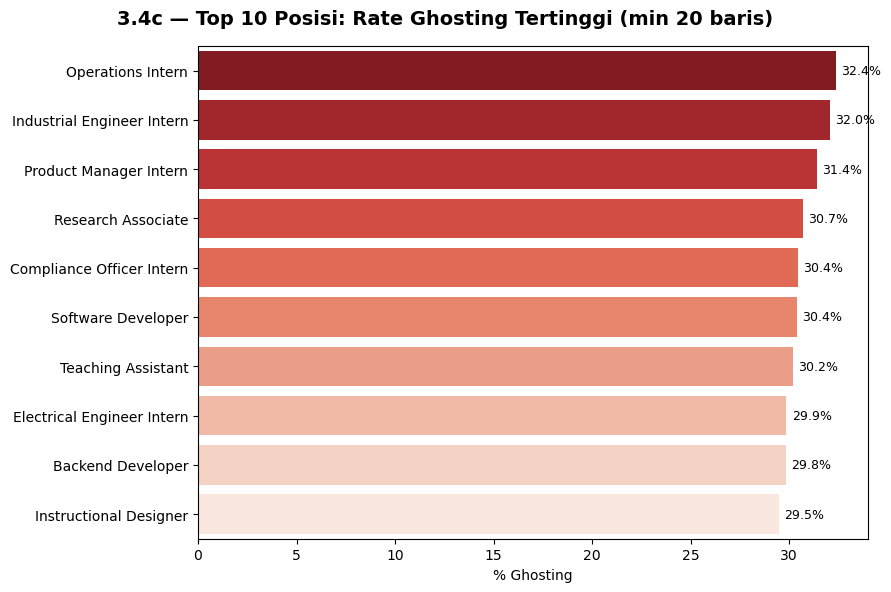

In [397]:
top10_posisi = posisi_min20.head(10).reset_index().rename(columns={"index": "position"})

fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle(
    "3.4c — Top 10 Posisi: Rate Ghosting Tertinggi (min 20 baris)",
    fontsize=14,
    fontweight="bold",
)

sns.barplot(
    data=top10_posisi,
    x="rate_ghosting",
    y="position",
    hue="position",
    palette="Reds_r",
    legend=False,
    ax=ax,
)
ax.set_xlabel("% Ghosting")
ax.set_ylabel("")

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

### 3.4d — Catatan kualitas data: proses ditutup tanpa hasil tercatat [✓data]

In [398]:
finish_on_progress = tracking_student[
    (tracking_student["progress_student"] == "Finish")
    & (tracking_student["rejection"] == "On Progress")
].copy()

total_finish = (tracking_student["progress_student"] == "Finish").sum()
n_kontradiktif = len(finish_on_progress)
pct_dari_finish = n_kontradiktif / total_finish * 100

print(f"Total baris berlabel progress_student == 'Finish': {total_finish:,}")
print(
    f"Dari jumlah itu, rejection masih 'On Progress'    : {n_kontradiktif:,} ({pct_dari_finish:.1f}%)\n"
)

print("Definisi dokumentasi 'Finish': \"proses selesai, baik berhasil maupun")
print("tidak, tanpa tindak lanjut lebih jauh\" -- tapi rejection='On Progress'")
print("berarti 'belum ada keputusan'. Ini KONTRADIKTIF: proses sudah ditutup,")
print("tapi hasilnya tidak pernah dicatat.\n")

print(f">>> Kemungkinan besar: proses ini DITUTUP oleh CDC tanpa mencatat")
print(f"    hasil akhirnya -- celah pencatatan operasional, bukan kesalahan data.")

Total baris berlabel progress_student == 'Finish': 5,442
Dari jumlah itu, rejection masih 'On Progress'    : 2,578 (47.4%)

Definisi dokumentasi 'Finish': "proses selesai, baik berhasil maupun
tidak, tanpa tindak lanjut lebih jauh" -- tapi rejection='On Progress'
berarti 'belum ada keputusan'. Ini KONTRADIKTIF: proses sudah ditutup,
tapi hasilnya tidak pernah dicatat.

>>> Kemungkinan besar: proses ini DITUTUP oleh CDC tanpa mencatat
    hasil akhirnya -- celah pencatatan operasional, bukan kesalahan data.


In [399]:
print("-- Breakdown: di mana kontradiksi ini paling sering terjadi --\n")

by_company = finish_on_progress["company"].value_counts().head(15)
print("Top 15 company (jumlah kasus Finish+On Progress):")
print(by_company)

by_position = finish_on_progress["position"].value_counts().head(15)
print("\nTop 15 posisi (jumlah kasus Finish+On Progress):")
print(by_position)

# Rate relatif terhadap total Finish per company (min 10 baris Finish)
finish_per_company = (
    tracking_student[tracking_student["progress_student"] == "Finish"]
    .groupby("company")
    .size()
)
kontradiktif_per_company = finish_on_progress.groupby("company").size()

rate_company = pd.DataFrame(
    {
        "total_finish": finish_per_company,
        "kontradiktif": kontradiktif_per_company,
    }
).fillna(0)
rate_company["kontradiktif"] = rate_company["kontradiktif"].astype(int)
rate_company["rate_kontradiksi"] = (
    rate_company["kontradiktif"] / rate_company["total_finish"] * 100
)

rate_company_min10 = rate_company[rate_company["total_finish"] >= 10].sort_values(
    "rate_kontradiksi", ascending=False
)
print(f"\nTop 10 company dengan RATE kontradiksi tertinggi (min 10 baris Finish):")
print(rate_company_min10.head(10))

-- Breakdown: di mana kontradiksi ini paling sering terjadi --

Top 15 company (jumlah kasus Finish+On Progress):
company
CV Perkasa Utama        10
PT Global Abadi         10
PT Mitra Bersama        10
CV Mandiri Terapan      10
PT Makmur Inovasi        9
PT Inovasi Bangsa        9
PT Kreasi Bangsa         9
CV Indo Sejahtera        9
CV Inovasi Konsultan     9
PT Sukses Global         8
PT Solusi Abadi          8
PT Bangkit Bangsa        8
PT Solusi Bangsa         8
CV Sentosa Inovasi       8
PT Nusa Nusantara        8
Name: count, dtype: int64

Top 15 posisi (jumlah kasus Finish+On Progress):
position
Data Analyst                   289
IT Support                     213
Digital Marketing Intern        84
Quality Control Staff           81
IT Staff                        79
Data Entry Operator             76
Mechanical Engineer Intern      65
Business Analyst                61
Marketing Staff                 59
Marketing Intern                57
Business Development Intern     55
Res

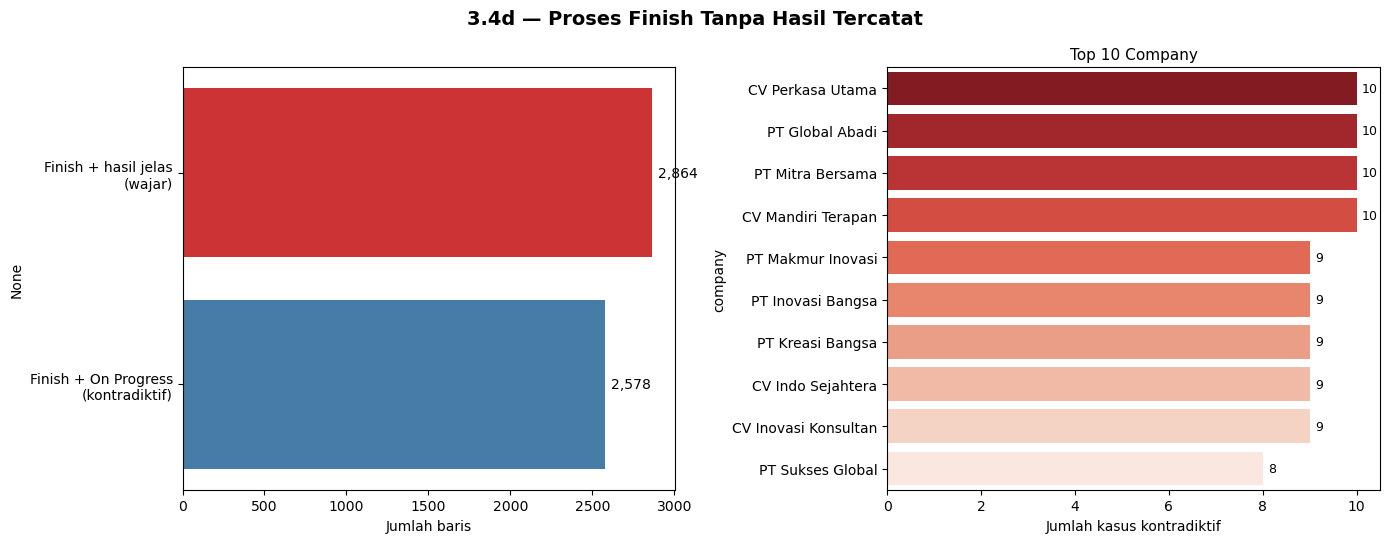


REKOMENDASI UNTUK LAPORAN:
Tim CDC perlu SOP "wajib isi alasan penutupan" saat menutup proses
(mengubah progress_student ke 'Finish') -- memastikan kolom rejection
ikut diperbarui ke hasil akhir yang sesuai (Placement/Rejection-X/Ghosting),
bukan dibiarkan 'On Progress'. Ini mencegah data placement/ghosting bolong
dan membuat metrik keberhasilan lebih akurat ke depannya.



In [400]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "3.4d — Proses Finish Tanpa Hasil Tercatat", fontsize=14, fontweight="bold"
)

# Chart 1: proporsi Finish yang kontradiktif vs wajar
kategori = pd.Series(
    {
        "Finish + hasil jelas\n(wajar)": total_finish - n_kontradiktif,
        "Finish + On Progress\n(kontradiktif)": n_kontradiktif,
    }
)
sns.barplot(
    x=kategori.values,
    y=kategori.index,
    hue=kategori.index,
    palette="Set1",
    legend=False,
    ax=axes[0],
)
axes[0].set_xlabel("Jumlah baris")
for container in axes[0].containers:
    if hasattr(container, "datavalues"):
        axes[0].bar_label(
            container,
            labels=[f"{v:,.0f}" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

# Chart 2: top 10 company kontradiksi terbanyak
top10_company = by_company.head(10)
sns.barplot(
    x=top10_company.values,
    y=top10_company.index,
    hue=top10_company.index,
    palette="Reds_r",
    legend=False,
    ax=axes[1],
)
axes[1].set_xlabel("Jumlah kasus kontradiktif")
axes[1].set_title("Top 10 Company", fontsize=11)
for container in axes[1].containers:
    if hasattr(container, "datavalues"):
        axes[1].bar_label(
            container,
            labels=[f"{v:,.0f}" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

print(
    """
REKOMENDASI UNTUK LAPORAN:
Tim CDC perlu SOP "wajib isi alasan penutupan" saat menutup proses
(mengubah progress_student ke 'Finish') -- memastikan kolom rejection
ikut diperbarui ke hasil akhir yang sesuai (Placement/Rejection-X/Ghosting),
bukan dibiarkan 'On Progress'. Ini mencegah data placement/ghosting bolong
dan membuat metrik keberhasilan lebih akurat ke depannya.
"""
)

In [401]:
print("-- Konteks: Dua Jalur Closure di progress_student --\n")

ct = pd.crosstab(tracking_student["progress_student"], tracking_student["rejection"])
print(ct)

print(
    """
POLA YANG TERAMATI (bukan pernyataan resmi dari dokumentasi, murni
kesimpulan dari pola data):

Placement, Rejected, dan Ghosting sebagai nilai progress_student SELALU
berpasangan 1-lawan-1 secara bersih dengan rejection yang sesuai -- tidak
pernah tercampur. Sebaliknya, Finish adalah SATU-SATUNYA nilai progress_student
yang tersebar ke berbagai rejection (Placement, Ghosting, Rejection-X, dan
On Progress).

HIPOTESIS: kemungkinan ada dua jalur berbeda menuju status "selesai" --
(1) jalur alami lewat tahapan berurutan yang otomatis konsisten, dan
(2) jalur "Finish" yang bersifat lebih administratif/manual, di mana
progress_student dan rejection diisi terpisah -- membuka celah salah satu
kolom lupa diperbarui. Ini kemungkinan besar akar penyebab 2.578 kasus
kontradiktif yang ditemukan di 3.4d.

Catatan: ini interpretasi berdasarkan pola data, BUKAN konfirmasi resmi
dari dokumentasi sistem -- disampaikan dengan derajat kepastian yang sesuai.
"""
)

-- Konteks: Dua Jalur Closure di progress_student --

rejection                     Ghosting  On Progress  Placement  Rejection Final Interview  Rejection Interview User  \
progress_student                                                                                                      
CDC Briefing Student                 0         1619          0                          0                         0   
FU 1                                 0         2062          0                          0                         0   
FU 2                                 0         1657          0                          0                         0   
FU 3                                 0         1236          0                          0                         0   
Final Interview                      0         1707          0                          0                         0   
Finish                             516         2578       1421                          0                       4

### 3.5 — Tahap terakhir sebelum ghosting

In [402]:
ghosting_df = ts_with_send[ts_with_send["final_outcome"] == "Ghosting"].copy()

print(f"Total baris final_outcome == 'Ghosting': {len(ghosting_df):,}\n")

tahap_terakhir = ghosting_df["progress_student"].value_counts()
tahap_terakhir_pct = ghosting_df["progress_student"].value_counts(normalize=True) * 100

tahap_summary = pd.DataFrame({"n": tahap_terakhir, "%": tahap_terakhir_pct.round(1)})
print(
    "Distribusi progress_student ASLI (tahap terakhir tercatat) untuk kelompok Ghosting:"
)
print(tahap_summary)

# Kelompokkan jadi kategori bermakna
tahap_awal = ["Selecting Student by Company", "CDC Briefing Student", "Study Case"]
tahap_lanjut = ["Interview User", "Final Interview"]
tahap_followup_asli = ["FU 1", "FU 2", "FU 3"]

n_awal = ghosting_df["progress_student"].isin(tahap_awal).sum()
n_lanjut = ghosting_df["progress_student"].isin(tahap_lanjut).sum()
n_followup = ghosting_df["progress_student"].isin(tahap_followup_asli).sum()
n_lainnya = len(ghosting_df) - n_awal - n_lanjut - n_followup

print(f"\nRingkasan kelompok:")
print(
    f"   Tahap awal (Selecting/Briefing/Study Case) : {n_awal:,} ({n_awal/len(ghosting_df)*100:.1f}%)"
)
print(
    f"   Tahap lanjut (Interview User/Final)         : {n_lanjut:,} ({n_lanjut/len(ghosting_df)*100:.1f}%)"
)
print(
    f"   Sudah di tahap follow-up (FU1/2/3)           : {n_followup:,} ({n_followup/len(ghosting_df)*100:.1f}%)"
)
print(
    f"   Lainnya (sudah berlabel Finish/Ghosting)     : {n_lainnya:,} ({n_lainnya/len(ghosting_df)*100:.1f}%)"
)

# -- Kesimpulan berbasis kelompok bermakna (bukan tautologi progress_student mentah) --
kelompok_bermakna = {
    "Tahap awal": n_awal,
    "Tahap lanjut": n_lanjut,
    "Follow-up": n_followup,
}
dominan_kelompok = max(kelompok_bermakna, key=kelompok_bermakna.get)
total_bermakna = sum(kelompok_bermakna.values())

print(f"\n>>> Di antara kasus dengan tahap substantif jelas ({total_bermakna:,} kasus,")
print(f"    setelah dikecualikan yang sudah kadung berlabel Finish/Ghosting):")
print(
    f">>> Ghosting PALING SERING terjadi setelah kandidat sudah masuk tahap: '{dominan_kelompok}'"
)
print(
    f"    ({kelompok_bermakna[dominan_kelompok]:,} kasus, {kelompok_bermakna[dominan_kelompok]/total_bermakna*100:.1f}% dari kasus bermakna)"
)

print(
    f"\n>>> Catatan: perusahaan JARANG menghilang di tahap awal ({n_awal/total_bermakna*100:.1f}%)"
)
print(f"    -- mereka justru lebih sering hilang SETELAH investasi waktu cukup besar")
print(f"    (interview/follow-up berkali-kali), bukan di awal proses.")

Total baris final_outcome == 'Ghosting': 11,094

Distribusi progress_student ASLI (tahap terakhir tercatat) untuk kelompok Ghosting:
                         n     %
progress_student                
Ghosting              2905  26.2
Finish                2159  19.5
Interview User        1712  15.4
Final Interview       1404  12.7
FU 3                  1236  11.1
FU 2                  1118  10.1
FU 1                   261   2.4
Study Case             160   1.4
CDC Briefing Student   139   1.3

Ringkasan kelompok:
   Tahap awal (Selecting/Briefing/Study Case) : 299 (2.7%)
   Tahap lanjut (Interview User/Final)         : 3,116 (28.1%)
   Sudah di tahap follow-up (FU1/2/3)           : 2,615 (23.6%)
   Lainnya (sudah berlabel Finish/Ghosting)     : 5,064 (45.6%)

>>> Di antara kasus dengan tahap substantif jelas (6,030 kasus,
    setelah dikecualikan yang sudah kadung berlabel Finish/Ghosting):
>>> Ghosting PALING SERING terjadi setelah kandidat sudah masuk tahap: 'Tahap lanjut'
    (3,116 k

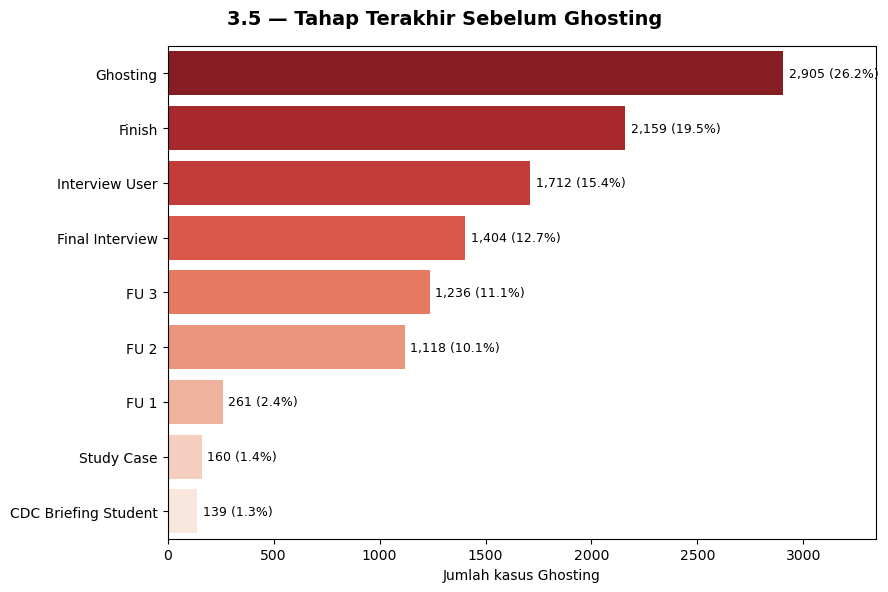

In [403]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle("3.5 — Tahap Terakhir Sebelum Ghosting", fontsize=14, fontweight="bold")

order = tahap_terakhir.sort_values(ascending=False)
sns.barplot(
    x=order.values,
    y=order.index,
    hue=order.index,
    palette="Reds_r",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Jumlah kasus Ghosting")
ax.set_ylabel("")
ax.set_xlim(0, order.max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels = [
            f"{v:,.0f} ({v/len(ghosting_df)*100:.1f}%)" for v in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=4, fontsize=9)

plt.tight_layout()
plt.show()

### 3.6 — Ghosting rate per jenis_penempatan & per company (pakai final_outcome)

In [404]:
jenis_total = ts_with_send.groupby("jenis_penempatan").size()
jenis_ghosting = (
    ts_with_send[ts_with_send["final_outcome"] == "Ghosting"]
    .groupby("jenis_penempatan")
    .size()
)

jenis_summary = pd.DataFrame(
    {
        "total_baris": jenis_total,
        "jumlah_ghosting": jenis_ghosting,
    }
).fillna(0)
jenis_summary["jumlah_ghosting"] = jenis_summary["jumlah_ghosting"].astype(int)
jenis_summary["rate_ghosting"] = (
    jenis_summary["jumlah_ghosting"] / jenis_summary["total_baris"] * 100
)
jenis_summary = jenis_summary.sort_values("rate_ghosting", ascending=False)

print("Ghosting rate per jenis_penempatan:")
print(jenis_summary)

Ghosting rate per jenis_penempatan:
                  total_baris  jumlah_ghosting  rate_ghosting
jenis_penempatan                                             
Part-time               10122             2721      26.882039
Full-time                6311             1680      26.620187
Magang                  25167             6693      26.594350


In [405]:
company_total = ts_with_send.groupby("company").size()
company_ghosting = (
    ts_with_send[ts_with_send["final_outcome"] == "Ghosting"].groupby("company").size()
)

company_summary = pd.DataFrame(
    {
        "total_baris": company_total,
        "jumlah_ghosting": company_ghosting,
    }
).fillna(0)
company_summary["jumlah_ghosting"] = company_summary["jumlah_ghosting"].astype(int)
company_summary["rate_ghosting"] = (
    company_summary["jumlah_ghosting"] / company_summary["total_baris"] * 100
)

company_min20 = company_summary[company_summary["total_baris"] >= 20].sort_values(
    "rate_ghosting", ascending=False
)
top10_company_ghosting = company_min20.head(10)

print(
    f"\nJumlah company dengan total_baris >= 20: {len(company_min20):,} (dari {len(company_summary):,} company total)\n"
)
print("Top 10 company dengan ghosting rate tertinggi (min 20 baris):")
print(top10_company_ghosting)


Jumlah company dengan total_baris >= 20: 802 (dari 1,488 company total)

Top 10 company dengan ghosting rate tertinggi (min 20 baris):
                      total_baris  jumlah_ghosting  rate_ghosting
company                                                          
PT Global Makmur               21               11      52.380952
PT Bina Perkasa                20               10      50.000000
PT Mandiri Indonesia           25               12      48.000000
PT Digital Media               23               11      47.826087
PT Mega Teknologi              21               10      47.619048
CV Techno Mandiri              32               15      46.875000
PT Prima Nusantara             54               25      46.296296
PT Solusi Nusantara            67               31      46.268657
PT Bumi Kreatif                22               10      45.454545
PT Graha Sentosa               33               15      45.454545


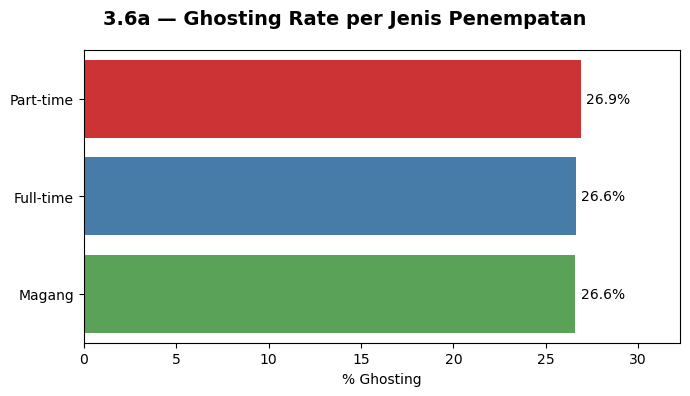

In [406]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle(
    "3.6a — Ghosting Rate per Jenis Penempatan", fontsize=14, fontweight="bold"
)

sns.barplot(
    x=jenis_summary["rate_ghosting"].values,
    y=jenis_summary.index,
    hue=jenis_summary.index,
    palette="Set1",
    legend=False,
    ax=ax,
)
ax.set_xlabel("% Ghosting")
ax.set_ylabel("")
ax.set_xlim(0, jenis_summary["rate_ghosting"].max() * 1.2)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

plt.tight_layout()
plt.show()

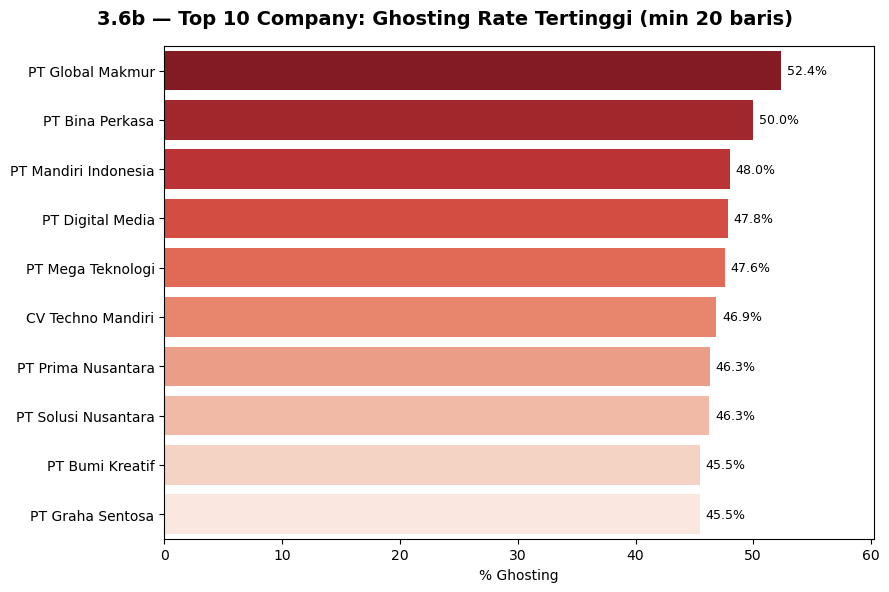

In [407]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle(
    "3.6b — Top 10 Company: Ghosting Rate Tertinggi (min 20 baris)",
    fontsize=14,
    fontweight="bold",
)

sns.barplot(
    x=top10_company_ghosting["rate_ghosting"].values,
    y=top10_company_ghosting.index,
    hue=top10_company_ghosting.index,
    palette="Reds_r",
    legend=False,
    ax=ax,
)
ax.set_xlabel("% Ghosting")
ax.set_ylabel("")
ax.set_xlim(0, top10_company_ghosting["rate_ghosting"].max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

### 3.7 — Lama proses Ghosting vs Placement (anchor send_date)

In [408]:
ghosting_durasi = ts_with_send[ts_with_send["final_outcome"] == "Ghosting"][
    "hari_terlewat"
]
placement_durasi = ts_with_send[ts_with_send["rejection"] == "Placement"][
    "hari_terlewat"
]

durasi_summary = pd.DataFrame(
    {
        "Ghosting": ghosting_durasi.describe(),
        "Placement": placement_durasi.describe(),
    }
)
print(durasi_summary.round(1))

median_ghosting = ghosting_durasi.median()
median_placement = placement_durasi.median()
selisih = median_ghosting - median_placement

print(f"\nMedian Ghosting  : {median_ghosting:.0f} hari")
print(f"Median Placement : {median_placement:.0f} hari")
print(
    f"Selisih          : {selisih:.0f} hari ({'Ghosting lebih lama' if selisih > 0 else 'Placement lebih lama'})"
)

print(
    """
CATATAN: last_update adalah proxy untuk tanggal keputusan/placement --
bukan tanggal presisi (asumsi sama seperti 3.4b). Sajikan sebagai
ESTIMASI, bukan durasi yang presisi ke satuan hari.
"""
)

       Ghosting  Placement
count   11094.0     8955.0
mean       49.0       57.4
std        16.9       19.9
min        29.0        1.0
25%        35.0       42.0
50%        44.0       58.0
75%        59.0       74.0
max        90.0       90.0

Median Ghosting  : 44 hari
Median Placement : 58 hari
Selisih          : -14 hari (Placement lebih lama)

CATATAN: last_update adalah proxy untuk tanggal keputusan/placement --
bukan tanggal presisi (asumsi sama seperti 3.4b). Sajikan sebagai
ESTIMASI, bukan durasi yang presisi ke satuan hari.



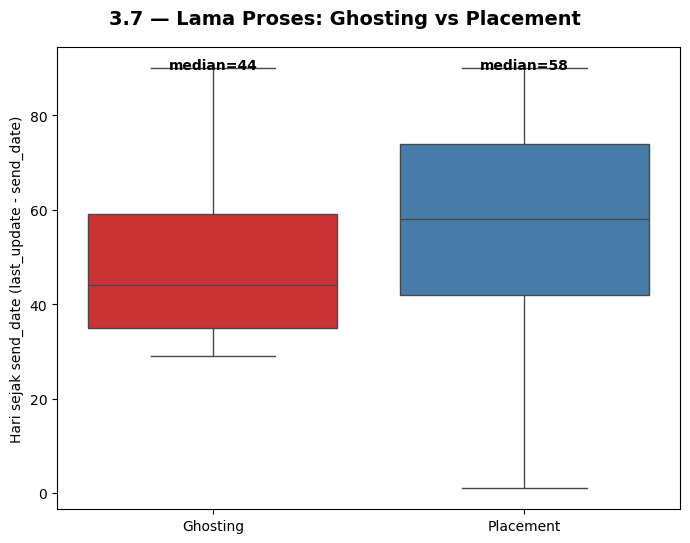

In [409]:
compare_df = pd.concat(
    [
        pd.DataFrame({"kelompok": "Ghosting", "hari_terlewat": ghosting_durasi}),
        pd.DataFrame({"kelompok": "Placement", "hari_terlewat": placement_durasi}),
    ]
)

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.suptitle("3.7 — Lama Proses: Ghosting vs Placement", fontsize=14, fontweight="bold")

sns.boxplot(
    data=compare_df,
    x="kelompok",
    y="hari_terlewat",
    hue="kelompok",
    palette="Set1",
    legend=False,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Hari sejak send_date (last_update - send_date)")

for i, kelompok in enumerate(["Ghosting", "Placement"]):
    median_val = compare_df[compare_df["kelompok"] == kelompok][
        "hari_terlewat"
    ].median()
    ax.text(
        i,
        ax.get_ylim()[1] * 0.95,
        f"median={median_val:.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## Bagian 4 — Funnel Hasil & Keberhasilan (BT-04, BT-07) → H3

### 4.1 — Definisi placement rate yang benar (subbagian kunci) [✓data]

In [410]:
n_on_progress_mentah = (ts_with_send["rejection"] == "On Progress").sum()

# (a) SALAH -- denominator penuh, semua baris apa adanya
denom_a = total_baris
rate_a = n_placement / denom_a * 100

# (b) LAMA -- exclude SEMUA rejection=='On Progress' mentah
denom_b = total_baris - n_on_progress_mentah
rate_b = n_placement / denom_b * 100

# (c) BENAR -- exclude HANYA yang genuinely masih aktif
masih_aktif = ["<=1 minggu", "FU1", "FU2", "FU3"]
n_masih_aktif = ts_with_send["final_outcome"].isin(masih_aktif).sum()
denom_c = total_baris - n_masih_aktif
rate_c = n_placement / denom_c * 100

# Berapa banyak dari yang berlabel "On Progress" mentah yang SEBENARNYA sudah Ghosting?
on_progress_rows = ts_with_send[ts_with_send["rejection"] == "On Progress"]
n_salah_klasifikasi = (on_progress_rows["final_outcome"] == "Ghosting").sum()

tabel_rate = pd.DataFrame(
    {
        "versi": [
            "(a) SALAH -- basis penuh",
            "(b) LAMA -- exclude semua On Progress mentah",
            "(c) BENAR -- exclude hanya yang genuinely aktif",
        ],
        "denominator": [denom_a, denom_b, denom_c],
        "placement_rate_%": [rate_a, rate_b, rate_c],
    }
)
print(tabel_rate.to_string(index=False))

print(
    f"""
CATATAN PER VERSI:
(a) {rate_a:.1f}% -- TERLALU RENDAH. Bug asli: placement dibagi seluruh baris,
    termasuk proses yang jelas masih berjalan (FU1/2/3, <=1 minggu) yang
    memang belum seharusnya punya hasil apa pun.

(b) {rate_b:.1f}% -- TERLALU OPTIMIS. Salah karena membuang SEMUA {n_on_progress_mentah:,}
    baris rejection=='On Progress' mentah -- padahal {n_salah_klasifikasi:,} di
    antaranya SEBENARNYA sudah lewat ambang 28 hari (harusnya Ghosting,
    dihitung sebagai KEGAGALAN, bukan dikecualikan dari perhitungan).

(c) {rate_c:.1f}% -- PALING AKURAT. Exclude HANYA baris yang genuinely
    masih aktif ({n_masih_aktif:,} baris: <=1 minggu/FU1/FU2/FU3).
    Ghosting dihitung sebagai outcome RESOLVED (gagal), bukan dikecualikan.
    Ini angka RESMI yang dipakai di seluruh Bagian 4 selanjutnya.
"""
)

                                          versi  denominator  placement_rate_%
                       (a) SALAH -- basis penuh        41600         21.526442
   (b) LAMA -- exclude semua On Progress mentah        24112         37.139184
(c) BENAR -- exclude hanya yang genuinely aktif        31785         28.173667

CATATAN PER VERSI:
(a) 21.5% -- TERLALU RENDAH. Bug asli: placement dibagi seluruh baris,
    termasuk proses yang jelas masih berjalan (FU1/2/3, <=1 minggu) yang
    memang belum seharusnya punya hasil apa pun.

(b) 37.1% -- TERLALU OPTIMIS. Salah karena membuang SEMUA 17,488
    baris rejection=='On Progress' mentah -- padahal 7,843 di
    antaranya SEBENARNYA sudah lewat ambang 28 hari (harusnya Ghosting,
    dihitung sebagai KEGAGALAN, bukan dikecualikan dari perhitungan).

(c) 28.2% -- PALING AKURAT. Exclude HANYA baris yang genuinely
    masih aktif (9,815 baris: <=1 minggu/FU1/FU2/FU3).
    Ghosting dihitung sebagai outcome RESOLVED (gagal), bukan dikecualikan.
    In

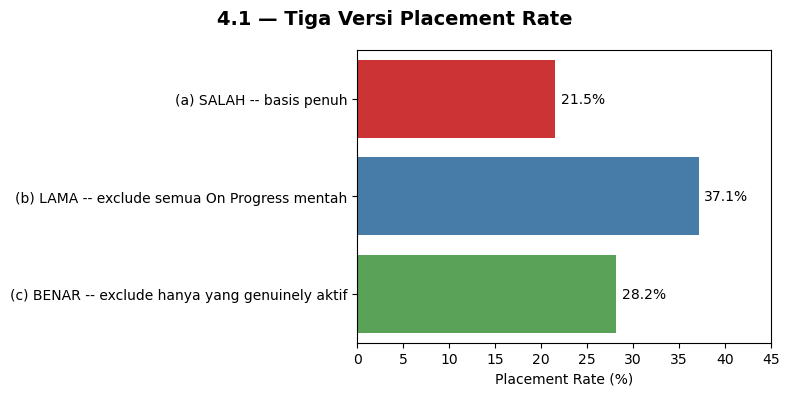

In [411]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("4.1 — Tiga Versi Placement Rate", fontsize=14, fontweight="bold")

sns.barplot(
    data=tabel_rate,
    x="placement_rate_%",
    y="versi",
    hue="versi",
    palette="Set1",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Placement Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, 45)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

plt.tight_layout()
plt.show()

In [412]:
print(
    """
PERINGATAN LABEL -- RATE vs SHARE (mudah tertukar, sama-sama ~20-an%):

28,2% = PLACEMENT RATE
        = Placement / baris RESOLVED (yang sudah 41.785 - 9.815 = 31.785)
        -> metrik KEBERHASILAN, dipakai di seluruh analisis Bagian 4.

21,5% = PLACEMENT SHARE
        = Placement / SELURUH 41.600 baris
        -> metrik KOMPOSISI outcome (dipakai di 3.4b/4.3, bagian dari
           breakdown semua kemungkinan hasil: Ghosting/Placement/Rejection/dst).

Dua angka ini SAMA-SAMA BENAR, tapi punya denominator dan makna berbeda.
Dashboard/laporan WAJIB memberi label eksplisit ("rate" vs "share") di
sebelah tiap angka, supaya pembaca tidak keliru menyimpulkan salah satu
sebagai yang lain.
"""
)


PERINGATAN LABEL -- RATE vs SHARE (mudah tertukar, sama-sama ~20-an%):

28,2% = PLACEMENT RATE
        = Placement / baris RESOLVED (yang sudah 41.785 - 9.815 = 31.785)
        -> metrik KEBERHASILAN, dipakai di seluruh analisis Bagian 4.

21,5% = PLACEMENT SHARE
        = Placement / SELURUH 41.600 baris
        -> metrik KOMPOSISI outcome (dipakai di 3.4b/4.3, bagian dari
           breakdown semua kemungkinan hasil: Ghosting/Placement/Rejection/dst).

Dua angka ini SAMA-SAMA BENAR, tapi punya denominator dan makna berbeda.
Dashboard/laporan WAJIB memberi label eksplisit ("rate" vs "share") di
sebelah tiap angka, supaya pembaca tidak keliru menyimpulkan salah satu
sebagai yang lain.



### 4.2 — PER-STUDENT outcome — lensa manusiawi [+][✓data] (hilang di rencana lama)

In [413]:
ever_placed = ts_with_send.groupby("NIM")["rejection"].apply(
    lambda x: (x == "Placement").any()
)
process_load_4 = ts_with_send.groupby("NIM").size()

student_outcome = pd.DataFrame(
    {
        "jumlah_proses": process_load_4,
        "ever_placed": ever_placed,
    }
)

n_partisipan = len(student_outcome)
n_ever_placed = student_outcome["ever_placed"].sum()
pct_ever_placed = n_ever_placed / n_partisipan * 100

print(f"Total partisipan (pernah masuk proses): {n_partisipan:,}")
print(
    f"Pernah placement minimal 1x            : {n_ever_placed:,} ({pct_ever_placed:.1f}%)"
)
print(
    f"\n>>> HEADLINE: {pct_ever_placed:.1f}% mahasiswa yang pernah mencoba, AKHIRNYA berhasil dapat placement."
)

Total partisipan (pernah masuk proses): 10,174
Pernah placement minimal 1x            : 5,759 (56.6%)

>>> HEADLINE: 56.6% mahasiswa yang pernah mencoba, AKHIRNYA berhasil dapat placement.


In [414]:
def bin_proses(n):
    if n == 1:
        return "1"
    elif n == 2:
        return "2"
    elif n == 3:
        return "3"
    elif n <= 5:
        return "4-5"
    else:
        return "6+"


student_outcome["bin_proses"] = student_outcome["jumlah_proses"].apply(bin_proses)

bin_order = ["1", "2", "3", "4-5", "6+"]
persistence = student_outcome.groupby("bin_proses")["ever_placed"].agg(["size", "sum"])
persistence.columns = ["jumlah_mahasiswa", "jumlah_placed"]
persistence["pct_placed"] = (
    persistence["jumlah_placed"] / persistence["jumlah_mahasiswa"] * 100
)
persistence = persistence.reindex(bin_order)

print("Ever-placed rate per jumlah proses yang diikuti:")
print(persistence)

rate_1 = persistence.loc["1", "pct_placed"]
rate_6plus = persistence.loc["6+", "pct_placed"]
print(f"\n>>> PERSISTENCE PAYS OFF: ikut 1 proses = {rate_1:.1f}% berhasil,")
print(
    f"    ikut 6+ proses = {rate_6plus:.1f}% berhasil -- selisih {rate_6plus - rate_1:.1f} poin persentase."
)

Ever-placed rate per jumlah proses yang diikuti:
            jumlah_mahasiswa  jumlah_placed  pct_placed
bin_proses                                             
1                       1329            292   21.971407
2                       1777            695   39.110861
3                       1765            878   49.745042
4-5                     2849           1888   66.268866
6+                      2454           2006   81.744091

>>> PERSISTENCE PAYS OFF: ikut 1 proses = 22.0% berhasil,
    ikut 6+ proses = 81.7% berhasil -- selisih 59.8 poin persentase.


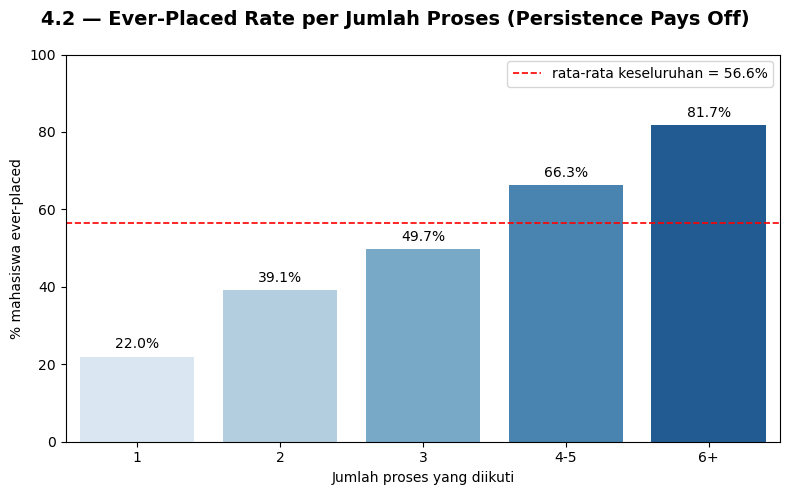

In [415]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(
    "4.2 — Ever-Placed Rate per Jumlah Proses (Persistence Pays Off)",
    fontsize=14,
    fontweight="bold",
)

sns.barplot(
    x=persistence.index,
    y=persistence["pct_placed"],
    hue=persistence.index,
    palette="Blues",
    legend=False,
    ax=ax,
    order=bin_order,
)
ax.axhline(
    pct_ever_placed,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"rata-rata keseluruhan = {pct_ever_placed:.1f}%",
)
ax.legend()

ax.set_xlabel("Jumlah proses yang diikuti")
ax.set_ylabel("% mahasiswa ever-placed")
ax.set_ylim(0, 100)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

plt.tight_layout()
plt.show()

### 4.3 — Distribusi final_outcome keseluruhan

In [416]:
final_counts = ts_with_send["final_outcome"].value_counts()
final_pct = ts_with_send["final_outcome"].value_counts(normalize=True) * 100
outcome_summary = pd.DataFrame(
    {"n": final_counts, "%": final_pct.round(1)}
).sort_values("n", ascending=False)

print("Distribusi final_outcome (41.600 baris):")
print(outcome_summary)

n_ghosting_final = (ts_with_send["final_outcome"] == "Ghosting").sum()
n_ghosting_label = (ts_with_send["rejection"] == "Ghosting").sum()
n_placement = (ts_with_send["final_outcome"] == "Placement").sum()

print(
    f"\n>>> Outcome TERBESAR: {outcome_summary.index[0]} ({outcome_summary.iloc[0]['n']:,.0f}, {outcome_summary.iloc[0]['%']}%)"
)
print(
    f">>> Ghosting ({n_ghosting_final/len(ts_with_send)*100:.1f}%) > Placement ({n_placement/len(ts_with_send)*100:.1f}%)"
)
print(
    f"    -- outcome terbesar justru KEGAGALAN karena tak direspons, bukan keberhasilan.\n"
)

print("Perbandingan Ghosting: label mentah vs setelah reklasifikasi:")
print(
    f"   Label mentah (rejection=='Ghosting')  : {n_ghosting_label:,} ({n_ghosting_label/len(ts_with_send)*100:.1f}%)"
)
print(
    f"   final_outcome (setelah rumus send_date): {n_ghosting_final:,} ({n_ghosting_final/len(ts_with_send)*100:.1f}%)"
)
print(
    f"   Faktor lonjakan                         : {n_ghosting_final/n_ghosting_label:.1f}x"
)

Distribusi final_outcome (41.600 baris):
                               n     %
final_outcome                         
Ghosting                   11094  26.7
Placement                   8955  21.5
Rejection Interview User    3805   9.1
FU3                         3546   8.5
Rejection Screening CV      3368   8.1
FU2                         2921   7.0
Rejection Study Case        2509   6.0
FU1                         2163   5.2
Rejection Final Interview   2054   4.9
<=1 minggu                  1185   2.8

>>> Outcome TERBESAR: Ghosting (11,094, 26.7%)
>>> Ghosting (26.7%) > Placement (21.5%)
    -- outcome terbesar justru KEGAGALAN karena tak direspons, bukan keberhasilan.

Perbandingan Ghosting: label mentah vs setelah reklasifikasi:
   Label mentah (rejection=='Ghosting')  : 3,421 (8.2%)
   final_outcome (setelah rumus send_date): 11,094 (26.7%)
   Faktor lonjakan                         : 3.2x


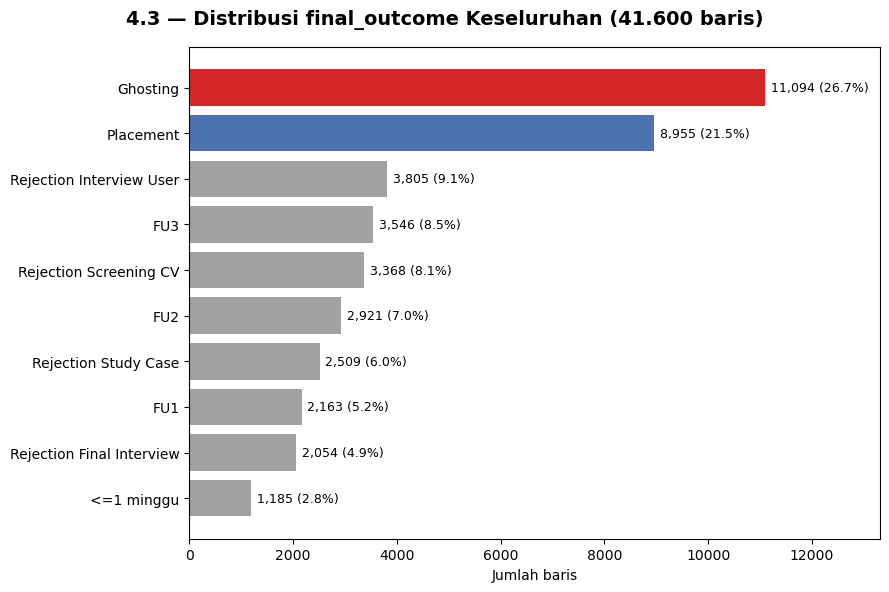

In [417]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.suptitle(
    "4.3 — Distribusi final_outcome Keseluruhan (41.600 baris)",
    fontsize=14,
    fontweight="bold",
)

order = outcome_summary.sort_values("n", ascending=True)
colors = [
    "#d62728" if idx == "Ghosting" else "#4c72b0" if idx == "Placement" else "#a0a0a0"
    for idx in order.index
]

bars = ax.barh(order.index, order["n"], color=colors)
ax.set_xlabel("Jumlah baris")
ax.set_xlim(0, order["n"].max() * 1.2)

for bar, n, pct in zip(bars, order["n"], order["%"]):
    ax.text(
        bar.get_width() + order["n"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{n:,.0f} ({pct}%)",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

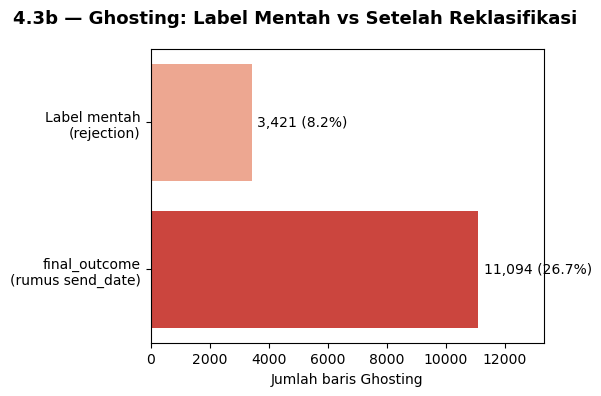

In [418]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.suptitle(
    "4.3b — Ghosting: Label Mentah vs Setelah Reklasifikasi",
    fontsize=13,
    fontweight="bold",
)

banding = pd.DataFrame(
    {
        "versi": ["Label mentah\n(rejection)", "final_outcome\n(rumus send_date)"],
        "jumlah": [n_ghosting_label, n_ghosting_final],
    }
)

sns.barplot(
    data=banding,
    x="jumlah",
    y="versi",
    hue="versi",
    palette="Reds",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Jumlah baris Ghosting")
ax.set_ylabel("")
ax.set_xlim(0, n_ghosting_final * 1.2)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels = [
            f"{v:,.0f} ({v/len(ts_with_send)*100:.1f}%)" for v in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=4, fontsize=10)

plt.tight_layout()
plt.show()

### 4.4 — Placement rate per program_studi

In [419]:
masih_aktif = ["<=1 minggu", "FU1", "FU2", "FU3"]
resolved_df = ts_with_send[~ts_with_send["final_outcome"].isin(masih_aktif)].copy()

# gabung program_studi dari student_all
resolved_df = resolved_df.merge(
    student_all[["NIM", "program_studi"]], on="NIM", how="left"
)

prodi_total = resolved_df.groupby("program_studi").size()
prodi_placement = (
    resolved_df[resolved_df["final_outcome"] == "Placement"]
    .groupby("program_studi")
    .size()
)

prodi_rate = pd.DataFrame(
    {
        "total_resolved": prodi_total,
        "jumlah_placement": prodi_placement,
    }
).fillna(0)
prodi_rate["jumlah_placement"] = prodi_rate["jumlah_placement"].astype(int)
prodi_rate["placement_rate"] = (
    prodi_rate["jumlah_placement"] / prodi_rate["total_resolved"] * 100
)

print("-- 4.4 Placement Rate per Program Studi --\n")
print(f"Total baris resolved (basis 4.1): {len(resolved_df):,}\n")

prodi_rate_min20 = prodi_rate[prodi_rate["total_resolved"] >= 20].sort_values(
    "placement_rate", ascending=False
)
print(
    f"Jumlah prodi dengan volume >= 20: {len(prodi_rate_min20)} (dari {len(prodi_rate)} total)\n"
)
print(prodi_rate_min20)

rentang = (
    prodi_rate_min20["placement_rate"].max() - prodi_rate_min20["placement_rate"].min()
)
print(
    f"\n>>> Prodi TERTINGGI : {prodi_rate_min20.index[0]} ({prodi_rate_min20['placement_rate'].iloc[0]:.1f}%)"
)
print(
    f">>> Prodi TERENDAH  : {prodi_rate_min20.index[-1]} ({prodi_rate_min20['placement_rate'].iloc[-1]:.1f}%)"
)
print(f">>> Rentang antar prodi: {rentang:.1f} poin persentase")

-- 4.4 Placement Rate per Program Studi --

Total baris resolved (basis 4.1): 31,785

Jumlah prodi dengan volume >= 20: 18 (dari 18 total)

                               total_resolved  jumlah_placement  placement_rate
program_studi                                                                  
Sastra Inggris                            189                60       31.746032
Psikologi                                 736               220       29.891304
Teknik Industri                          1895               559       29.498681
Teknik Sipil                              862               251       29.118329
Akuntansi                                1492               429       28.753351
Statistika                               1182               338       28.595601
Informatika                              4145              1183       28.540410
Teknik Elektro                           1172               330       28.156997
Manajemen                                6000              1

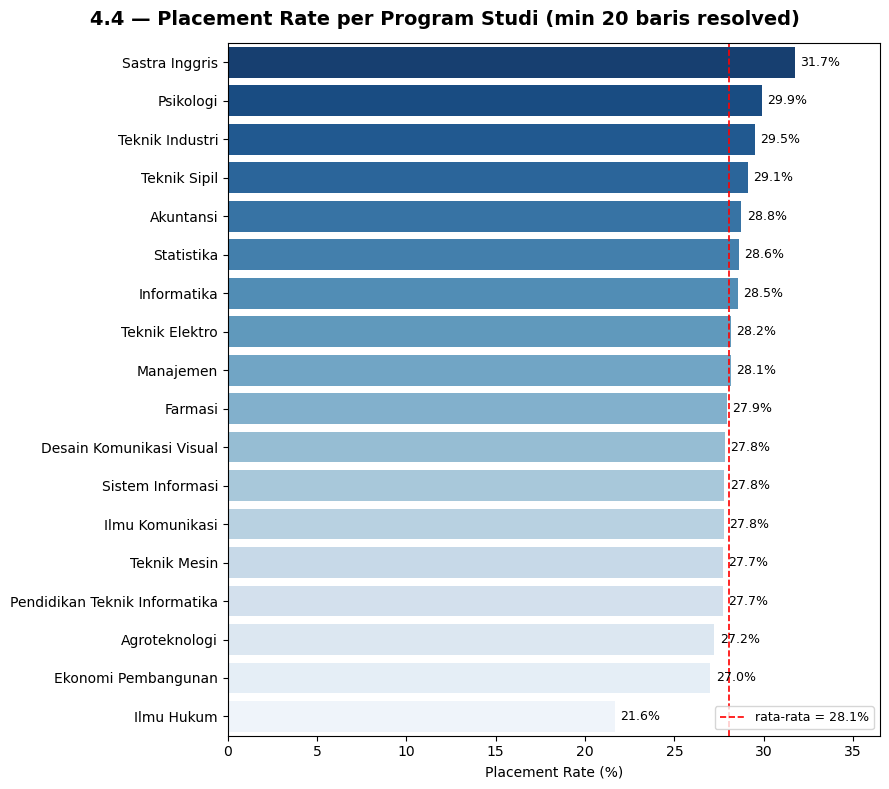

In [420]:
fig, ax = plt.subplots(figsize=(9, 8))
fig.suptitle(
    "4.4 — Placement Rate per Program Studi (min 20 baris resolved)",
    fontsize=14,
    fontweight="bold",
)

sns.barplot(
    x=prodi_rate_min20["placement_rate"].values,
    y=prodi_rate_min20.index,
    hue=prodi_rate_min20.index,
    palette="Blues_r",
    legend=False,
    ax=ax,
)
ax.axvline(
    prodi_rate_min20["placement_rate"].mean(),
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"rata-rata = {prodi_rate_min20['placement_rate'].mean():.1f}%",
)
ax.legend(loc="lower right", fontsize=9)

ax.set_xlabel("Placement Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, prodi_rate_min20["placement_rate"].max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

### 4.5 — Placement rate per internship_semester

In [421]:
semester_total = resolved_df.groupby("internship_semester").size()
semester_placement = (
    resolved_df[resolved_df["final_outcome"] == "Placement"]
    .groupby("internship_semester")
    .size()
)

semester_rate = pd.DataFrame(
    {
        "total_resolved": semester_total,
        "jumlah_placement": semester_placement,
    }
).fillna(0)
semester_rate["jumlah_placement"] = semester_rate["jumlah_placement"].astype(int)
semester_rate["placement_rate"] = (
    semester_rate["jumlah_placement"] / semester_rate["total_resolved"] * 100
)
semester_rate = semester_rate.sort_index()

print(semester_rate)

# Cek tren: korelasi sederhana semester vs rate
korelasi = semester_rate.reset_index()["internship_semester"].corr(
    semester_rate.reset_index()["placement_rate"]
)
print(f"\nKorelasi semester vs placement_rate: {korelasi:.2f}")

if korelasi > 0.3:
    tren = "NAIK -- semester lebih tinggi cenderung placement rate lebih baik"
elif korelasi < -0.3:
    tren = "TURUN -- semester lebih tinggi justru placement rate lebih rendah"
else:
    tren = "DATAR/TIDAK JELAS -- semester tidak menunjukkan pola kuat terhadap placement rate"

print(f">>> Kesimpulan tren: {tren}")

                     total_resolved  jumlah_placement  placement_rate
internship_semester                                                  
2                              4420              1266       28.642534
3                              5366              1593       29.686918
4                              3044               884       29.040736
5                              6250              1699       27.184000
6                              3094               841       27.181642
7                              4675              1310       28.021390
8                              1621               455       28.069093
9                              2272               597       26.276408
10                              511               154       30.136986
11                              532               156       29.323308

Korelasi semester vs placement_rate: -0.02
>>> Kesimpulan tren: DATAR/TIDAK JELAS -- semester tidak menunjukkan pola kuat terhadap placement rate


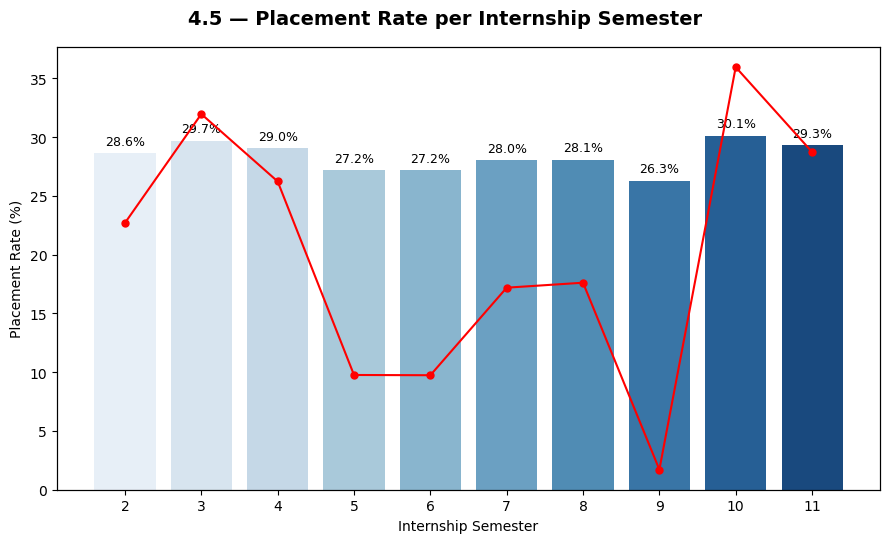

In [422]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.suptitle(
    "4.5 — Placement Rate per Internship Semester", fontsize=14, fontweight="bold"
)

sns.barplot(
    x=semester_rate.index.astype(str),
    y=semester_rate["placement_rate"],
    hue=semester_rate.index.astype(str),
    palette="Blues",
    legend=False,
    ax=ax,
)

ax2 = ax.twinx()
ax2.plot(
    range(len(semester_rate)),
    semester_rate["placement_rate"],
    color="red",
    marker="o",
    linewidth=1.5,
    markersize=5,
)
ax2.set_yticks([])

ax.set_xlabel("Internship Semester")
ax.set_ylabel("Placement Rate (%)")
ax.set_ylim(0, semester_rate["placement_rate"].max() * 1.25)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

### 4.6 — Placement rate per jenis_penempatan

In [423]:
jenis_total_resolved = resolved_df.groupby("jenis_penempatan").size()
jenis_placement_resolved = (
    resolved_df[resolved_df["final_outcome"] == "Placement"]
    .groupby("jenis_penempatan")
    .size()
)

jenis_rate = pd.DataFrame(
    {
        "total_resolved": jenis_total_resolved,
        "jumlah_placement": jenis_placement_resolved,
    }
).fillna(0)
jenis_rate["jumlah_placement"] = jenis_rate["jumlah_placement"].astype(int)
jenis_rate["placement_rate"] = (
    jenis_rate["jumlah_placement"] / jenis_rate["total_resolved"] * 100
)
jenis_rate = jenis_rate.sort_values("placement_rate", ascending=False)

print(jenis_rate)

tertinggi = jenis_rate.index[0]
terendah = jenis_rate.index[-1]
print(
    f"\n>>> Rate TERTINGGI: {tertinggi} ({jenis_rate['placement_rate'].iloc[0]:.1f}%)"
)
print(f">>> Rate TERENDAH : {terendah} ({jenis_rate['placement_rate'].iloc[-1]:.1f}%)")

if "Full-time" in jenis_rate.index:
    rate_fulltime = jenis_rate.loc["Full-time", "placement_rate"]
    rate_lain_max = jenis_rate.drop("Full-time")["placement_rate"].max()
    if rate_fulltime < rate_lain_max:
        print(
            f"\n>>> HIPOTESIS TERKONFIRMASI: Full-time ({rate_fulltime:.1f}%) lebih selektif"
        )
        print(
            f"    -- rate-nya lebih rendah dibanding skema lain (maks {rate_lain_max:.1f}%)."
        )
    else:
        print(
            f"\n>>> HIPOTESIS TIDAK TERKONFIRMASI: Full-time ({rate_fulltime:.1f}%) BUKAN yang terendah."
        )

                  total_resolved  jumlah_placement  placement_rate
jenis_penempatan                                                  
Magang                     19227              5431       28.246736
Part-time                   7806              2193       28.093774
Full-time                   4752              1331       28.009259

>>> Rate TERTINGGI: Magang (28.2%)
>>> Rate TERENDAH : Full-time (28.0%)

>>> HIPOTESIS TERKONFIRMASI: Full-time (28.0%) lebih selektif
    -- rate-nya lebih rendah dibanding skema lain (maks 28.2%).


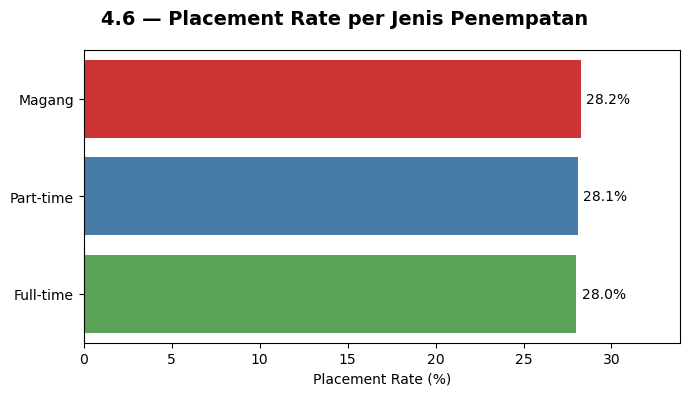

In [424]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.suptitle(
    "4.6 — Placement Rate per Jenis Penempatan", fontsize=14, fontweight="bold"
)

sns.barplot(
    x=jenis_rate["placement_rate"].values,
    y=jenis_rate.index,
    hue=jenis_rate.index,
    palette="Set1",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Placement Rate (%)")
ax.set_ylabel("")
ax.set_xlim(0, jenis_rate["placement_rate"].max() * 1.2)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        ax.bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=10,
        )

plt.tight_layout()
plt.show()

### 4.7 — Placement rate per renumerasi (3 tingkat kompensasi) [+][✓data]

In [425]:
def kategorikan_renumerasi(nilai):
    if "Rp" in nilai:
        return "Berbayar Nominal"
    elif nilai == "Non-Paid":
        return "Non-Paid"
    else:
        return "Transport Saja"


talent_request["kategori_renumerasi"] = talent_request["renumerasi"].apply(
    kategorikan_renumerasi
)

# Join 2 tahap: talent_request -> tracking_company -> tracking_student
tc_with_renumerasi = tracking_company.merge(
    talent_request[["id_talent_req", "kategori_renumerasi"]],
    on="id_talent_req",
    how="left",
)
ts_with_renumerasi = ts_with_send.merge(
    tc_with_renumerasi[["id_tracking_company", "kategori_renumerasi"]],
    on="id_tracking_company",
    how="left",
)

n_unmatched = ts_with_renumerasi["kategori_renumerasi"].isna().sum()
print(f"Baris unmatched (harus 0): {n_unmatched:,}\n")

komposisi = ts_with_renumerasi["kategori_renumerasi"].value_counts(normalize=True) * 100
print("Komposisi kategori renumerasi:")
print(komposisi.round(1))

Baris unmatched (harus 0): 0

Komposisi kategori renumerasi:
kategori_renumerasi
Berbayar Nominal    78.6
Transport Saja      12.6
Non-Paid             8.8
Name: proportion, dtype: float64


In [426]:
resolved_renumerasi = ts_with_renumerasi[
    ~ts_with_renumerasi["final_outcome"].isin(masih_aktif)
].copy()

kategori_total = resolved_renumerasi.groupby("kategori_renumerasi").size()
kategori_placement = (
    resolved_renumerasi[resolved_renumerasi["final_outcome"] == "Placement"]
    .groupby("kategori_renumerasi")
    .size()
)
kategori_ghosting = (
    resolved_renumerasi[resolved_renumerasi["final_outcome"] == "Ghosting"]
    .groupby("kategori_renumerasi")
    .size()
)

renumerasi_summary = pd.DataFrame(
    {
        "total_resolved": kategori_total,
        "jumlah_placement": kategori_placement,
        "jumlah_ghosting": kategori_ghosting,
    }
).fillna(0)
renumerasi_summary[["jumlah_placement", "jumlah_ghosting"]] = renumerasi_summary[
    ["jumlah_placement", "jumlah_ghosting"]
].astype(int)
renumerasi_summary["placement_rate"] = (
    renumerasi_summary["jumlah_placement"] / renumerasi_summary["total_resolved"] * 100
)
renumerasi_summary["ghosting_rate"] = (
    renumerasi_summary["jumlah_ghosting"] / renumerasi_summary["total_resolved"] * 100
)

urutan = ["Berbayar Nominal", "Transport Saja", "Non-Paid"]
renumerasi_summary = renumerasi_summary.reindex(urutan)

print("Placement & Ghosting rate per kategori kompensasi:")
print(renumerasi_summary)

rate_berbayar = renumerasi_summary.loc["Berbayar Nominal", "placement_rate"]
rate_nonpaid = renumerasi_summary.loc["Non-Paid", "placement_rate"]
ghost_berbayar = renumerasi_summary.loc["Berbayar Nominal", "ghosting_rate"]
ghost_nonpaid = renumerasi_summary.loc["Non-Paid", "ghosting_rate"]

print(
    f"\n>>> Placement rate -- Berbayar Nominal ({rate_berbayar:.1f}%) vs Non-Paid ({rate_nonpaid:.1f}%)"
)
print(
    f">>> Ghosting rate  -- Berbayar Nominal ({ghost_berbayar:.1f}%) vs Non-Paid ({ghost_nonpaid:.1f}%)"
)

if rate_berbayar > rate_nonpaid and ghost_berbayar < ghost_nonpaid:
    print(
        "\n>>> HIPOTESIS TERKONFIRMASI: posisi berbayar nominal lebih sukses DAN lebih jarang ghosting."
    )
else:
    print(
        "\n>>> HIPOTESIS TIDAK SEPENUHNYA TERKONFIRMASI -- lihat detail angka di atas."
    )

Placement & Ghosting rate per kategori kompensasi:
                     total_resolved  jumlah_placement  jumlah_ghosting  placement_rate  ghosting_rate
kategori_renumerasi                                                                                  
Berbayar Nominal              24953              6981             8708       27.976596      34.897608
Transport Saja                 4038              1187             1394       29.395740      34.522041
Non-Paid                       2794               787              992       28.167502      35.504653

>>> Placement rate -- Berbayar Nominal (28.0%) vs Non-Paid (28.2%)
>>> Ghosting rate  -- Berbayar Nominal (34.9%) vs Non-Paid (35.5%)

>>> HIPOTESIS TIDAK SEPENUHNYA TERKONFIRMASI -- lihat detail angka di atas.


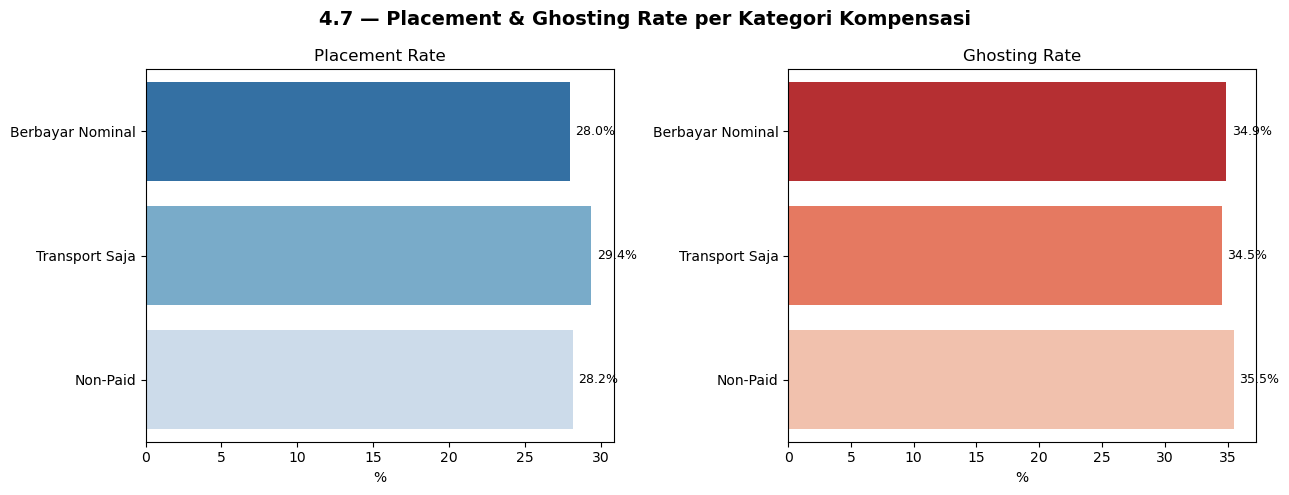

In [427]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "4.7 — Placement & Ghosting Rate per Kategori Kompensasi",
    fontsize=14,
    fontweight="bold",
)

plot_df = renumerasi_summary.reset_index().rename(
    columns={"index": "kategori_renumerasi"}
)

sns.barplot(
    data=plot_df,
    x="placement_rate",
    y="kategori_renumerasi",
    hue="kategori_renumerasi",
    palette="Blues_r",
    legend=False,
    ax=axes[0],
    order=urutan,
)
axes[0].set_title("Placement Rate")
axes[0].set_xlabel("%")
axes[0].set_ylabel("")
for container in axes[0].containers:
    if hasattr(container, "datavalues"):
        axes[0].bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

sns.barplot(
    data=plot_df,
    x="ghosting_rate",
    y="kategori_renumerasi",
    hue="kategori_renumerasi",
    palette="Reds_r",
    legend=False,
    ax=axes[1],
    order=urutan,
)
axes[1].set_title("Ghosting Rate")
axes[1].set_xlabel("%")
axes[1].set_ylabel("")
for container in axes[1].containers:
    if hasattr(container, "datavalues"):
        axes[1].bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

### 4.8 — Acceptance rate per company + tipe/skala

In [428]:
ts_with_company = ts_with_send.merge(
    tracking_company[["id_tracking_company", "id_company"]],
    on="id_tracking_company",
    how="left",
).merge(
    company[["id_company", "company_type", "skala_perusahaan", "company_name"]],
    on="id_company",
    how="left",
)

resolved_company = ts_with_company[
    ~ts_with_company["final_outcome"].isin(masih_aktif)
].copy()

print(f"Baris resolved dengan info company: {len(resolved_company):,}")
print(f"Unmatched (harus 0): {ts_with_company['company_type'].isna().sum()}\n")

# -- Ranking per company (volume >= 20) --
company_total_r = resolved_company.groupby("company_name").size()
company_placement_r = (
    resolved_company[resolved_company["final_outcome"] == "Placement"]
    .groupby("company_name")
    .size()
)

company_accept = pd.DataFrame(
    {
        "total_resolved": company_total_r,
        "jumlah_placement": company_placement_r,
    }
).fillna(0)
company_accept["jumlah_placement"] = company_accept["jumlah_placement"].astype(int)
company_accept["acceptance_rate"] = (
    company_accept["jumlah_placement"] / company_accept["total_resolved"] * 100
)

company_accept_min20 = company_accept[
    company_accept["total_resolved"] >= 20
].sort_values("acceptance_rate", ascending=False)
print(f"Jumlah company dengan volume >= 20: {len(company_accept_min20)}\n")
print("Top 10 company acceptance rate tertinggi:")
print(company_accept_min20.head(10))
print("\nBottom 10 company acceptance rate terendah:")
print(company_accept_min20.tail(10))

Baris resolved dengan info company: 31,785
Unmatched (harus 0): 0

Jumlah company dengan volume >= 20: 624

Top 10 company acceptance rate tertinggi:
                       total_resolved  jumlah_placement  acceptance_rate
company_name                                                            
PT Bangkit Bersama                 23                12        52.173913
PT Nusa Digital                    24                12        50.000000
PT Abadi Teknologi                 20                10        50.000000
PT Makmur Kreatif                  22                11        50.000000
CV Sinergi Karya                   27                13        48.148148
PT Bina Informatika                23                11        47.826087
PT Digital Bangsa                  23                11        47.826087
CV Makmur Informatika              21                10        47.619048
PT Makmur Systems                  21                10        47.619048
PT Prima Digital                   28          

In [429]:
def rate_per_grup(df, kolom_grup):
    total = df.groupby(kolom_grup).size()
    placement = df[df["final_outcome"] == "Placement"].groupby(kolom_grup).size()
    hasil = pd.DataFrame(
        {"total_resolved": total, "jumlah_placement": placement}
    ).fillna(0)
    hasil["jumlah_placement"] = hasil["jumlah_placement"].astype(int)
    hasil["acceptance_rate"] = hasil["jumlah_placement"] / hasil["total_resolved"] * 100
    return hasil.sort_values("acceptance_rate", ascending=False)


rate_by_type = rate_per_grup(resolved_company, "company_type")
rate_by_skala = rate_per_grup(resolved_company, "skala_perusahaan")

print("Acceptance rate per company_type:")
print(rate_by_type)
print("\nAcceptance rate per skala_perusahaan:")
print(rate_by_skala)

Acceptance rate per company_type:
              total_resolved  jumlah_placement  acceptance_rate
company_type                                                   
NGO                     1815               530        29.201102
Startup                10547              2998        28.425145
BUMN                    4079              1155        28.315764
Corporate               8115              2282        28.120764
UMKM                    5466              1520        27.808269
Pemerintah              1763               470        26.659104

Acceptance rate per skala_perusahaan:
                  total_resolved  jumlah_placement  acceptance_rate
skala_perusahaan                                                   
Lokal                      13912              3946        28.364002
Nasional                   12659              3551        28.051189
Multinasional               5214              1458        27.963176


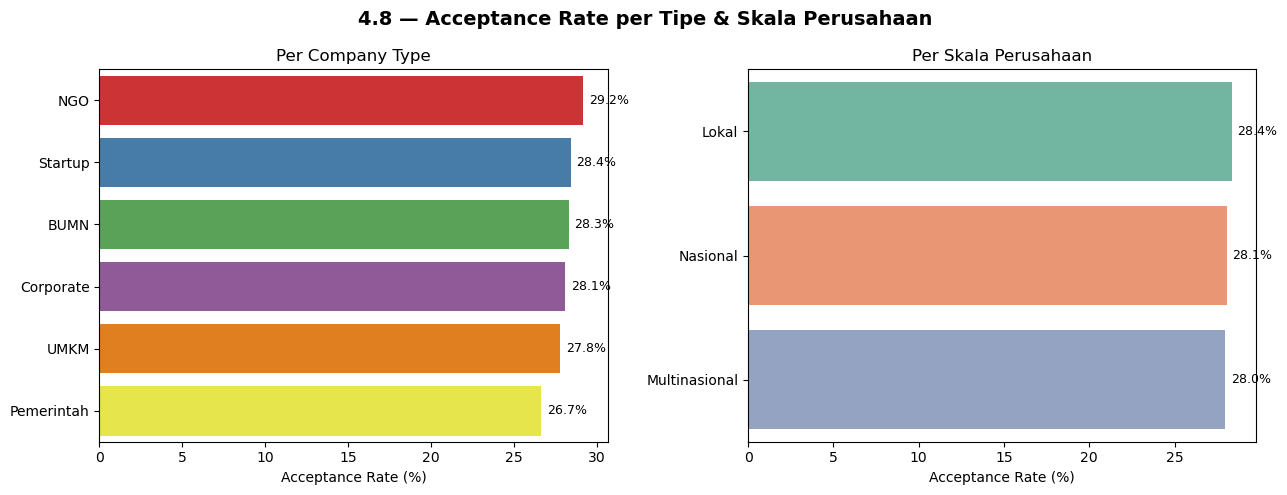

In [430]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "4.8 — Acceptance Rate per Tipe & Skala Perusahaan", fontsize=14, fontweight="bold"
)

sns.barplot(
    x=rate_by_type["acceptance_rate"],
    y=rate_by_type.index,
    hue=rate_by_type.index,
    palette="Set1",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Per Company Type")
axes[0].set_xlabel("Acceptance Rate (%)")
axes[0].set_ylabel("")
for container in axes[0].containers:
    if hasattr(container, "datavalues"):
        axes[0].bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

sns.barplot(
    x=rate_by_skala["acceptance_rate"],
    y=rate_by_skala.index,
    hue=rate_by_skala.index,
    palette="Set2",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Per Skala Perusahaan")
axes[1].set_xlabel("Acceptance Rate (%)")
axes[1].set_ylabel("")
for container in axes[1].containers:
    if hasattr(container, "datavalues"):
        axes[1].bar_label(
            container,
            labels=[f"{v:.1f}%" for v in container.datavalues],
            padding=4,
            fontsize=9,
        )

plt.tight_layout()
plt.show()

### 4.9 — Rekap tabel BT-07 eksplisit

In [431]:
ts_master = (
    ts_with_send.merge(
        tracking_company[["id_tracking_company", "id_company"]],
        on="id_tracking_company",
        how="left",
    )
    .merge(company[["id_company", "company_name"]], on="id_company", how="left")
    .merge(student_all[["NIM", "program_studi"]], on="NIM", how="left")
)


def outcome_kategori(val):
    if val == "Placement":
        return "Placement"
    elif str(val).startswith("Rejection"):
        return "Rejected"
    elif val == "Ghosting":
        return "Ghosting"
    else:
        return "Masih Aktif"


ts_master["outcome_kategori"] = ts_master["final_outcome"].apply(outcome_kategori)

print(f"Total baris master: {len(ts_master):,} (harus 41.600)")
print(
    f"Unmatched company: {ts_master['company_name'].isna().sum()}, unmatched prodi: {ts_master['program_studi'].isna().sum()}\n"
)
print("Cek kategori outcome (harus jumlah = 41.600):")
print(ts_master["outcome_kategori"].value_counts())

Total baris master: 41,600 (harus 41.600)
Unmatched company: 0, unmatched prodi: 0

Cek kategori outcome (harus jumlah = 41.600):
outcome_kategori
Rejected       11736
Ghosting       11094
Masih Aktif     9815
Placement       8955
Name: count, dtype: int64


In [432]:
def buat_rekap(df, dimensi, top_n=None):
    pivot = df.groupby(dimensi)["outcome_kategori"].value_counts().unstack(fill_value=0)
    kolom_order = ["Placement", "Rejected", "Ghosting", "Masih Aktif"]
    pivot = pivot.reindex(columns=kolom_order, fill_value=0)
    pivot["Dikirim"] = pivot[kolom_order].sum(axis=1)
    pivot = pivot[["Dikirim"] + kolom_order]
    pivot = pivot.sort_values("Dikirim", ascending=False)

    cek_total = pivot["Dikirim"].sum()
    konsisten = cek_total == len(df)

    if top_n:
        pivot = pivot.head(top_n)
    return pivot, cek_total, konsisten


print("=== Rekap per Company (Top 15 by volume) ===")
rekap_company, total_c, ok_c = buat_rekap(ts_master, "company_name", top_n=15)
print(rekap_company)
print(f"Total Dikirim (semua company): {total_c:,} -- konsisten: {ok_c}\n")

print("=== Rekap per Internship Semester (asumsi = 'periode akademik') ===")
rekap_semester, total_s, ok_s = buat_rekap(ts_master, "internship_semester")
print(rekap_semester)
print(f"Total Dikirim (semua semester): {total_s:,} -- konsisten: {ok_s}\n")

print("=== Rekap per Program Studi ===")
rekap_prodi, total_p, ok_p = buat_rekap(ts_master, "program_studi")
print(rekap_prodi)
print(f"Total Dikirim (semua prodi): {total_p:,} -- konsisten: {ok_p}\n")

print("=== Rekap per Jenis Penempatan ===")
rekap_jenis, total_j, ok_j = buat_rekap(ts_master, "jenis_penempatan")
print(rekap_jenis)
print(f"Total Dikirim (semua jenis): {total_j:,} -- konsisten: {ok_j}\n")

print(
    f">>> Semua 4 dimensi konsisten (total = 41.600)? {all([ok_c, ok_s, ok_p, ok_j])}"
)

=== Rekap per Company (Top 15 by volume) ===
outcome_kategori       Dikirim  Placement  Rejected  Ghosting  Masih Aktif
company_name                                                              
PT Bumi Informatika        104         19        25        30           30
CV Mega Sentosa            103         26        29        27           21
CV Sentosa Makmur          103         27        24        33           19
CV Cakra Indonesia         103         23        29        32           19
PT Esa Mandiri             102         31        30        22           19
CV Digital Teknologi        96         24        24        26           22
CV Mandiri Pratama          94         24        27        27           16
PT Bangkit Bangsa           92         24        23        32           13
PT Digital Mandiri          91         14        25        28           24
CV Daya Data                91         23        28        21           19
CV Perkasa Utama            91         18        28    

### 4.10 — Multivariat: apakah gap prodi bertahan setelah dikontrol [+]

In [433]:
resolved_strat = ts_master.merge(
    company[["company_name", "company_type", "skala_perusahaan"]],
    on="company_name",
    how="left",
)
resolved_strat = resolved_strat[
    resolved_strat["outcome_kategori"] != "Masih Aktif"
].copy()
resolved_strat["is_placement"] = resolved_strat["outcome_kategori"] == "Placement"

# Placement rate prodi TANPA kontrol (baseline dari 4.4)
prodi_baseline = (
    resolved_strat.groupby("program_studi")["is_placement"].mean() * 100
).sort_values(ascending=False)

print("Placement rate per prodi TANPA kontrol (baseline, sesuai 4.4):")
print(prodi_baseline.head(5), "...\n")

# Placement rate prodi DI DALAM tiap company_type (stratifikasi)
heatmap_data = (
    resolved_strat.groupby(["program_studi", "company_type"])["is_placement"].mean()
    * 100
).unstack()

# filter prodi dengan volume memadai
prodi_volume = resolved_strat.groupby("program_studi").size()
prodi_valid = prodi_volume[prodi_volume >= 100].index
heatmap_data_filtered = heatmap_data.loc[heatmap_data.index.isin(prodi_valid)]

print("Placement rate per prodi x company_type (stratifikasi):")
print(heatmap_data_filtered.round(1))

Placement rate per prodi TANPA kontrol (baseline, sesuai 4.4):
program_studi
Sastra Inggris     31.746032
Psikologi          29.891304
Teknik Industri    29.498681
Teknik Sipil       29.118329
Akuntansi          28.753351
Name: is_placement, dtype: float64 ...

Placement rate per prodi x company_type (stratifikasi):
company_type                   BUMN  Corporate   NGO  Pemerintah  Startup  UMKM
program_studi                                                                  
Agroteknologi                  23.2       26.9  35.8        13.0     26.0  34.3
Akuntansi                      32.2       25.5  23.4        30.8     31.7  26.6
Desain Komunikasi Visual       25.6       27.6  30.2        28.7     29.0  26.3
Ekonomi Pembangunan            25.0       26.6  31.4        24.3     27.7  27.6
Farmasi                        30.3       24.4  26.0        19.0     30.6  29.0
Ilmu Hukum                     21.6       22.7  33.3        42.9     11.7  28.0
Ilmu Komunikasi                27.7       

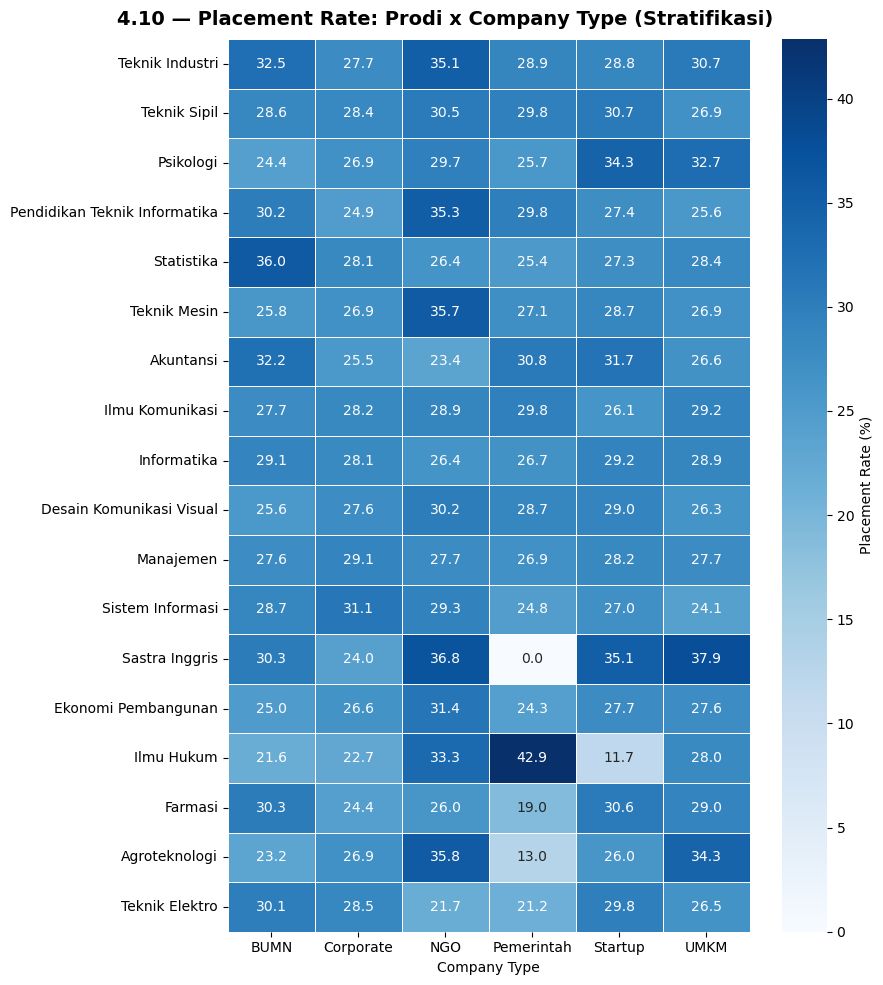

In [434]:
fig, ax = plt.subplots(figsize=(9, 10))
fig.suptitle(
    "4.10 — Placement Rate: Prodi x Company Type (Stratifikasi)",
    fontsize=14,
    fontweight="bold",
)

order_prodi = heatmap_data_filtered.mean(axis=1).sort_values(ascending=False).index
heatmap_ordered = heatmap_data_filtered.loc[order_prodi]

sns.heatmap(
    heatmap_ordered,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Placement Rate (%)"},
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_xlabel("Company Type")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [435]:
gap_sebelum = prodi_baseline.max() - prodi_baseline.min()

gap_per_tipe = heatmap_data_filtered.max() - heatmap_data_filtered.min()
gap_sesudah_rata2 = gap_per_tipe.mean()

print(
    f"Gap prodi SEBELUM kontrol (baseline, semua tipe digabung): {gap_sebelum:.1f} poin persentase"
)
print(f"\nGap prodi SESUDAH kontrol (di dalam tiap company_type):")
print(gap_per_tipe.round(1))
print(f"\nRata-rata gap sesudah kontrol: {gap_sesudah_rata2:.1f} poin persentase")

if gap_sesudah_rata2 < gap_sebelum * 0.5:
    print(
        f"\n>>> GAP MENYUSUT DRASTIS setelah dikontrol -- sebagian besar 'keunggulan' prodi"
    )
    print(
        f"    kemungkinan besar efek PILIHAN PERUSAHAAN, bukan keunggulan intrinsik prodi."
    )
elif gap_sesudah_rata2 < gap_sebelum * 0.8:
    print(
        f"\n>>> Gap MENYUSUT SEBAGIAN -- ada campuran efek pilihan perusahaan dan faktor lain."
    )
else:
    print(
        f"\n>>> Gap TETAP BESAR meski dikontrol -- kemungkinan ada faktor intrinsik prodi"
    )
    print(
        f"    (skill, minat, dll) yang nyata, bukan cuma soal ke perusahaan mana mereka melamar."
    )

Gap prodi SEBELUM kontrol (baseline, semua tipe digabung): 10.1 poin persentase

Gap prodi SESUDAH kontrol (di dalam tiap company_type):
company_type
BUMN          14.3
Corporate      8.3
NGO           15.1
Pemerintah    42.9
Startup       23.4
UMKM          13.8
dtype: float64

Rata-rata gap sesudah kontrol: 19.6 poin persentase

>>> Gap TETAP BESAR meski dikontrol -- kemungkinan ada faktor intrinsik prodi
    (skill, minat, dll) yang nyata, bukan cuma soal ke perusahaan mana mereka melamar.


### 4.11 — Velocity / time-to-placement [+]

In [436]:
placement_df = ts_master[ts_master["outcome_kategori"] == "Placement"].merge(
    company[["company_name", "company_type", "skala_perusahaan"]],
    on="company_name",
    how="left",
)

print(f"Total baris Placement: {len(placement_df):,}\n")
print(
    f"Durasi keseluruhan (median): {placement_df['hari_terlewat'].median():.0f} hari\n"
)


def rekap_durasi(df, kolom):
    hasil = (
        df.groupby(kolom)["hari_terlewat"]
        .agg(["size", "median", "mean"])
        .sort_values("median")
    )
    hasil.columns = ["n", "median_hari", "mean_hari"]
    return hasil


print("Median time-to-placement per company_type:")
print(rekap_durasi(placement_df, "company_type"))

print("\nMedian time-to-placement per skala_perusahaan:")
print(rekap_durasi(placement_df, "skala_perusahaan"))

print("\nMedian time-to-placement per jenis_penempatan:")
print(rekap_durasi(placement_df, "jenis_penempatan"))

print(
    """
CATATAN ASUMSI (konsisten dengan 3.4 & 3.7): last_update dipakai sebagai
PROXY tanggal placement -- data tidak punya timestamp keputusan terpisah.
Ini "hari sejak dikirim sampai update terakhir tercatat", BUKAN durasi
keputusan murni. Disajikan sebagai ESTIMASI waktu-ke-placement, bukan
durasi presisi.
"""
)

Total baris Placement: 8,955

Durasi keseluruhan (median): 58 hari

Median time-to-placement per company_type:
                 n  median_hari  mean_hari
company_type                              
BUMN          1155         56.0  56.650216
NGO            530         57.0  56.941509
Pemerintah     470         57.0  56.819149
Corporate     2282         58.0  57.448729
Startup       2998         58.0  57.917612
UMKM          1520         58.0  57.302632

Median time-to-placement per skala_perusahaan:
                     n  median_hari  mean_hari
skala_perusahaan                              
Nasional          3551         56.0  56.533371
Multinasional     1458         58.0  57.490398
Lokal             3946         59.0  58.180182

Median time-to-placement per jenis_penempatan:
                     n  median_hari  mean_hari
jenis_penempatan                              
Part-time         2193         57.0  57.255358
Magang            5431         58.0  57.391088
Full-time         1331    

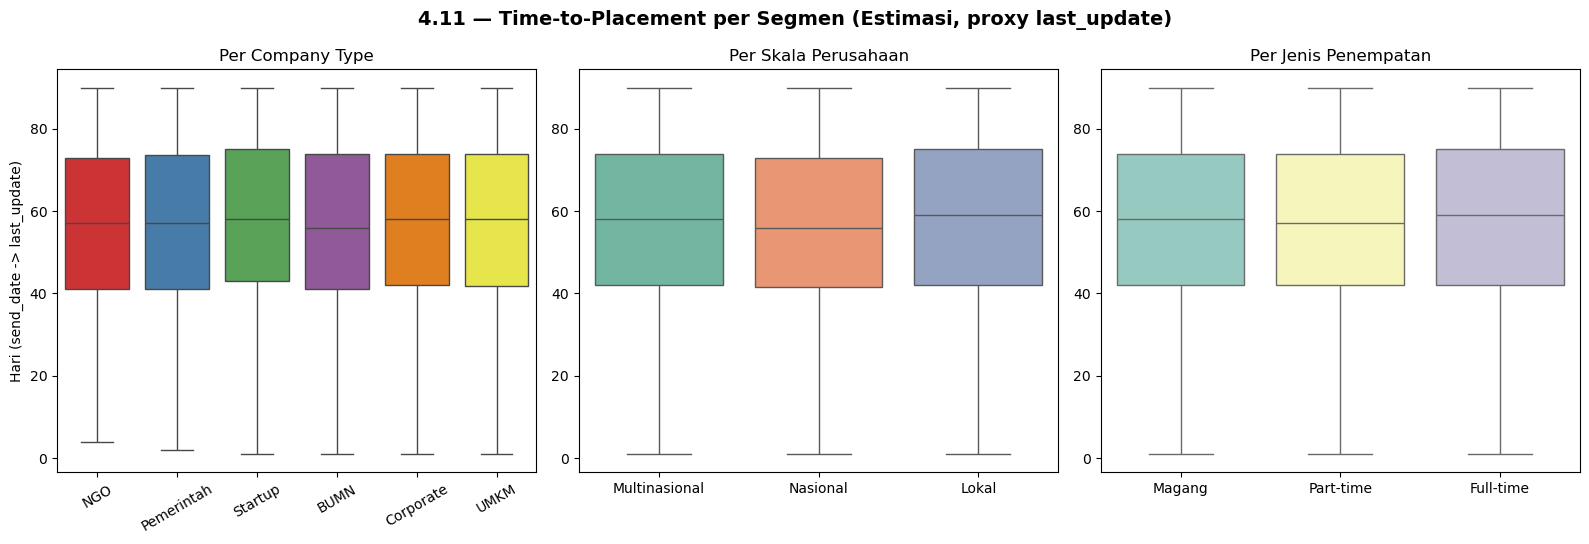

In [437]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(
    "4.11 — Time-to-Placement per Segmen (Estimasi, proxy last_update)",
    fontsize=14,
    fontweight="bold",
)

sns.boxplot(
    data=placement_df,
    x="company_type",
    y="hari_terlewat",
    hue="company_type",
    palette="Set1",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Per Company Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Hari (send_date -> last_update)")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(
    data=placement_df,
    x="skala_perusahaan",
    y="hari_terlewat",
    hue="skala_perusahaan",
    palette="Set2",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Per Skala Perusahaan")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.boxplot(
    data=placement_df,
    x="jenis_penempatan",
    y="hari_terlewat",
    hue="jenis_penempatan",
    palette="Set3",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Per Jenis Penempatan")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

In [438]:
segmen_all = []
for kolom, nama in [
    ("company_type", "Company Type"),
    ("skala_perusahaan", "Skala"),
    ("jenis_penempatan", "Jenis Penempatan"),
]:
    rekap = rekap_durasi(placement_df, kolom)
    tercepat = rekap["median_hari"].idxmin()
    terlambat = rekap["median_hari"].idxmax()
    segmen_all.append(
        (
            nama,
            tercepat,
            rekap["median_hari"].min(),
            terlambat,
            rekap["median_hari"].max(),
        )
    )

print("Ringkasan tercepat vs berlarut per dimensi:")
for nama, cepat, med_cepat, lambat, med_lambat in segmen_all:
    print(
        f"   {nama:18s}: tercepat = {cepat} ({med_cepat:.0f} hari) | terlambat = {lambat} ({med_lambat:.0f} hari) | selisih = {med_lambat - med_cepat:.0f} hari"
    )

Ringkasan tercepat vs berlarut per dimensi:
   Company Type      : tercepat = BUMN (56 hari) | terlambat = Corporate (58 hari) | selisih = 2 hari
   Skala             : tercepat = Nasional (56 hari) | terlambat = Lokal (59 hari) | selisih = 3 hari
   Jenis Penempatan  : tercepat = Part-time (57 hari) | terlambat = Full-time (59 hari) | selisih = 2 hari


### 4.12 — Tren placement rate per bulan-kuartal

In [439]:
resolved_time = ts_master[ts_master["outcome_kategori"] != "Masih Aktif"].copy()
resolved_time["last_update"] = pd.to_datetime(resolved_time["last_update"])

tren_bulanan = (
    resolved_time.set_index("last_update")
    .resample("ME")
    .agg(
        total_resolved=("outcome_kategori", "size"),
        jumlah_placement=("outcome_kategori", lambda x: (x == "Placement").sum()),
    )
)
tren_bulanan["placement_rate"] = (
    tren_bulanan["jumlah_placement"] / tren_bulanan["total_resolved"] * 100
)

tren_kuartalan = (
    resolved_time.set_index("last_update")
    .resample("QE")
    .agg(
        total_resolved=("outcome_kategori", "size"),
        jumlah_placement=("outcome_kategori", lambda x: (x == "Placement").sum()),
    )
)
tren_kuartalan["placement_rate"] = (
    tren_kuartalan["jumlah_placement"] / tren_kuartalan["total_resolved"] * 100
)

print("Tren bulanan (rate & volume):")
print(tren_bulanan)

print("\nTren kuartalan:")
print(tren_kuartalan)

print(
    f"""
WASPADA BIAS PERIODE AKHIR: bulan/kuartal TERAKHIR dalam data cenderung
punya total_resolved lebih kecil, membuat rate SANGAT VOLATIL ke arah
mana pun (naik atau turun) -- bukan otomatis rendah. Contoh nyata di
data ini: April-Mei 2025 justru melonjak ke 41,7%/36,2% (basis cuma
535/69 baris) -- kemungkinan besar noise sampel kecil, BUKAN tren
perbaikan sungguhan. Jangan jadikan 1-2 bulan terakhir sebagai basis
kesimpulan tren; gunakan kuartal terakhir yang volumenya masih solid
(2025-Q1, n=4.237) untuk klaim tren yang valid.
"""
)

volume_threshold = tren_bulanan["total_resolved"].median() * 0.5
tren_bulanan["volume_rendah"] = tren_bulanan["total_resolved"] < volume_threshold
print(f"\nBulan dengan volume di bawah setengah median (perlu hati-hati interpretasi):")
print(tren_bulanan[tren_bulanan["volume_rendah"]][["total_resolved", "placement_rate"]])

Tren bulanan (rate & volume):
             total_resolved  jumlah_placement  placement_rate
last_update                                                  
2023-02-28               16                 1        6.250000
2023-03-31              239                38       15.899582
2023-04-30              689               154       22.351234
2023-05-31             1012               293       28.952569
2023-06-30             1023               303       29.618768
2023-07-31              993               251       25.276939
2023-08-31             1140               308       27.017544
2023-09-30             1212               345       28.465347
2023-10-31             1469               394       26.820967
2023-11-30             1415               423       29.893993
2023-12-31             1487               400       26.899798
2024-01-31             1510               416       27.549669
2024-02-29             1350               403       29.851852
2024-03-31             1376             

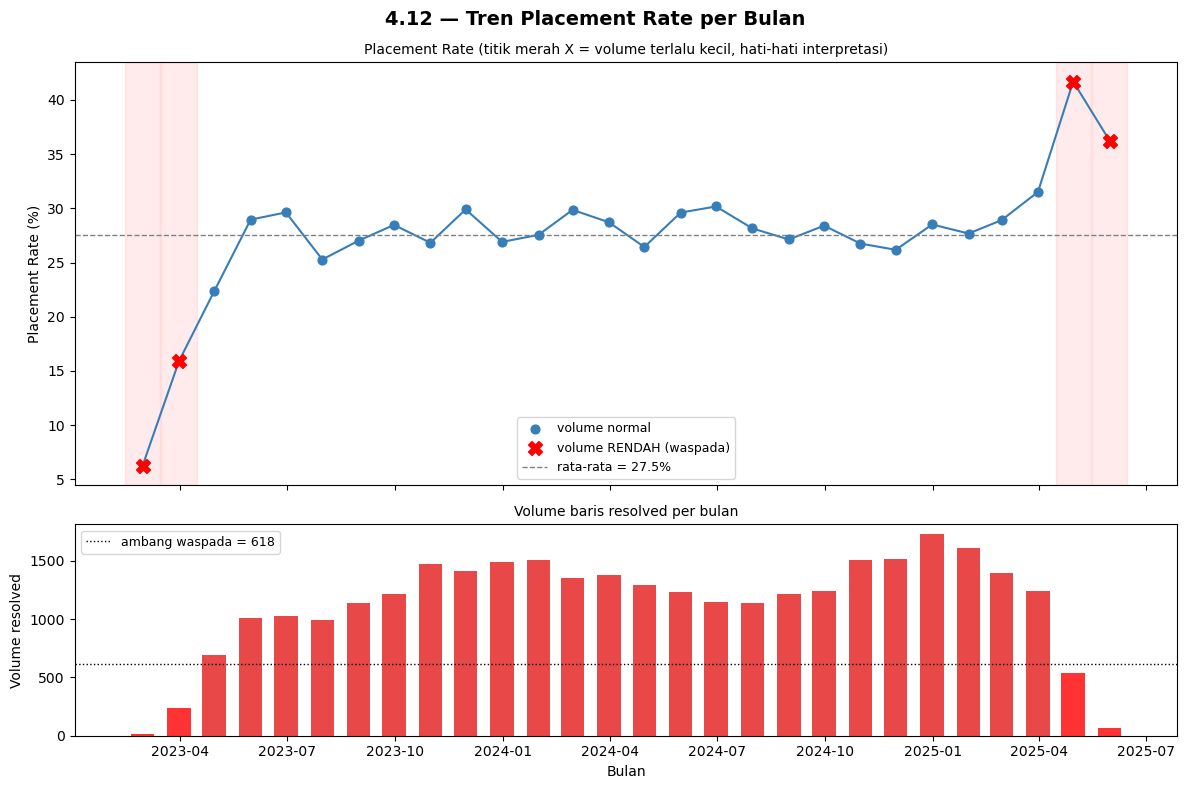

In [440]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
fig.suptitle("4.12 — Tren Placement Rate per Bulan", fontsize=14, fontweight="bold")

ax1.plot(
    tren_bulanan.index,
    tren_bulanan["placement_rate"],
    color=sns.color_palette("Set1")[1],
    linewidth=1.5,
    zorder=2,
)

normal_mask = ~tren_bulanan["volume_rendah"]
ax1.scatter(
    tren_bulanan.index[normal_mask],
    tren_bulanan["placement_rate"][normal_mask],
    color=sns.color_palette("Set1")[1],
    marker="o",
    s=40,
    zorder=3,
    label="volume normal",
)

rendah_mask = tren_bulanan["volume_rendah"]
ax1.scatter(
    tren_bulanan.index[rendah_mask],
    tren_bulanan["placement_rate"][rendah_mask],
    color="red",
    marker="X",
    s=100,
    zorder=4,
    label="volume RENDAH (waspada)",
)

for tgl in tren_bulanan.index[rendah_mask]:
    ax1.axvspan(
        tgl - pd.Timedelta(days=15),
        tgl + pd.Timedelta(days=15),
        color="red",
        alpha=0.08,
    )

ax1.axhline(
    tren_bulanan["placement_rate"].mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"rata-rata = {tren_bulanan['placement_rate'].mean():.1f}%",
)
ax1.set_ylabel("Placement Rate (%)")
ax1.legend(fontsize=9)
ax1.set_title(
    "Placement Rate (titik merah X = volume terlalu kecil, hati-hati interpretasi)",
    fontsize=10,
)

colors_bar = [
    "red" if flag else sns.color_palette("Set1")[0]
    for flag in tren_bulanan["volume_rendah"]
]
ax2.bar(
    tren_bulanan.index,
    tren_bulanan["total_resolved"],
    width=20,
    color=colors_bar,
    alpha=0.8,
)
ax2.axhline(
    volume_threshold,
    color="black",
    linestyle=":",
    linewidth=1,
    label=f"ambang waspada = {volume_threshold:.0f}",
)
ax2.set_ylabel("Volume resolved")
ax2.set_xlabel("Bulan")
ax2.legend(fontsize=9)
ax2.set_title("Volume baris resolved per bulan", fontsize=10)

plt.tight_layout()
plt.show()

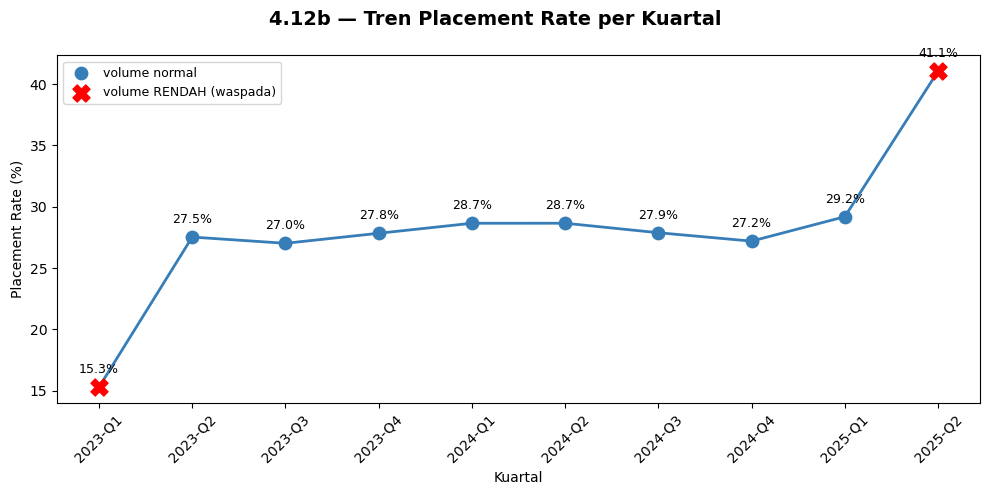

In [441]:
kuartal_threshold = tren_kuartalan["total_resolved"].median() * 0.5
tren_kuartalan["volume_rendah"] = tren_kuartalan["total_resolved"] < kuartal_threshold

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("4.12b — Tren Placement Rate per Kuartal", fontsize=14, fontweight="bold")

kuartal_label = [f"{d.year}-Q{d.quarter}" for d in tren_kuartalan.index]
ax.plot(
    range(len(kuartal_label)),
    tren_kuartalan["placement_rate"],
    color=sns.color_palette("Set1")[1],
    linewidth=2,
    zorder=2,
)

normal_mask_q = ~tren_kuartalan["volume_rendah"]
rendah_mask_q = tren_kuartalan["volume_rendah"]

ax.scatter(
    [i for i, m in enumerate(normal_mask_q) if m],
    tren_kuartalan["placement_rate"][normal_mask_q.values],
    color=sns.color_palette("Set1")[1],
    marker="o",
    s=80,
    zorder=3,
    label="volume normal",
)
ax.scatter(
    [i for i, m in enumerate(rendah_mask_q) if m],
    tren_kuartalan["placement_rate"][rendah_mask_q.values],
    color="red",
    marker="X",
    s=150,
    zorder=4,
    label="volume RENDAH (waspada)",
)

for i, (label, rate) in enumerate(zip(kuartal_label, tren_kuartalan["placement_rate"])):
    ax.annotate(
        f"{rate:.1f}%",
        (i, rate),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

ax.set_xticks(range(len(kuartal_label)))
ax.set_xticklabels(kuartal_label, rotation=45)
ax.set_ylabel("Placement Rate (%)")
ax.set_xlabel("Kuartal")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4.13 — Breakdown tahap penyumbang penolakan terbesar

In [442]:
rejection_only = ts_master[ts_master["outcome_kategori"] == "Rejected"].copy()

rejection_breakdown = rejection_only["final_outcome"].value_counts()
rejection_pct = rejection_only["final_outcome"].value_counts(normalize=True) * 100

rejection_summary = pd.DataFrame(
    {"n": rejection_breakdown, "%": rejection_pct.round(1)}
).sort_values("n", ascending=False)

print(f"Total baris Rejected: {len(rejection_only):,}\n")
print("Breakdown tahap penyumbang penolakan:")
print(rejection_summary)

dominan = rejection_summary.index[0]
print(
    f"\n>>> Tahap penyumbang penolakan TERBESAR: '{dominan}' ({rejection_summary.iloc[0]['n']:,.0f}, {rejection_summary.iloc[0]['%']}%)"
)

if dominan == "Rejection Interview User":
    print(">>> Sinyal actionable: banyak kandidat gugur SAAT wawancara dengan user")
    print(
        "    -- CDC bisa fokuskan persiapan kandidat (mock interview, briefing lebih matang)"
    )
    print("    di tahap ini, bukan cuma screening CV di awal.")

Total baris Rejected: 11,736

Breakdown tahap penyumbang penolakan:
                              n     %
final_outcome                        
Rejection Interview User   3805  32.4
Rejection Screening CV     3368  28.7
Rejection Study Case       2509  21.4
Rejection Final Interview  2054  17.5

>>> Tahap penyumbang penolakan TERBESAR: 'Rejection Interview User' (3,805, 32.4%)
>>> Sinyal actionable: banyak kandidat gugur SAAT wawancara dengan user
    -- CDC bisa fokuskan persiapan kandidat (mock interview, briefing lebih matang)
    di tahap ini, bukan cuma screening CV di awal.


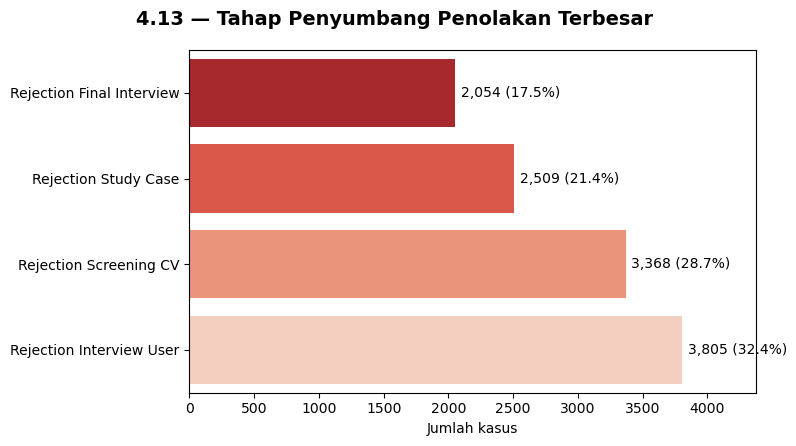

In [443]:
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.suptitle(
    "4.13 — Tahap Penyumbang Penolakan Terbesar", fontsize=14, fontweight="bold"
)

order = rejection_summary.sort_values("n", ascending=True)
sns.barplot(
    x=order["n"],
    y=order.index,
    hue=order.index,
    palette="Reds_r",
    legend=False,
    ax=ax,
)
ax.set_xlabel("Jumlah kasus")
ax.set_ylabel("")
ax.set_xlim(0, order["n"].max() * 1.15)

for container in ax.containers:
    if hasattr(container, "datavalues"):
        labels = [
            f"{v:,.0f} ({v/len(rejection_only)*100:.1f}%)" for v in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=4, fontsize=10)

plt.tight_layout()
plt.show()